#RetailCast — Análise Exploratória (EDA)

##1.Importar os packages e os datasets

###1.1.Importar as librarias necessárias

In [0]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### 1.2. Fazer o load dos datasets

In [0]:
# Load data from Unity Catalog tables
vendas = spark.table("p2_retailcast.retailcast_clean.retail_cast_dados_vendas_clean").toPandas()
info_loja = spark.table("p2_retailcast.retailcast_clean.retailcast_info_loja_clean").toPandas()
feriados = spark.table("p2_retailcast.retailcast_clean.retailcast_feriados_clean").toPandas()
eventos = spark.table("p2_retailcast.retailcast_clean.retail_cast_eventos_clean").toPandas()
unificado = spark.table("p2_retailcast.retailcast_clean_unificado.retailcast_unificado_v3").toPandas()

print("vendas:", vendas.shape)
print("info_loja:", info_loja.shape)
print("feriados:", feriados.shape)
print("eventos:", eventos.shape)

vendas: (98628, 13)
info_loja: (70, 15)
feriados: (2244, 10)
eventos: (54, 7)


# Mandatory

##  Data Understanding

In [0]:
# Inspecionar shape, tipos e amostra de registros
print("Shape:", vendas.shape)
print("Tipos de dados:")
print(vendas.dtypes)
print("Amostra de registros:")
display(vendas.head())

# Confirmar o join FK_SECAO entre vendas e info_loja
fk_secoes_vendas = set(vendas["FK_SECAO"].unique())
fk_secoes_info_loja = set(info_loja["FK_SECAO"].unique())
secoes_comuns = fk_secoes_vendas & fk_secoes_info_loja
print(f"Número de FK_SECAO em vendas: {len(fk_secoes_vendas)}")
print(f"Número de FK_SECAO em info_loja: {len(fk_secoes_info_loja)}")
print(f"Número de FK_SECAO em comum: {len(secoes_comuns)}")

# Prova de que LOJA não serve: verificar unicidade e correspondência
print("Unicidade de LOJA em vendas:", vendas["LOJA"].nunique())
print("Unicidade de FK_SECAO em vendas:", vendas["FK_SECAO"].nunique())
print("Exemplo de duplicidade LOJA para FK_SECAO:")
duplicados = vendas.groupby("LOJA")["FK_SECAO"].nunique()
display(duplicados[duplicados > 1])

Shape: (98628, 13)
Tipos de dados:
FK_SECAO           int64
LOJA              object
DATA              object
ITENS              int64
VALOR            float64
SKUS_+             int64
SKUS_-             int64
VAR_PREÇO_+      float64
VAR_PREÇO_-      float64
MES                int32
ANO                int32
SEMANA_DO_ANO      int32
DIA_SEMANA         int32
dtype: object
Amostra de registros:


FK_SECAO,LOJA,DATA,ITENS,VALOR,SKUS_+,SKUS_-,VAR_PREÇO_+,VAR_PREÇO_-,MES,ANO,SEMANA_DO_ANO,DIA_SEMANA
522,Viseu,2020-01-05,33814,109862.21439241496,891,1581,0.13838491982591622,0.1275871252511443,1,2020,1,1
522,Viseu,2020-01-09,22926,63819.58305887872,1655,1200,0.10668822517201816,0.1499412474641763,1,2020,2,5
522,Viseu,2020-01-24,26055,72578.03103062364,894,1000,0.12994644155209747,0.12363514335352539,1,2020,4,6
522,Viseu,2020-01-27,23556,60853.0986604508,1066,1121,0.18047729411634877,0.19849478032755793,1,2020,5,2
522,Viseu,2020-01-30,21653,61461.64303757609,1296,1139,0.16268606926069384,0.18100185512765804,1,2020,5,5


Número de FK_SECAO em vendas: 70
Número de FK_SECAO em info_loja: 70
Número de FK_SECAO em comum: 70
Unicidade de LOJA em vendas: 70
Unicidade de FK_SECAO em vendas: 70
Exemplo de duplicidade LOJA para FK_SECAO:


Series([], Name: FK_SECAO, dtype: int64)

count,mean,std,min,25%,50%,75%,max
98628.0,732.3284462830028,398.77919128639945,24.0,365.0,902.0,942.0,1581.0
98628.0,15181.064018331508,18478.658940226833,2.0,2647.0,4358.0,24354.25,189091.0
98628.0,44969.445192630046,61737.02414945847,3.228921660610168,4738.108115247349,8349.733596171718,73013.1753301505,864709.1785696121
98628.0,1533.0235024536644,2012.949193167173,26.0,390.0,542.0,1695.0,9761.0
98628.0,2088.2228981627936,3032.6434098025034,253.0,446.0,801.0,2247.0,24363.0
98628.0,0.13645770504919136,0.04365145925168583,0.01000724512500522,0.11261486772265489,0.14148573661187996,0.17056052017875045,0.19999933851831123
98628.0,0.1855982666331862,0.09402029269564452,0.10000303062524496,0.1289664485722941,0.1582725978529568,0.18743536016358955,0.4999944141437211
98628.0,6.362533966013708,3.3396021098680797,1.0,3.0,6.0,9.0,12.0
98628.0,2021.326651660786,1.1785513888667742,2019.0,2020.0,2021.0,2022.0,2023.0
98628.0,25.83942693758365,14.596847713754725,1.0,13.0,26.0,38.0,53.0


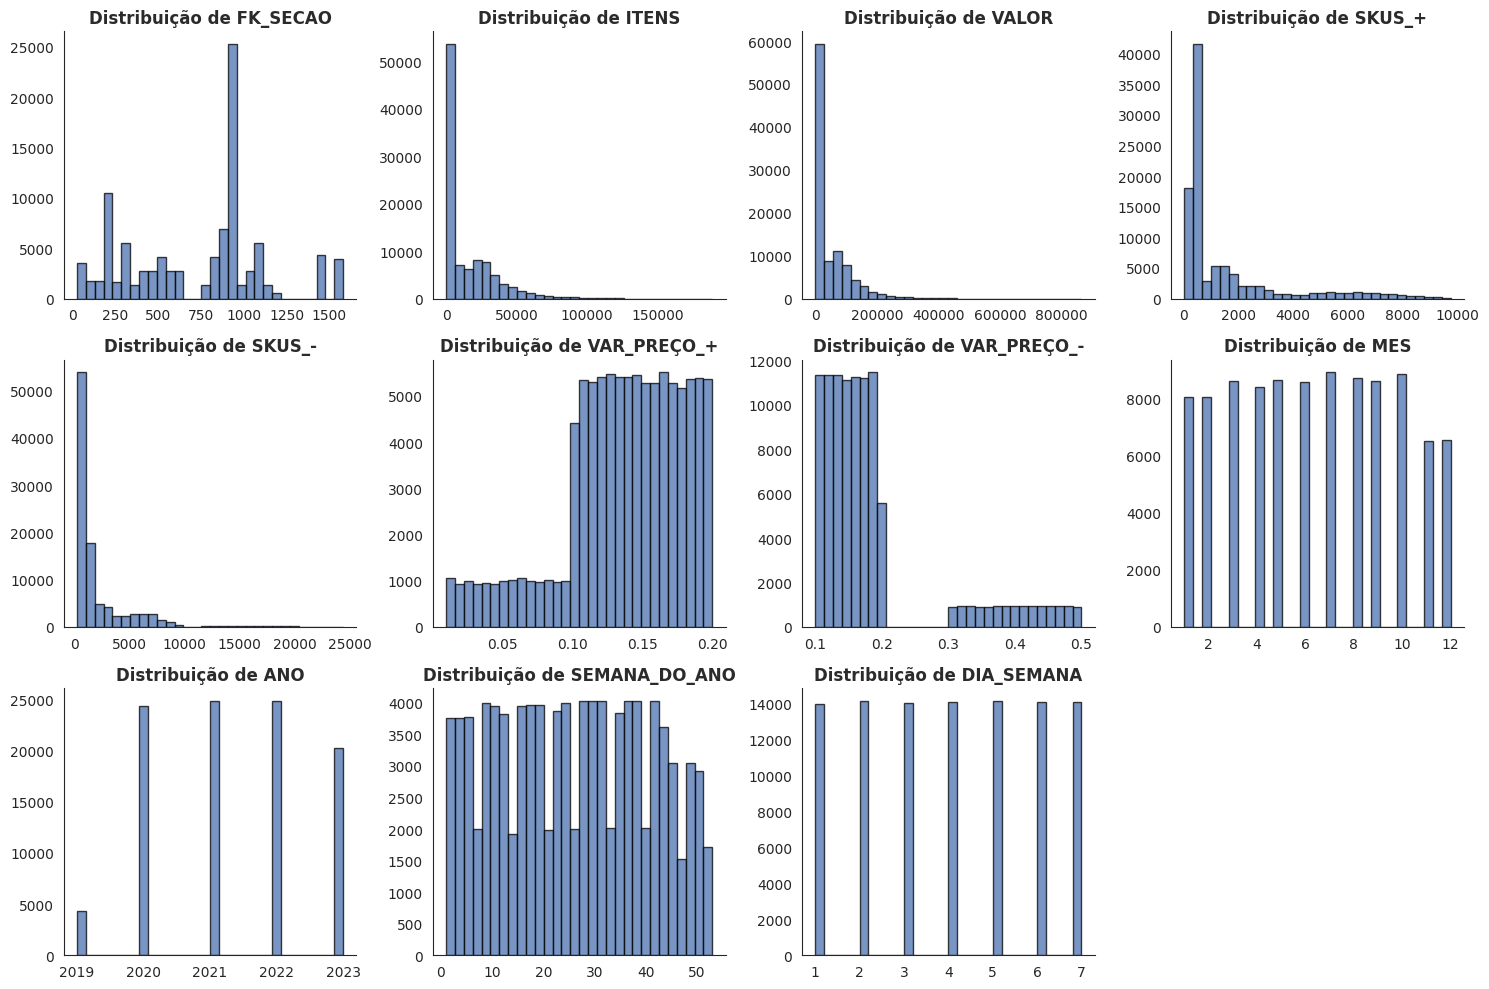

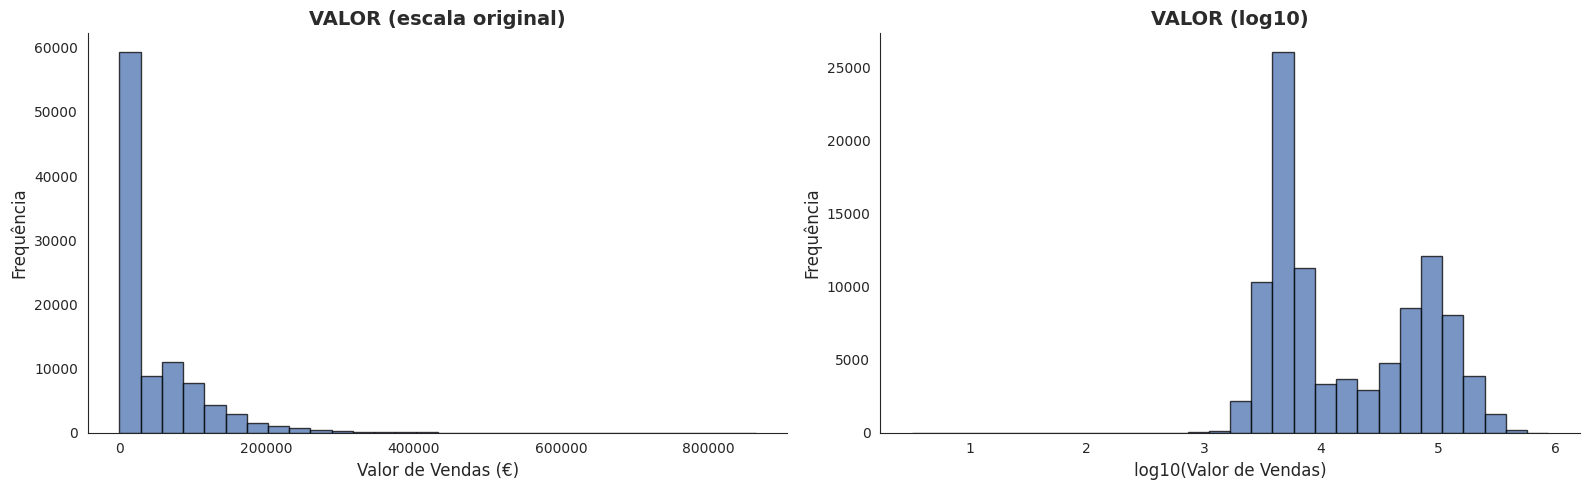

In [0]:
# Tabela de estatísticas descritivas para todas as variáveis numéricas
num_vars = vendas.select_dtypes(include=np.number).columns
display(vendas[num_vars].describe().transpose())

# Histogramas para todas as variáveis numéricas
sns.set_style("white")
num_features = len(num_vars)
num_rows = int(num_features**0.5)
num_cols_grid = int(num_features / num_rows) + (num_features % num_rows > 0)
fig, axes = plt.subplots(num_rows, num_cols_grid, figsize=(15, 10))
axes = axes.ravel()
for i, feature in enumerate(num_vars):
    ax = axes[i]
    vendas[feature].hist(bins=30, edgecolor="black", alpha=0.75, color="#4c72b0", ax=ax)
    ax.set_title(f"Distribuição de {feature}", fontsize=12, fontweight="bold", color="#2b2b2b")
    ax.grid(False)
for j in range(len(num_vars), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
sns.despine()
plt.show()

# VALOR: escala original vs log10
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
vendas["VALOR"].hist(bins=30, edgecolor="black", alpha=0.75, color="#4c72b0", ax=axes[0])
axes[0].set_title("VALOR (escala original)", fontsize=14, fontweight='bold', color="#2b2b2b")
axes[0].set_xlabel("Valor de Vendas (€)", fontsize=12)
axes[0].set_ylabel("Frequência", fontsize=12)
axes[0].grid(False)
vendas["LOG10_VALOR"] = np.log10(vendas["VALOR"])
vendas["LOG10_VALOR"].hist(bins=30, edgecolor="black", alpha=0.75, color="#4c72b0", ax=axes[1])
axes[1].set_title("VALOR (log10)", fontsize=14, fontweight='bold', color="#2b2b2b")
axes[1].set_xlabel("log10(Valor de Vendas)", fontsize=12)
axes[1].set_ylabel("Frequência", fontsize=12)
axes[1].grid(False)
plt.tight_layout()
sns.despine()
plt.show()

In [0]:
# Análise de valores ausentes: contagem e percentagem por coluna
def missing_value_stats(df, name):
    missing_count = df.isnull().sum()
    missing_pct = 100 * missing_count / len(df)
    stats = pd.DataFrame({
        "Coluna": missing_count.index,
        "Nulos": missing_count.values,
        "% Nulos": missing_pct.values
    })
    stats = stats[stats["Nulos"] > 0].sort_values("% Nulos", ascending=False)
    print(f"\nTabela: {name}")
    if len(stats) > 0:
        display(stats)
    else:
        print("Nenhum valor nulo encontrado.")

for df, name in [
    (vendas, "vendas"),
    (info_loja, "info_loja"),
    (feriados, "feriados"),
    (eventos, "eventos"),
    (unificado, "unificado")
]:
    missing_value_stats(df, name)

# Investigar as 27 linhas nulas da POR454
por454_nulos = vendas[(vendas["FK_SECAO"] == "POR454") & (vendas.isnull().any(axis=1))]
print(f"\nNúmero de linhas nulas para POR454: {por454_nulos.shape[0]}")
if len(por454_nulos) > 0:
    display(por454_nulos)
else:
    print("Nenhuma linha nula encontrada para POR454.")

# Datas em falta implícitas: verificar datas ausentes para POR454
datas_por454 = vendas[vendas["FK_SECAO"] == "POR454"]["DATA"].dropna()
if len(datas_por454) > 0:
    datas_completas = pd.date_range(datas_por454.min(), datas_por454.max())
    datas_faltantes = set(datas_completas) - set(pd.to_datetime(datas_por454))
    print(f"\nNúmero de datas em falta para POR454: {len(datas_faltantes)}")
    if len(datas_faltantes) > 0:
        print("Exemplo de datas em falta:")
        print(list(datas_faltantes)[:5])
else:
    print("\nNenhum registro encontrado para FK_SECAO 'POR454'.")

# Gráfico de barras: percentagem de nulos por coluna (vendas)
missing_pct_vendas = 100 * vendas.isnull().sum() / len(vendas)
cols_with_missing = missing_pct_vendas[missing_pct_vendas > 0]
if len(cols_with_missing) > 0:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=cols_with_missing.index, y=cols_with_missing.values, color="#4c72b0", edgecolor="black")
    plt.title("Percentagem de valores nulos por coluna (vendas)", fontsize=14, fontweight="bold")
    plt.ylabel("% Nulos", fontsize=12)
    plt.xlabel("Coluna", fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    sns.despine()
    plt.show()
else:
    print("\nNenhuma coluna com valores nulos em vendas para visualizar.")


Tabela: vendas
Nenhum valor nulo encontrado.

Tabela: info_loja
Nenhum valor nulo encontrado.

Tabela: feriados
Nenhum valor nulo encontrado.

Tabela: eventos
Nenhum valor nulo encontrado.

Tabela: unificado


Coluna,Nulos,% Nulos
FERIADO,97539,98.88281748968481



Número de linhas nulas para POR454: 0
Nenhuma linha nula encontrada para POR454.

Nenhum registro encontrado para FK_SECAO 'POR454'.

Nenhuma coluna com valores nulos em vendas para visualizar.


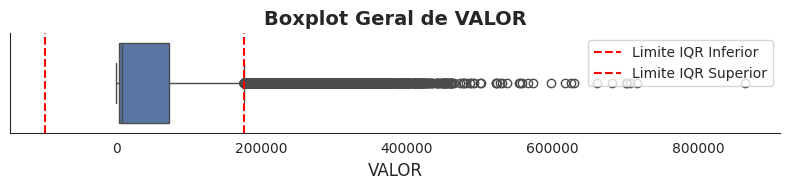

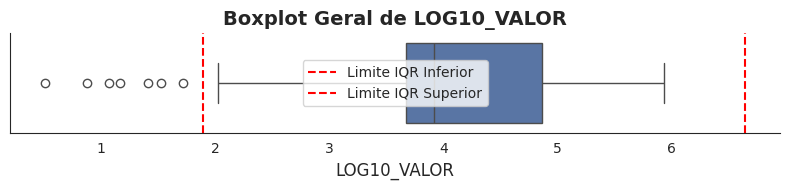

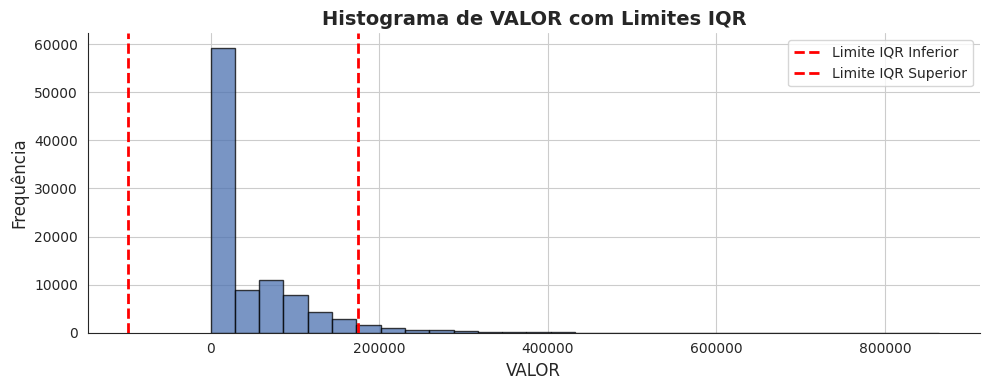

In [0]:
from scipy.stats import zscore


cont_vars = ["VALOR", "COLABORADORES", "LOG10_VALOR"]


iqr_limits = {}
for var in cont_vars:
    if var in vendas.columns:
        Q1 = vendas[var].quantile(0.25)
        Q3 = vendas[var].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        iqr_limits[var] = (limite_inferior, limite_superior)
        vendas[f"Z_{var}"] = zscore(vendas[var].fillna(0))

# 1. Boxplot geral para cada variável contínua
for var in cont_vars:
    if var in vendas.columns:
        plt.figure(figsize=(8, 2))
        sns.boxplot(x=vendas[var], color="#4c72b0")
        plt.title(f"Boxplot Geral de {var}", fontsize=14, fontweight="bold")
        plt.xlabel(var, fontsize=12)
        plt.axvline(iqr_limits[var][0], color="red", linestyle="--", label="Limite IQR Inferior")
        plt.axvline(iqr_limits[var][1], color="red", linestyle="--", label="Limite IQR Superior")
        plt.legend()
        sns.despine()
        plt.tight_layout()
        plt.show()

# 2. Boxplot de VALOR por porte de loja
if "PORTE" in info_loja.columns and "VALOR" in vendas.columns:
    vendas_porte = vendas.merge(info_loja[["FK_SECAO", "PORTE"]], on="FK_SECAO", how="left")
    plt.figure(figsize=(10, 4))
    sns.boxplot(x="PORTE", y="VALOR", data=vendas_porte, palette="Blues")
    plt.title("Boxplot de VALOR por Porte de Loja", fontsize=14, fontweight="bold")
    plt.xlabel("Porte de Loja", fontsize=12)
    plt.ylabel("Valor de Vendas (€)", fontsize=12)
    sns.despine()
    plt.tight_layout()
    plt.show()

# 3. Scatter VALOR vs COLABORADORES
if "COLABORADORES" in vendas.columns and "VALOR" in vendas.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x="COLABORADORES", y="VALOR", data=vendas, alpha=0.5, color="#4c72b0")
    plt.title("Scatter: VALOR vs COLABORADORES", fontsize=14, fontweight="bold")
    plt.xlabel("Colaboradores", fontsize=12)
    plt.ylabel("Valor de Vendas (€)", fontsize=12)
    plt.axhline(iqr_limits["VALOR"][1], color="red", linestyle="--", label="Limite IQR Superior")
    plt.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

# 4. Histograma de VALOR com limites IQR
if "VALOR" in vendas.columns:
    plt.figure(figsize=(10, 4))
    vendas["VALOR"].hist(bins=30, edgecolor="black", alpha=0.75, color="#4c72b0")
    plt.title("Histograma de VALOR com Limites IQR", fontsize=14, fontweight="bold")
    plt.xlabel("VALOR", fontsize=12)
    plt.ylabel("Frequência", fontsize=12)
    plt.axvline(iqr_limits["VALOR"][0], color="red", linestyle="--", linewidth=2, label="Limite IQR Inferior")
    plt.axvline(iqr_limits["VALOR"][1], color="red", linestyle="--", linewidth=2, label="Limite IQR Superior")
    plt.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

##  Exploratory Data Analysis (EDA)

-----------

In [0]:
vendas.head()

,FK_SECAO,LOJA,DATA,ITENS,VALOR,SKUS_+,SKUS_-,VAR_PREÇO_+,VAR_PREÇO_-,MES,ANO,SEMANA_DO_ANO,DIA_SEMANA,LOG10_VALOR,Z_VALOR,Z_LOG10_VALOR
0,522,Viseu,2020-01-05,33814,109862.214392,891,1581,0.138385,0.127587,1,2020,1,1,5.040848,1.051121,1.289349
1,522,Viseu,2020-01-09,22926,63819.583059,1655,1200,0.106688,0.149941,1,2020,2,5,4.804954,0.305331,0.916649
2,522,Viseu,2020-01-24,26055,72578.031031,894,1000,0.129946,0.123635,1,2020,4,6,4.860805,0.447199,1.004891
3,522,Viseu,2020-01-27,23556,60853.098660,1066,1121,0.180477,0.198495,1,2020,5,2,4.784283,0.257281,0.883990
4,522,Viseu,2020-01-30,21653,61461.643038,1296,1139,0.162686,0.181002,1,2020,5,5,4.788604,0.267138,0.890818


In [0]:
vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98628 entries, 0 to 98627
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   FK_SECAO       98628 non-null  int64  
 1   LOJA           98628 non-null  object 
 2   DATA           98628 non-null  object 
 3   ITENS          98628 non-null  int64  
 4   VALOR          98628 non-null  float64
 5   SKUS_+         98628 non-null  int64  
 6   SKUS_-         98628 non-null  int64  
 7   VAR_PREÇO_+    98628 non-null  float64
 8   VAR_PREÇO_-    98628 non-null  float64
 9   MES            98628 non-null  int32  
 10  ANO            98628 non-null  int32  
 11  SEMANA_DO_ANO  98628 non-null  int32  
 12  DIA_SEMANA     98628 non-null  int32  
 13  LOG10_VALOR    98628 non-null  float64
 14  Z_VALOR        98628 non-null  float64
 15  Z_LOG10_VALOR  98628 non-null  float64
dtypes: float64(6), int32(4), int64(4), object(2)
memory usage: 10.5+ MB


In [0]:
vendas.describe()

,FK_SECAO,ITENS,VALOR,SKUS_+,SKUS_-,VAR_PREÇO_+,VAR_PREÇO_-,MES,ANO,SEMANA_DO_ANO,DIA_SEMANA,LOG10_VALOR,Z_VALOR,Z_LOG10_VALOR
count,98628.000000,98628.000000,98628.000000,98628.000000,98628.000000,98628.000000,98628.000000,98628.000000,98628.000000,98628.000000,98628.000000,98628.000000,9.862800e+04,9.862800e+04
mean,732.328446,15181.064018,44969.445193,1533.023502,2088.222898,0.136458,0.185598,6.362534,2021.326652,25.839427,4.004765,4.224775,-2.478269e-17,1.094473e-15
std,398.779191,18478.658940,61737.024149,2012.949193,3032.643410,0.043651,0.094020,3.339602,1.178551,14.596848,1.998214,0.632938,1.000005e+00,1.000005e+00
min,24.000000,2.000000,3.228922,26.000000,253.000000,0.010007,0.100003,1.000000,2019.000000,1.000000,1.000000,0.509058,-7.283546e-01,-5.870619e+00
25%,365.000000,2647.000000,4738.108115,390.000000,446.000000,0.112615,0.128966,3.000000,2020.000000,13.000000,2.000000,3.675605,-6.516599e-01,-8.676568e-01
50%,902.000000,4358.000000,8349.733596,542.000000,801.000000,0.141486,0.158273,6.000000,2021.000000,26.000000,4.000000,3.921673,-5.931594e-01,-4.788842e-01
75%,942.000000,24354.250000,73013.175330,1695.000000,2247.000000,0.170561,0.187435,9.000000,2022.000000,38.000000,6.000000,4.863401,4.542472e-01,1.008993e+00
max,1581.000000,189091.000000,864709.178570,9761.000000,24363.000000,0.199999,0.499994,12.000000,2023.000000,53.000000,7.000000,5.936870,1.327799e+01,2.705011e+00


### 2.1. Distribuição 

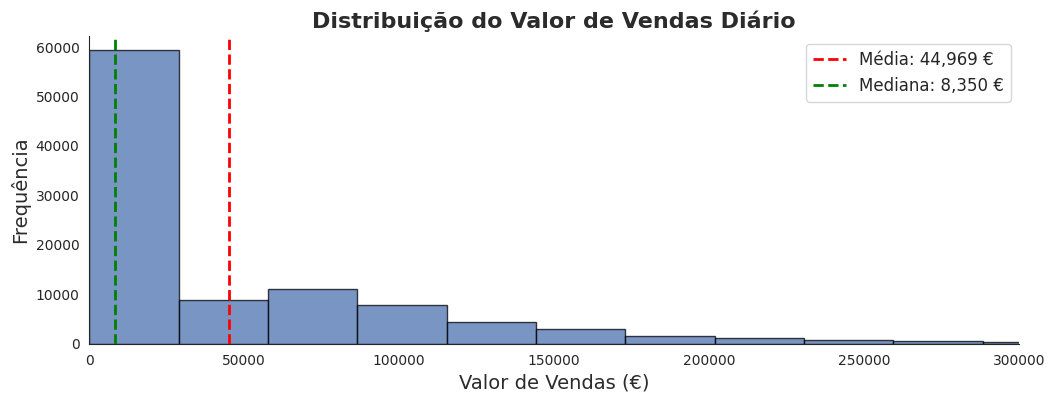

In [0]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(12, 4))
vendas["VALOR"].hist(bins=30, edgecolor="black", alpha=0.75, color="#4c72b0", ax=ax)
mean_value = vendas["VALOR"].mean()
median_value = vendas["VALOR"].median()
ax.set_title(
    "Distribuição do Valor de Vendas Diário",
    fontsize=16, fontweight='bold', color="#2b2b2b"
)
ax.set_xlabel("Valor de Vendas (€)", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.set_ylabel("Frequência", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.set_xlim(0, 0.30e6)
ax.grid(False)
ax.axvline(mean_value, color="red", linestyle="--", linewidth=2, label=f"Média: {mean_value:,.0f} €")
ax.axvline(median_value, color="green", linestyle="--", linewidth=2, label=f"Mediana: {median_value:,.0f} €")
ax.legend(fontsize=12)
sns.despine()
plt.show()

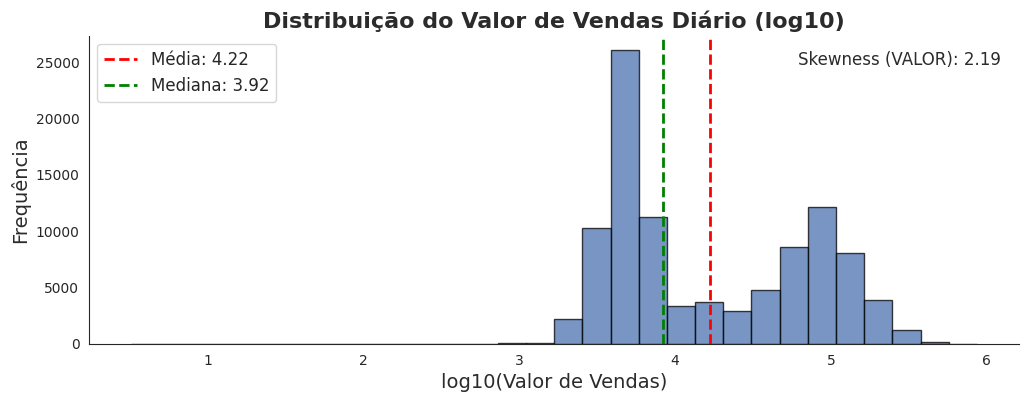

In [0]:
from scipy.stats import skew

vendas["LOG10_VALOR"] = np.log10(vendas["VALOR"])
sns.set_style("white")
fig, ax = plt.subplots(figsize=(12, 4))
vendas["LOG10_VALOR"].hist(bins=30, edgecolor="black", alpha=0.75, color="#4c72b0", ax=ax)
ax.set_title("Distribuição do Valor de Vendas Diário (log10)", fontsize=16, fontweight='bold', color="#2b2b2b")
ax.set_xlabel("log10(Valor de Vendas)", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.set_ylabel("Frequência", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.grid(False)
mean_log_value = vendas["LOG10_VALOR"].mean()
median_log_value = vendas["LOG10_VALOR"].median()
skewness = skew(vendas["VALOR"])
ax.axvline(mean_log_value, color="red", linestyle="--", linewidth=2, label=f"Média: {mean_log_value:.2f}")
ax.axvline(median_log_value, color="green", linestyle="--", linewidth=2, label=f"Mediana: {median_log_value:.2f}")
ax.legend(fontsize=12)
ax.text(0.98, 0.95, f"Skewness (VALOR): {skewness:.2f}", transform=ax.transAxes, fontsize=12, color="#2b2b2b", ha="right", va="top")
sns.despine()
plt.show()

- A Assimetria (Skewness = 2.19): Na estatística, um skewness maior que 1 indica uma curva altamente distorcida para a direita. Para o negócio, isso prova matematicamente que uma pequena fração das vendas (ou lojas) tem um faturamento desproporcionalmente gigante, carregando o peso da curva. Ele indica que o nosso faturamento global está perigosamente escorado nas poucas lojas de altíssimo desempenho (a "cauda" da direita). Se essa pequena fração de lojas sofrer qualquer instabilidade (concorrência local, problemas logísticos, fechamento temporário), o resultado total da rede despenca abruptamente, pois a grande base de lojas menores não tem volume para segurar a meta da empresa.

- Média vs. Mediana: A média e a mediana são diferentes exatamente por causa desse skewness. Os picos de altíssimo faturamento puxam a média para cima (4.22). A mediana (3.92) resiste a esse repuxo, mostrando o real ponto de equilíbrio onde metade da rede opera.

- Os Dois Picos (Distribuição Bimodal): O gráfico revela que as 70 lojas não operam de forma homogênea. O "vale" no meio indica que temos duas realidades operacionais totalmente distintas convivendo na mesma base.

In [0]:
# Definir faixas de vendas mediana diária
limites = [0, 5000, 10000, 20000, 50000, 100000, 200000, 10000000]
etiquetas = ["<5k", "5-10k", "10-20k", "20-50k", "50-100k", "100-200k", ">200k"]

# Calcular a mediana diária de vendas por loja
mediana_por_loja = vendas.groupby("FK_SECAO")["VALOR"].median().reset_index()
mediana_por_loja["FAIXA_MEDIANA"] = pd.cut(mediana_por_loja["VALOR"], bins=limites, labels=etiquetas, include_lowest=True)

# Calcular número de lojas por faixa de mediana diária
lojas_por_faixa_mediana = mediana_por_loja.groupby("FAIXA_MEDIANA")["FK_SECAO"].nunique().reset_index()
lojas_por_faixa_mediana.columns = ["Faixa de venda mediana diária", "Número de lojas"]

display(lojas_por_faixa_mediana)

/home/spark-645348d6-8471-4177-bab3-b1/.ipykernel/308/command-8991185629598172-404993799:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lojas_por_faixa_mediana = mediana_por_loja.groupby("FAIXA_MEDIANA")["FK_SECAO"].nunique().reset_index()


Faixa de venda mediana diária,Número de lojas
<5k,19
5-10k,18
10-20k,4
20-50k,4
50-100k,16
100-200k,8
>200k,1


- Risco Estratégico do "Falso Centro": Pautar o negócio pela média global de 45k direciona metas, supply chain e orçamento para um cenário que representa apenas 5% da rede, gerando um erro duplo de execução: asfixia as lojas menores com alvos irreais e deixa dinheiro na mesa ao subestimar o potencial de receita do grupo de alta performance.

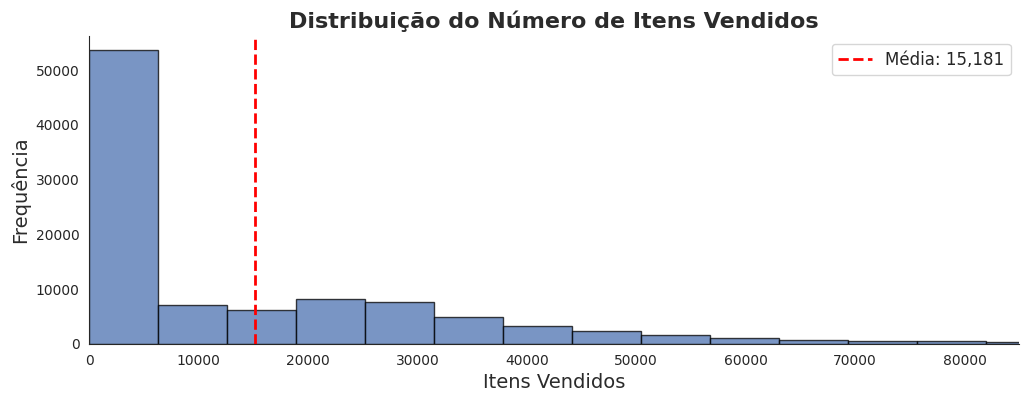

In [0]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(12, 4))
vendas["ITENS"].hist(bins=30, edgecolor="black", alpha=0.75, color="#4c72b0", ax=ax)
ax.grid(False)
ax.set_title("Distribuição do Número de Itens Vendidos", fontsize=16, fontweight='bold', color="#2b2b2b")
ax.set_xlabel("Itens Vendidos", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.set_ylabel("Frequência", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.set_xlim(0, 0.85e5)
mean_value = vendas["ITENS"].mean()
ax.axvline(mean_value, color="red", linestyle="--", linewidth=2, label=f"Média: {mean_value:,.0f}")
ax.legend(fontsize=12)
sns.despine()
plt.show()

- Diagnóstico da Operação: A rede roda em dois ritmos distintos: a grande massa de registros concentra-se em baixo volume (até 10k itens), enquanto um segundo bloco isolado sustenta um giro pesado (planalto entre 20k e 40k peças).
- Risco Logístico: Dimensionar o estoque e o transporte pela média global (15k itens) é mirar num cenário irreal; isso fatalmente vai encalhar mercadoria nas operações menores e causar ruptura de gôndola nas maiores.

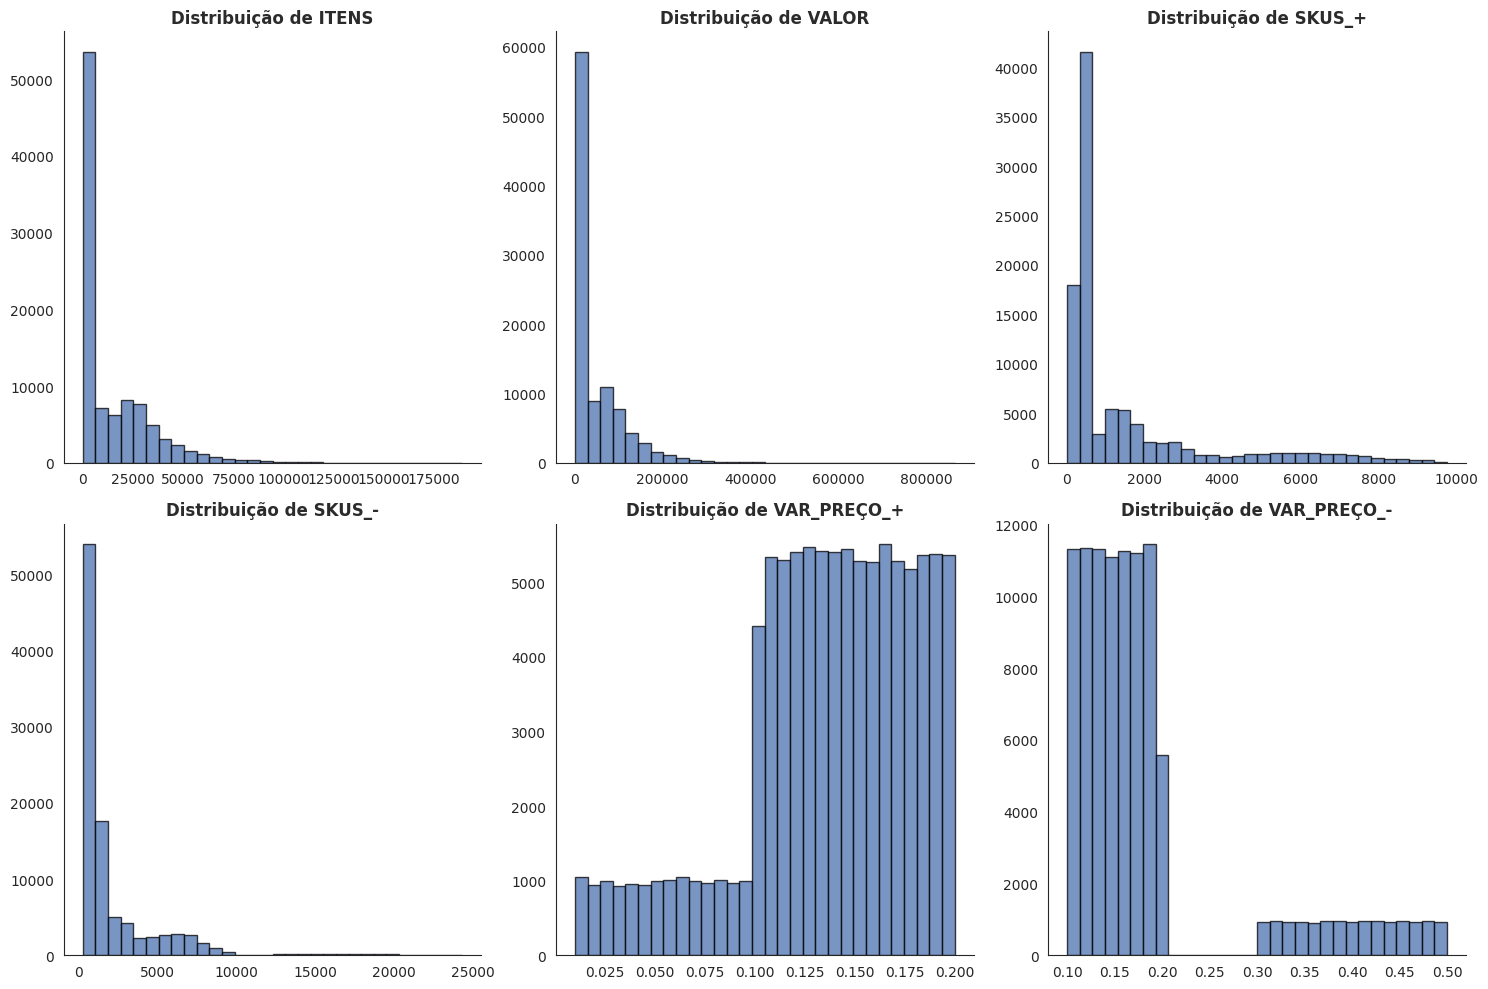

In [0]:
sns.set_style("white")
num_cols = ["ITENS", "VALOR", "SKUS_+", "SKUS_-", "VAR_PREÇO_+", "VAR_PREÇO_-"]
num_features = len(num_cols)
num_rows = int(num_features**0.5)
num_cols_grid = int(num_features / num_rows) + (num_features % num_rows > 0)
fig, axes = plt.subplots(num_rows, num_cols_grid, figsize=(15, 10))
axes = axes.ravel()
for i, feature in enumerate(num_cols):
    ax = axes[i]
    vendas[feature].hist(bins=30, edgecolor="black", alpha=0.75, color="#4c72b0", ax=ax)
    ax.set_title(f"Distribuição de {feature}", fontsize=12, fontweight="bold", color="#2b2b2b")
    ax.grid(False)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
sns.despine()
plt.show()

- ITENS: O gráfico sugere que o volume diário normal é baixo. Os grandes picos são exceções, possivelmente puxados por eventos sazonais ou lojas atípicas.
- VALOR: Segue a mesma linha. O faturamento diário costuma ser contido, e as grandes receitas parecem depender de grandes eventos ou promoções.
- SKUS_+: Sugere que a rede não faz aumentos massivos na rotina. A operação parece reajustar poucos produtos por vez.
- SKUS_-: O mesmo vale para os descontos diários. Colocar produtos em oferta na rotina parece ser uma ação bem pontual e isolada.
- VAR_PREÇO_+: Quando há repasse de preços para o catálogo, não parece ser feito aos poucos. O gráfico indica aumentos em blocos maiores, afetando de 10% a 20% da loja de uma vez.
- VAR_PREÇO_-: A política promocional parece ser polarizada. O gráfico sugere ou ofertas padrão (10% a 20% do mix) ou mega liquidações (30% a 50%), sem um meio-termo.

### 2.2. Relação entre variáveis

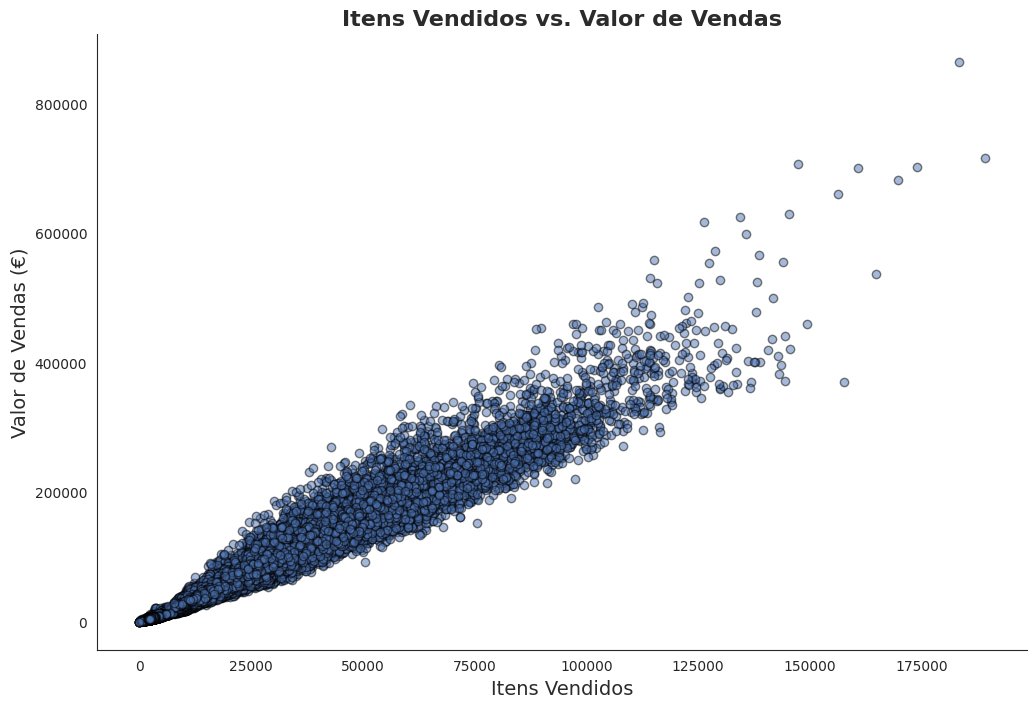

In [0]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(vendas["ITENS"], vendas["VALOR"], alpha=0.5, color="#4c72b0", edgecolor="black")
ax.set_title("Itens Vendidos vs. Valor de Vendas", fontsize=16, fontweight='bold', color="#2b2b2b")
ax.set_xlabel("Itens Vendidos", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.set_ylabel("Valor de Vendas (€)", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.grid(False)
sns.despine()
plt.show()

- Tendência principal: O gráfico sugere que o aumento na quantidade de itens vendidos tende a acompanhar o crescimento do faturamento.
- Variação de receita: Os pontos se espalham mais conforme o volume cresce. A marca de 125 mil itens, por exemplo, gera entre 300 mil e 600 mil euros. Isso sugere que o tipo de produto vendido — mais caro ou mais barato — pode mudar muito o valor final do caixa.
- Dias atípicos: Os pontos isolados na parte superior direita sugerem exceções. O desenho do gráfico indica a possível existência de eventos ou datas com picos de vendas que saem do padrão normal da operação.

### 2.3. Evolução temporal

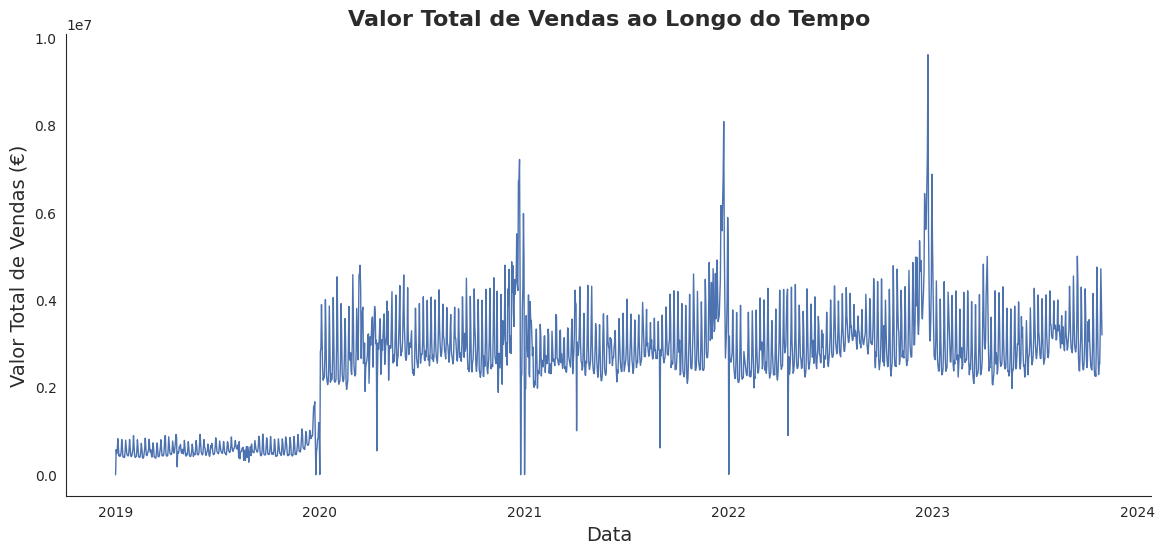

In [0]:
sns.set_style("white")
serie = vendas.groupby("DATA")["VALOR"].sum()
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(serie.index, serie.values, color="#4c72b0", linewidth=1)
ax.set_title("Valor Total de Vendas ao Longo do Tempo", fontsize=16, fontweight='bold', color="#2b2b2b")
ax.set_xlabel("Data", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.set_ylabel("Valor Total de Vendas (€)", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.grid(False)
sns.despine()
plt.show()

Análise do gráfico: 
- Picos
> Os picos (topo) são o dia 23 de dezembro de cada ano:
> pico de compras pré-Natal, presente em todas as 70 lojas em simultâneo (não é um erro de uma loja isolada).

- Vales:
> Os vales (fundo, perto de zero) são o Natal (25/dez) e a Passagem de Ano (1/jan).
> Nestes dias praticamente todas as lojas estão encerradas — só aparecem valores residuais de 1 a 5 lojas (provavelmente devoluções, ajustes de sistema, ou lojas com horário especial/turismo).

**Conclusão**: Isto é um **padrão sistémico e não um outlier de dados**. É sazonalidade de retalho perfeitamente esperada

In [0]:
# 1) soma por loja + dia
loja_dia = unificado.groupby(["FK_SECAO", "DATA"])["TARGET_VENDAS_DIARIAS_EUR"].sum().reset_index()

# 3) para cada loja, pegar a linha do dia de MAIOR venda
idx_picos = loja_dia.groupby("FK_SECAO")["TARGET_VENDAS_DIARIAS_EUR"].idxmax()
picos = loja_dia.loc[idx_picos]

# 4) trazer o nome da loja (join por FK_SECAO)
picos = picos.merge(
    info_loja[["FK_SECAO", "LOJA", "REGIAO"]].drop_duplicates("FK_SECAO"),
    on="FK_SECAO", how="left"
)

# 5) adicionar informação de feriado (join por LOJA e DATA)
picos = picos.merge(
    feriados[["LOJA", "DATA", "DESCRICAO"]].rename(columns={"DESCRICAO": "FERIADO"}),
    on=["LOJA", "DATA"], how="left"
)
picos["FERIADO"] = picos["FERIADO"].fillna("—")

# 6) ordenar do maior pico para o menor
picos = picos.sort_values("TARGET_VENDAS_DIARIAS_EUR", ascending=False)


print("=== PICO DE VENDA DE CADA LOJA ===")
for _, r in picos.iterrows():
    data = pd.to_datetime(r["DATA"]).strftime("%d/%m/%Y (%a)")
    print(f"{str(r['LOJA']):<28} {str(r['REGIAO']):<16} {data:20} {str(r['FERIADO']):<30} →  €{r['TARGET_VENDAS_DIARIAS_EUR']:,.0f}")

=== PICO DE VENDA DE CADA LOJA ===
Almada Fórum                 Margem Sul       23/12/2022 (Fri)     —                              →  €864,709
Alfragide                    Lisboa Central   23/12/2022 (Fri)     —                              →  €625,181
Setúbal                      Margem Sul       23/12/2022 (Fri)     —                              →  €531,084
Gondomar                     Porto            01/12/2022 (Thu)     Restauração da Independência   →  €468,043
Gondomar                     Porto            01/12/2022 (Thu)     Restauração da Independência   →  €468,043
Sintra                       Lisboa Litoral   23/12/2022 (Fri)     —                              →  €460,449
Faro                         Algarve          23/12/2022 (Fri)     —                              →  €459,775
Alverca                      Lisboa Norte     23/12/2022 (Fri)     —                              →  €453,495
Aveiro                       Beira Litoral    23/12/2022 (Fri)     —                 

In [0]:
# Maior venda individual (uma loja num dia)
serie_loja_dia = vendas.groupby(["FK_SECAO", "DATA"])["VALOR"].sum().reset_index()

# Localizar o pico
idx_max = serie_loja_dia["VALOR"].idxmax()
pico = serie_loja_dia.loc[idx_max]

print("Loja :", pico["FK_SECAO"])
print("Dia  :", pico["DATA"])
print("Valor: €", round(pico["VALOR"], 2))

Loja : 24
Dia  : 2022-12-23
Valor: € 864709.18


### 2.4. Outliers

In [0]:
features = ["ITENS", "VALOR", "SKUS_+", "SKUS_-"]
vendas[features].describe()

,ITENS,VALOR,SKUS_+,SKUS_-
count,98628.000000,98628.000000,98628.000000,98628.000000
mean,15181.064018,44969.445193,1533.023502,2088.222898
std,18478.658940,61737.024149,2012.949193,3032.643410
min,2.000000,3.228922,26.000000,253.000000
25%,2647.000000,4738.108115,390.000000,446.000000
50%,4358.000000,8349.733596,542.000000,801.000000
75%,24354.250000,73013.175330,1695.000000,2247.000000
max,189091.000000,864709.178570,9761.000000,24363.000000


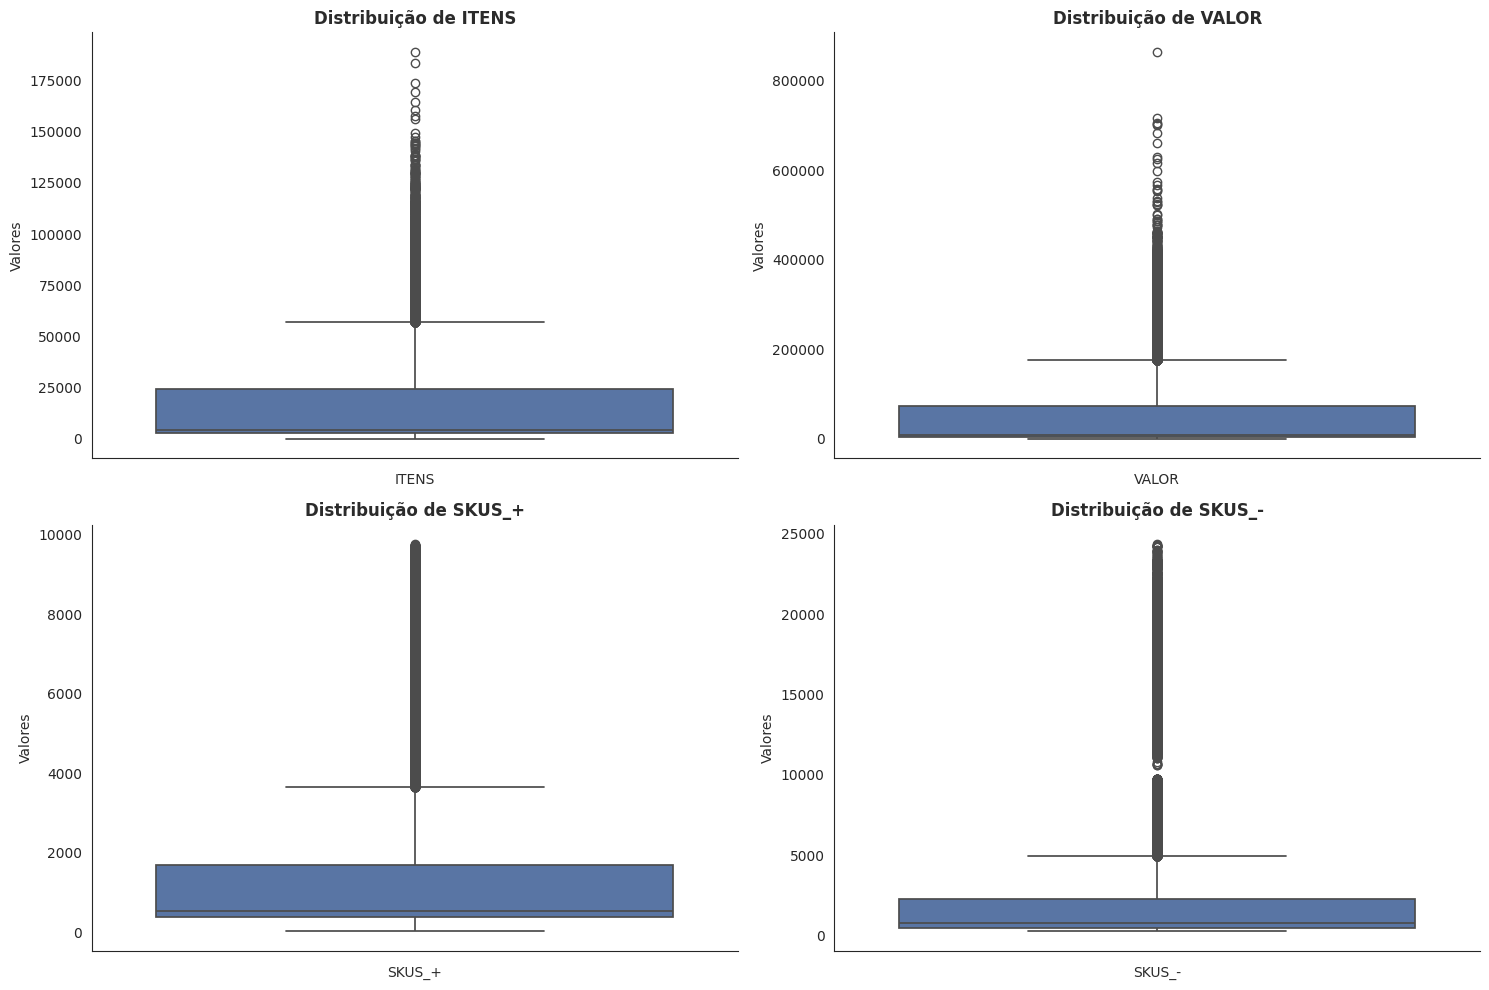

In [0]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()
for i, feature in enumerate(features):
    ax = axes[i]
    sns.boxplot(data=vendas[feature], ax=ax, color="#4c72b0", linewidth=1.25)
    ax.set_title(f"Distribuição de {feature}", fontsize=12, fontweight="bold", color="#2b2b2b")
    ax.set_xlabel(f"{feature}", fontsize=10, fontweight="medium", color="#2b2b2b")
    ax.set_ylabel("Valores", fontsize=10, fontweight="medium", color="#2b2b2b")
    ax.grid(False)
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

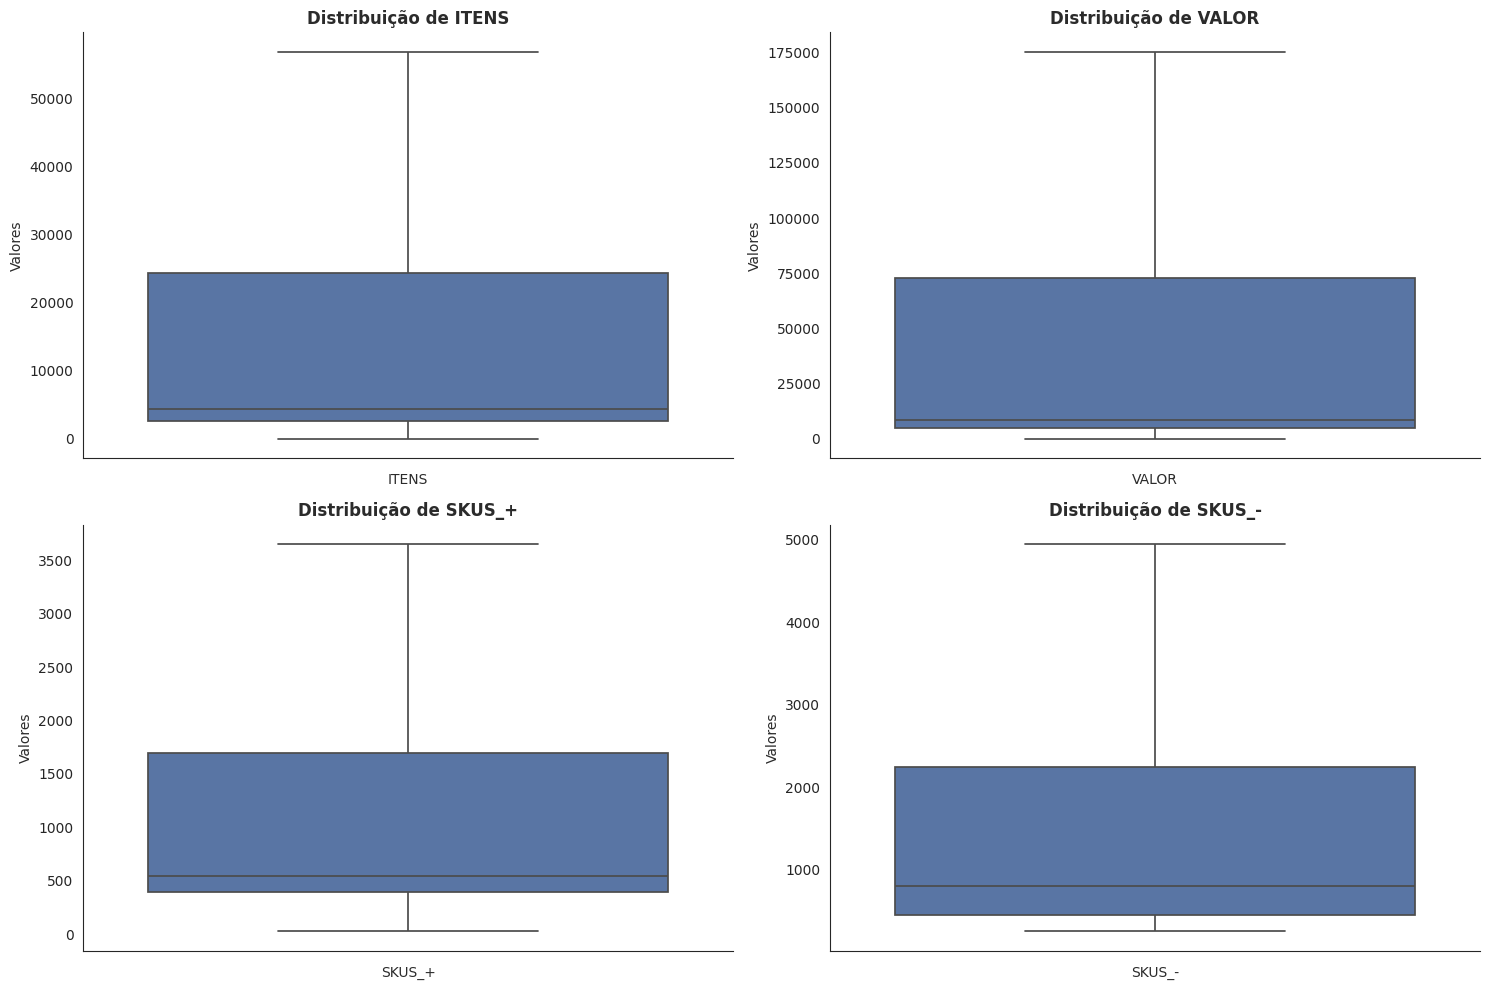

In [0]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()
for i, feature in enumerate(features):
    ax = axes[i]
    sns.boxplot(data=vendas[feature], ax=ax, showfliers=False, color="#4c72b0", linewidth=1.25)
    ax.set_title(f"Distribuição de {feature}", fontsize=12, fontweight="bold", color="#2b2b2b")
    ax.set_xlabel(f"{feature}", fontsize=10, fontweight="medium", color="#2b2b2b")
    ax.set_ylabel("Valores", fontsize=10, fontweight="medium", color="#2b2b2b")
    ax.grid(False)
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### 2.5. Correlações

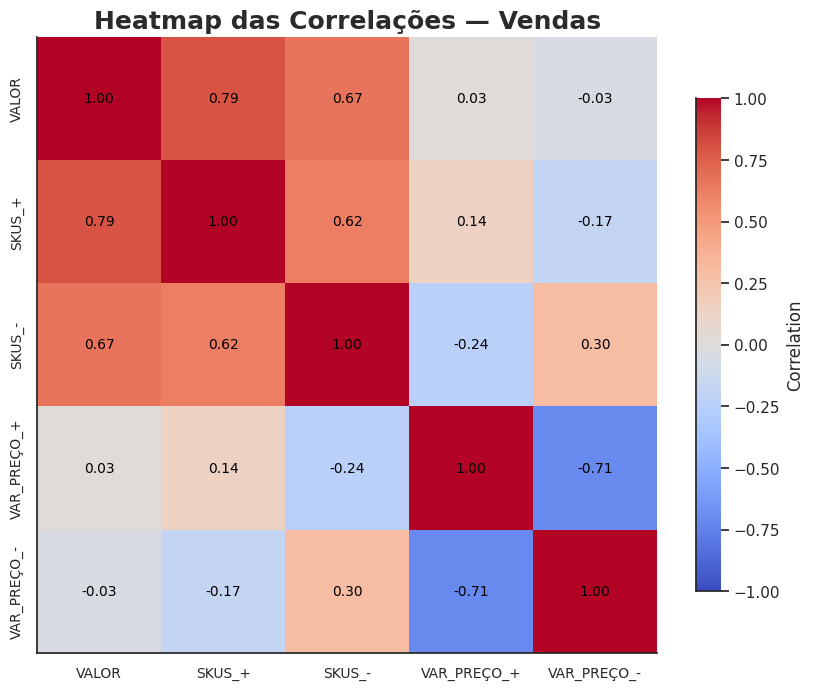

In [0]:
num_df = vendas[["VALOR", "SKUS_+", "SKUS_-", "VAR_PREÇO_+", "VAR_PREÇO_-"]]
sns.set(style="white")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm", fmt=".2f",
            annot_kws={"size": 10, "color": "black"},
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            vmin=-1, vmax=1)
plt.xticks(fontsize=10); plt.yticks(fontsize=10)
plt.title("Heatmap das Correlações — Vendas", fontsize=18, fontweight="bold", color="#2b2b2b")
sns.despine()
plt.show()

#3. EDA — Informação das Lojas

Uma linha por loja (70 lojas), com características operacionais: nº de colaboradores, SKUs, caixas, região, etc.

In [0]:
info_loja.head()

,FK_LOJA,LOJA,FK_CIDADE,CIDADE,FK_REGIAO,REGIAO,FK_SECAO,SECAO,PRODUTIVIDADE/HORA,N_COLABORADORES,SKUS,ABERTURA,FECHO,CAIXAS_TRADICIONAIS,SELF_CHECKOUTS
0,POR025,Alfragide,228,Alfragide,14,Lisboa Central,976,Frente de Loja,269,85,35052,08:00,21:00,26,8
1,POR012,Almada Fórum,164,Almada,3,Margem Sul,24,Frente de Loja,400,100,46951,08:30,23:00,26,6
2,POR029,Alverca,227,Alverca,17,Lisboa Norte,1072,Frente de Loja,335,48,17367,08:00,21:00,50,26
3,POR032,Aveiro,111,Aveiro,13,Beira Litoral,321,Frente de Loja,227,60,36896,08:00,23:30,14,5
4,POR052,Caldas da Rainha,171,Caldas da Rainha,17,Lisboa Norte,1125,Frente de Loja,136,7,2760,07:00,20:00,4,4


In [0]:
info_loja.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   FK_LOJA              70 non-null     object
 1   LOJA                 70 non-null     object
 2   FK_CIDADE            70 non-null     int64 
 3   CIDADE               70 non-null     object
 4   FK_REGIAO            70 non-null     int64 
 5   REGIAO               70 non-null     object
 6   FK_SECAO             70 non-null     int64 
 7   SECAO                70 non-null     object
 8   PRODUTIVIDADE/HORA   70 non-null     int64 
 9   N_COLABORADORES      70 non-null     int64 
 10  SKUS                 70 non-null     int64 
 11  ABERTURA             70 non-null     object
 12  FECHO                70 non-null     object
 13  CAIXAS_TRADICIONAIS  70 non-null     int64 
 14  SELF_CHECKOUTS       70 non-null     int64 
dtypes: int64(8), object(7)
memory usage: 8.3+ KB


### 3.1. Verificação de qualidade

In [0]:
# valores em falta e duplicados
print("Nulos por coluna:")
print(info_loja.isnull().sum())
print("\nDuplicados:", info_loja.duplicated().sum())


print("\nValores de SECAO antes de padronizar:")
print(info_loja["SECAO"].value_counts())

Nulos por coluna:
FK_LOJA                0
LOJA                   0
FK_CIDADE              0
CIDADE                 0
FK_REGIAO              0
REGIAO                 0
FK_SECAO               0
SECAO                  0
PRODUTIVIDADE/HORA     0
N_COLABORADORES        0
SKUS                   0
ABERTURA               0
FECHO                  0
CAIXAS_TRADICIONAIS    0
SELF_CHECKOUTS         0
dtype: int64

Duplicados: 0

Valores de SECAO antes de padronizar:
SECAO
Frente de Loja    70
Name: count, dtype: int64


In [0]:
info_loja.describe()

,FK_CIDADE,FK_REGIAO,FK_SECAO,PRODUTIVIDADE/HORA,N_COLABORADORES,SKUS,CAIXAS_TRADICIONAIS,SELF_CHECKOUTS
count,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,188.171429,11.442857,761.771429,195.414286,25.414286,11030.942857,14.928571,3.128571
std,58.551345,5.207675,390.992019,96.103732,19.908117,13517.317611,6.804349,5.250042
min,1.000000,1.000000,24.000000,0.000000,7.000000,2523.000000,3.000000,0.000000
25%,164.000000,11.000000,434.750000,132.250000,13.000000,2977.250000,12.250000,0.000000
50%,218.500000,14.000000,905.500000,177.000000,15.000000,3338.000000,15.000000,0.000000
75%,235.000000,14.000000,943.750000,230.500000,30.750000,13769.250000,17.000000,4.000000
max,244.000000,18.000000,1581.000000,461.000000,100.000000,48810.000000,50.000000,26.000000


### 3.2. Distribuições das variáveis numéricas

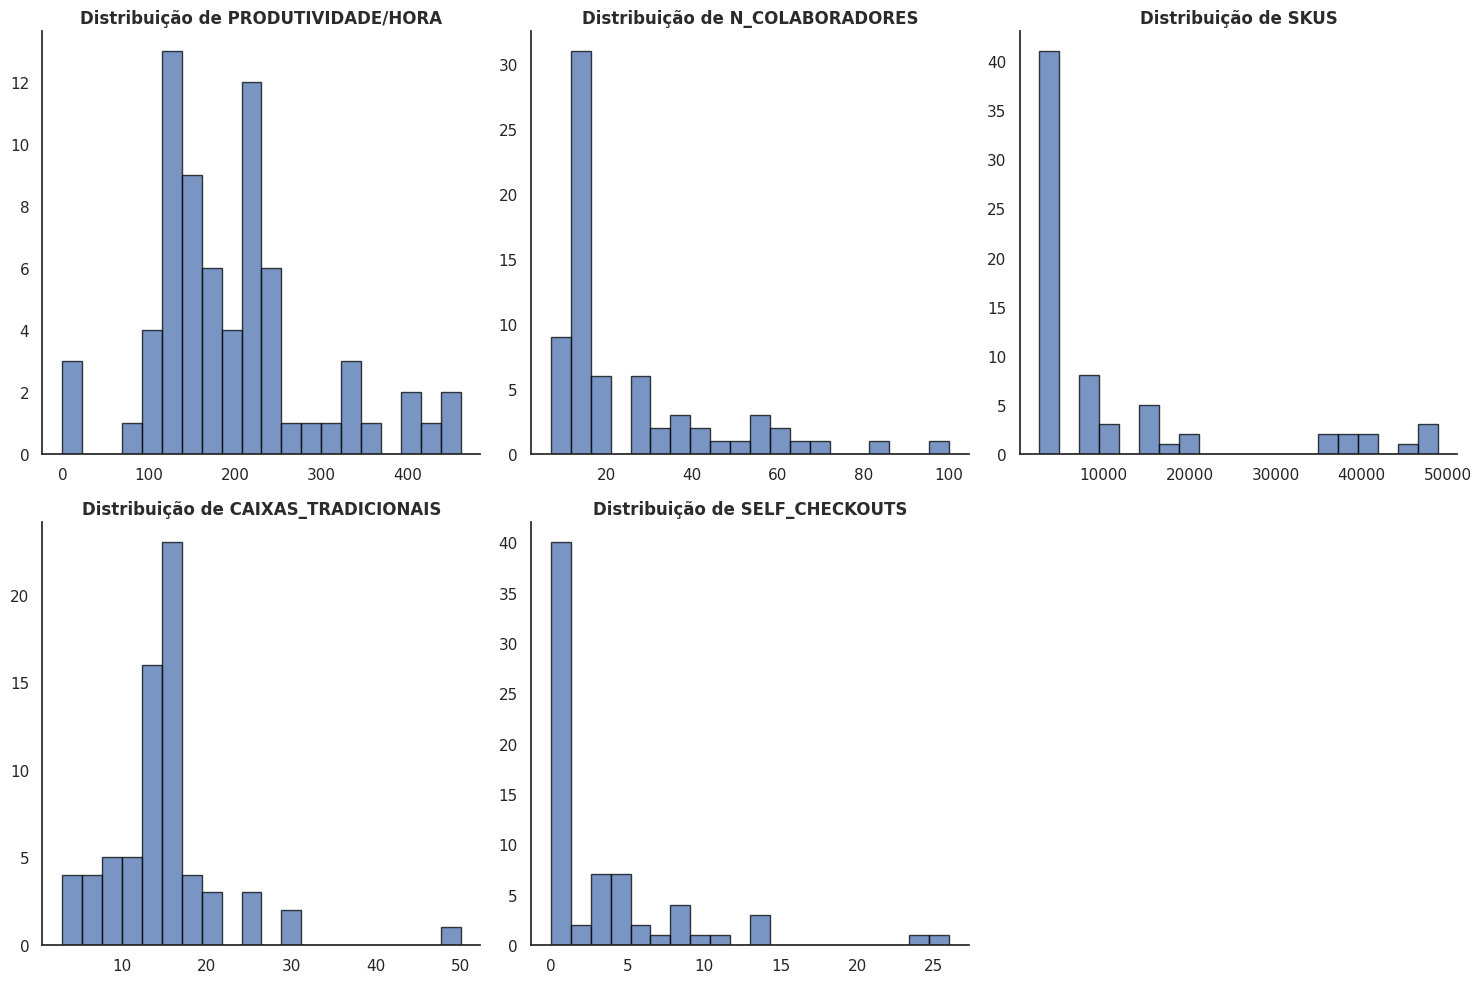

In [0]:
sns.set_style("white")
num_cols = ["PRODUTIVIDADE/HORA", "N_COLABORADORES", "SKUS", "CAIXAS_TRADICIONAIS", "SELF_CHECKOUTS"]
num_features = len(num_cols)
num_rows = int(num_features**0.5)
num_cols_grid = int(num_features / num_rows) + (num_features % num_rows > 0)
fig, axes = plt.subplots(num_rows, num_cols_grid, figsize=(15, 10))
axes = axes.ravel()
for i, feature in enumerate(num_cols):
    ax = axes[i]
    info_loja[feature].hist(bins=20, edgecolor="black", alpha=0.75, color="#4c72b0", ax=ax)
    ax.set_title(f"Distribuição de {feature}", fontsize=12, fontweight="bold", color="#2b2b2b")
    ax.grid(False)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
sns.despine()
plt.show()

### 3.3. Distribuição das lojas por região

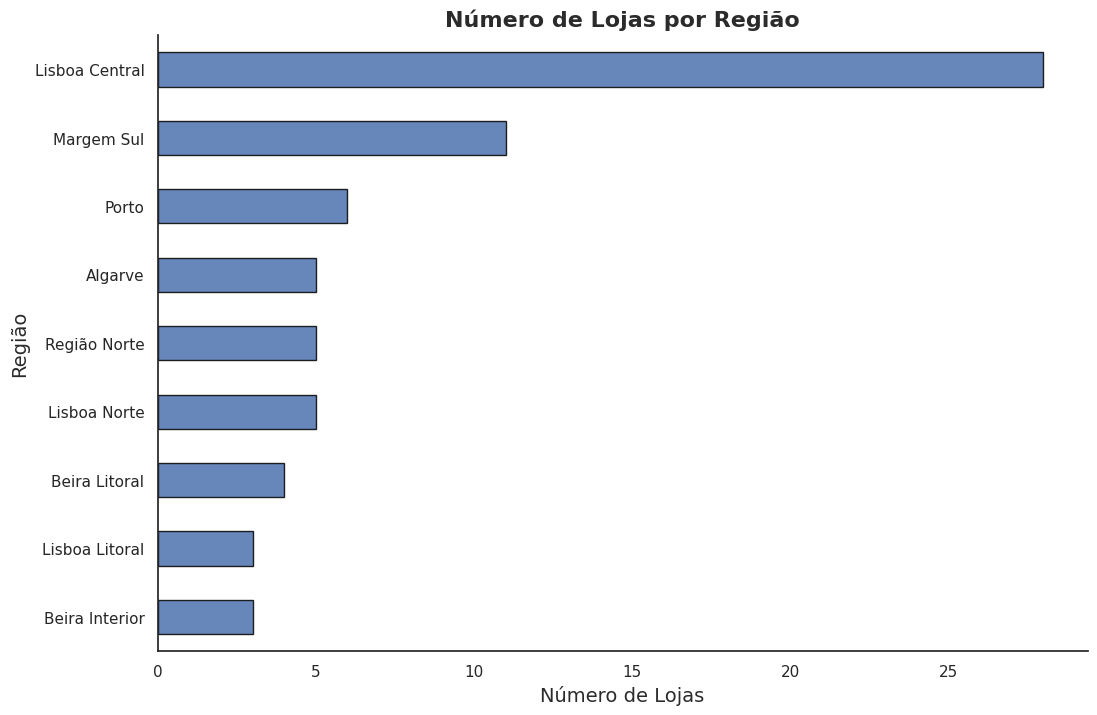

In [0]:
sns.set_style("white")
regiao_counts = info_loja["REGIAO"].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(12, 8))
regiao_counts.plot(kind="barh", color="#4c72b0", edgecolor="black", alpha=0.85, ax=ax)
ax.set_title("Número de Lojas por Região", fontsize=16, fontweight='bold', color="#2b2b2b")
ax.set_xlabel("Número de Lojas", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.set_ylabel("Região", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.grid(False)
sns.despine()
plt.show()

### 3.4. Correlações entre características das lojas

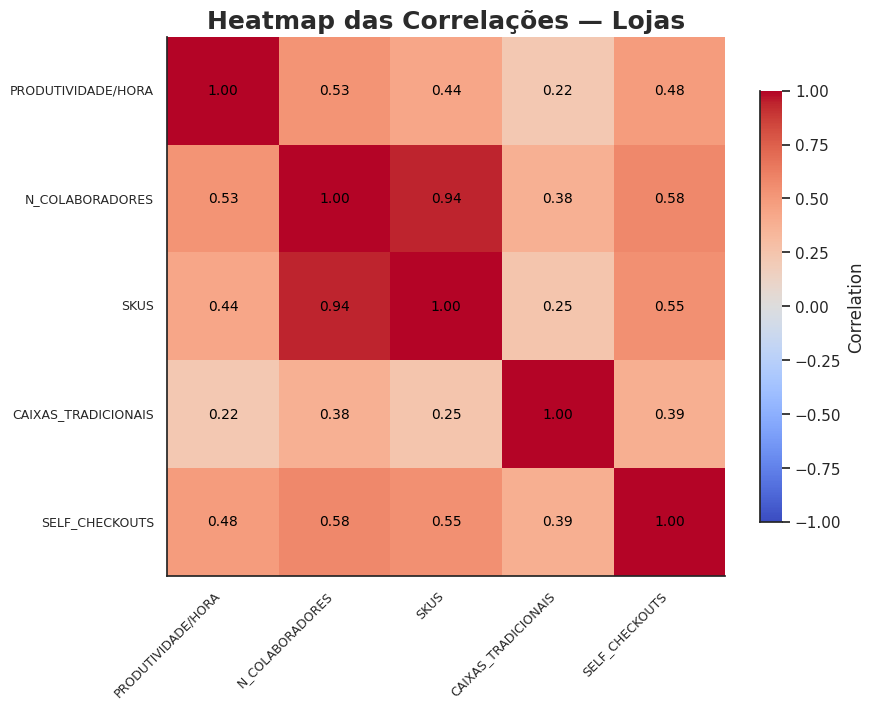

In [0]:
num_df = info_loja[["PRODUTIVIDADE/HORA", "N_COLABORADORES", "SKUS", "CAIXAS_TRADICIONAIS", "SELF_CHECKOUTS"]]
sns.set(style="white")
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm", fmt=".2f",
            annot_kws={"size": 10, "color": "black"},
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            vmin=-1, vmax=1)
plt.xticks(fontsize=9, rotation=45, ha="right"); plt.yticks(fontsize=9)
plt.title("Heatmap das Correlações — Lojas", fontsize=18, fontweight="bold", color="#2b2b2b")
sns.despine()
plt.show()

#4. EDA — Feriados

Feriados por loja e por dia. Tabela sobretudo categórica e de datas — importante mais tarde para explicar picos e quedas nas vendas.

In [0]:
feriados.head()

,FK_LOJA,LOJA,DATA,DESCRICAO,FERIADO_FIXO,LOJA_ABERTA,MES,ANO,SEMANA_DO_ANO,ESTACAO_DO_ANO
0,POR012,Almada Fórum,2021-06-03,Corpo de Deus,N,1,6,2021,22,Verão
1,POR417,S - Nuno Alvares Pereira,2021-06-03,Corpo de Deus,N,1,6,2021,22,Verão
2,POR019,Coina,2021-06-03,Corpo de Deus,N,1,6,2021,22,Verão
3,POR012,Almada Fórum,2021-06-10,Dia de Portugal,N,1,6,2021,23,Verão
4,POR417,S - Nuno Alvares Pereira,2021-06-10,Dia de Portugal,N,1,6,2021,23,Verão


In [0]:
feriados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2244 entries, 0 to 2243
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   FK_LOJA         2244 non-null   object
 1   LOJA            2244 non-null   object
 2   DATA            2244 non-null   object
 3   DESCRICAO       2244 non-null   object
 4   FERIADO_FIXO    2244 non-null   object
 5   LOJA_ABERTA     2244 non-null   int32 
 6   MES             2244 non-null   int32 
 7   ANO             2244 non-null   int32 
 8   SEMANA_DO_ANO   2244 non-null   int32 
 9   ESTACAO_DO_ANO  2244 non-null   object
dtypes: int32(4), object(6)
memory usage: 140.4+ KB


### 4.1. Verificação de qualidade

In [0]:
print("Nulos por coluna:")
print(feriados.isnull().sum())
print("\nDuplicados:", feriados.duplicated().sum())

Nulos por coluna:
FK_LOJA           0
LOJA              0
DATA              0
DESCRICAO         0
FERIADO_FIXO      0
LOJA_ABERTA       0
MES               0
ANO               0
SEMANA_DO_ANO     0
ESTACAO_DO_ANO    0
dtype: int64

Duplicados: 13


### 4.2. Variáveis categóricas

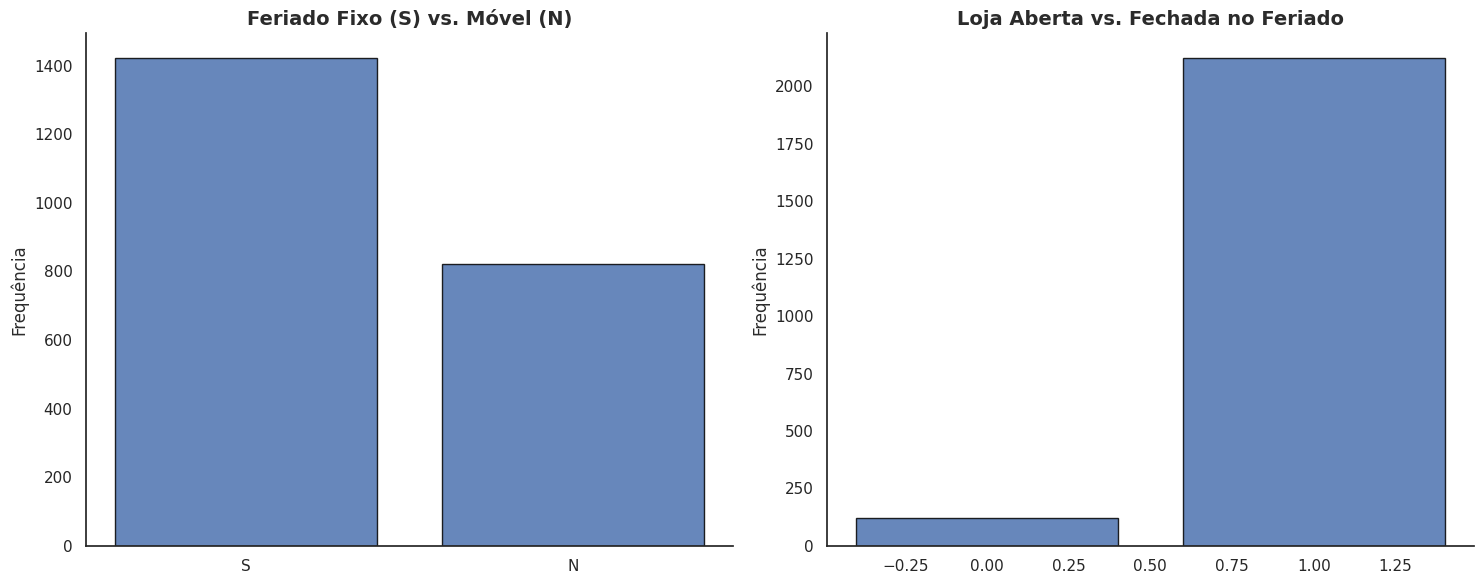

In [0]:
sns.set_style("white")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# feriado fixo vs móvel
fer_fixo = feriados["FERIADO_FIXO"].value_counts()
axes[0].bar(fer_fixo.index, fer_fixo.values, color="#4c72b0", edgecolor="black", alpha=0.85)
axes[0].set_title("Feriado Fixo (S) vs. Móvel (N)", fontsize=14, fontweight="bold", color="#2b2b2b")
axes[0].set_ylabel("Frequência", fontsize=12, color="#2b2b2b")
axes[0].grid(False)

# loja aberta vs fechada no feriado
loja_aberta = feriados["LOJA_ABERTA"].value_counts()
axes[1].bar(loja_aberta.index, loja_aberta.values, color="#4c72b0", edgecolor="black", alpha=0.85)
axes[1].set_title("Loja Aberta vs. Fechada no Feriado", fontsize=14, fontweight="bold", color="#2b2b2b")
axes[1].set_ylabel("Frequência", fontsize=12, color="#2b2b2b")
axes[1].grid(False)

sns.despine()
plt.tight_layout()
plt.show()

- **Feriado Fixo vs. Móvel:** O gráfico mostra que há predominância de feriados fixos (datas recorrentes, como Natal) em relação aos móveis (datas que variam, como Carnaval).  
- **Loja Aberta vs. Fechada:** A maioria das lojas permanece aberta durante os feriados, indicando potencial de vendas nesses dias.

**Para o negócio:**  
- Saber se o feriado é fixo ou móvel ajuda no planejamento operacional e de estoque, pois feriados fixos permitem previsibilidade anual.
- A abertura das lojas em feriados impacta diretamente o faturamento e a necessidade de recursos (colaboradores, estoque).

**Definições:**  
- *Feriado Fixo:* Data que ocorre sempre no mesmo dia e mês (ex: 25/12 - Natal).
- *Feriado Móvel:* Data que varia a cada ano (ex: Carnaval, Páscoa).

### 4.3. Feriados mais frequentes

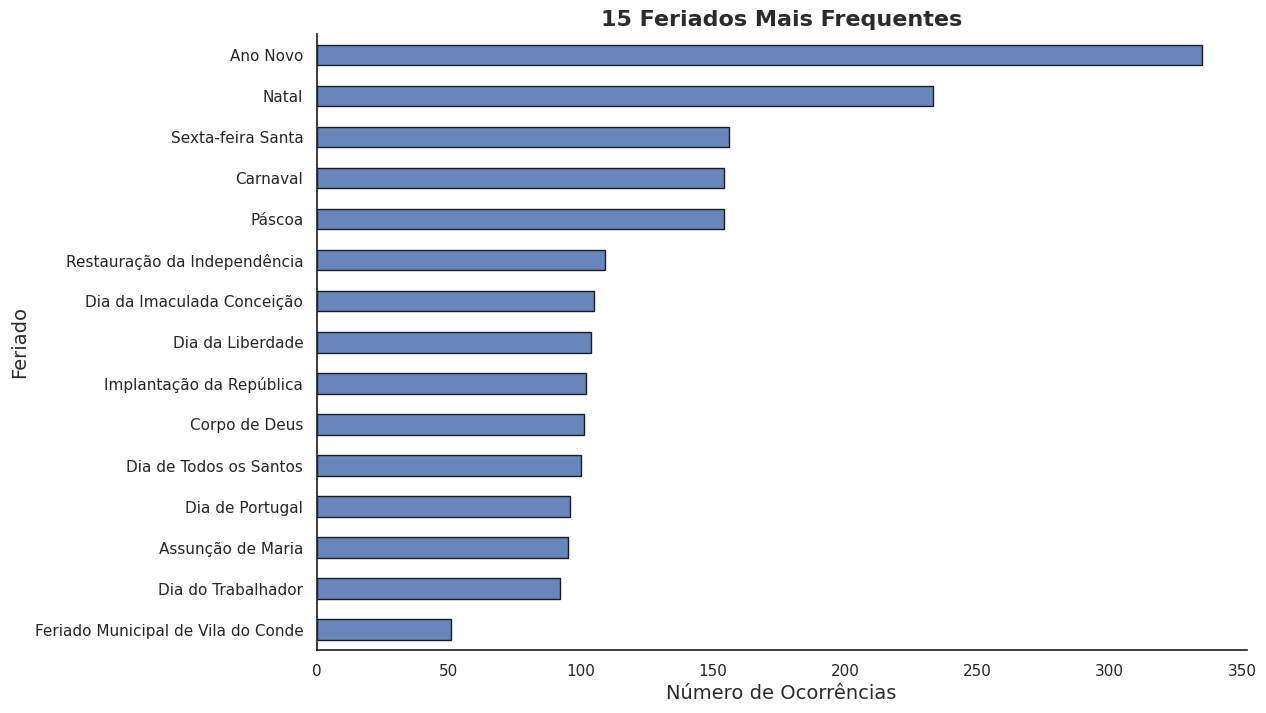

In [0]:
sns.set_style("white")
top_feriados = feriados["DESCRICAO"].value_counts().head(15).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(12, 8))
top_feriados.plot(kind="barh", color="#4c72b0", edgecolor="black", alpha=0.85, ax=ax)
ax.set_title("15 Feriados Mais Frequentes", fontsize=16, fontweight='bold', color="#2b2b2b")
ax.set_xlabel("Número de Ocorrências", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.set_ylabel("Feriado", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.grid(False)
sns.despine()
plt.show()

### 4.4. Feriados ao longo do tempo

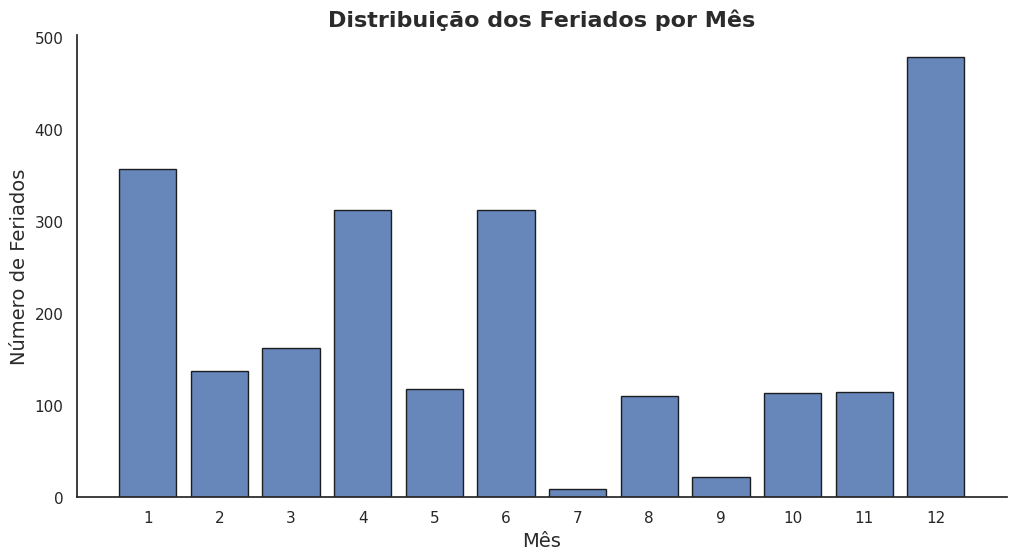

In [0]:
sns.set_style("white")
feriados_mes = feriados.groupby("MES").size()
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(feriados_mes.index, feriados_mes.values, color="#4c72b0", edgecolor="black", alpha=0.85)
ax.set_title("Distribuição dos Feriados por Mês", fontsize=16, fontweight='bold', color="#2b2b2b")
ax.set_xlabel("Mês", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.set_ylabel("Número de Feriados", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.set_xticks(range(1, 13))
ax.grid(False)
sns.despine()
plt.show()

- O gráfico mostra a distribuição dos feriados ao longo dos meses do ano.
- Alguns meses concentram mais feriados, indicando possíveis períodos de menor ou maior movimento nas lojas.
- Meses como janeiro, fevereiro e dezembro tendem a ter mais feriados, impactando o planejamento operacional e de vendas.
- A sazonalidade dos feriados pode explicar variações nos resultados de vendas e demanda por estoque.
- Entender essa distribuição ajuda a antecipar picos e quedas de faturamento, além de ajustar recursos (colaboradores, promoções).

#5.EDA — Eventos

Eventos promocionais/pontuais por loja, com intervalo de datas (`DATA_INI` a `DATA_FIM`). Tabela pequena, útil para explicar variações locais nas vendas.

In [0]:
eventos.head()

,FK_LOJA,LOJA,DATA_INI,DATA_FIM,DESCRICAO,MES_EVENTO,ESTACAO_DO_ANO
0,POR062,Eiras,2022-11-21,2022-11-21,Inventário Cápsulas Café,11,Outono
1,POR029,Alverca,2023-05-07,2023-05-07,IP Interiores + Brico,5,Primavera
2,POR009,Coimbra,2022-11-21,2022-11-21,IP Garrafeira,11,Outono
3,POR008,Gaia,2022-12-24,2022-12-24,Véspera de Natal,12,Inverno
4,POR029,Alverca,2023-05-08,2023-05-08,IP Brico,5,Primavera


In [0]:
eventos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   FK_LOJA         54 non-null     object
 1   LOJA            54 non-null     object
 2   DATA_INI        54 non-null     object
 3   DATA_FIM        54 non-null     object
 4   DESCRICAO       54 non-null     object
 5   MES_EVENTO      54 non-null     int32 
 6   ESTACAO_DO_ANO  54 non-null     object
dtypes: int32(1), object(6)
memory usage: 2.9+ KB


### 5.1. Verificação de qualidade

In [0]:
print("Nulos por coluna:")
print(eventos.isnull().sum())
print("\nDuplicados:", eventos.duplicated().sum())

# duração de cada evento em dias
eventos["DURACAO_DIAS"] = (pd.to_datetime(eventos["DATA_FIM"]) - pd.to_datetime(eventos["DATA_INI"])).dt.days + 1
print("\nDuração dos eventos (dias):")
print(eventos["DURACAO_DIAS"].describe())

Nulos por coluna:
FK_LOJA           0
LOJA              0
DATA_INI          0
DATA_FIM          0
DESCRICAO         0
MES_EVENTO        0
ESTACAO_DO_ANO    0
dtype: int64

Duplicados: 0

Duração dos eventos (dias):
count    54.000000
mean      1.444444
std       2.320269
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max      17.000000
Name: DURACAO_DIAS, dtype: float64


### 5.2. Eventos por loja

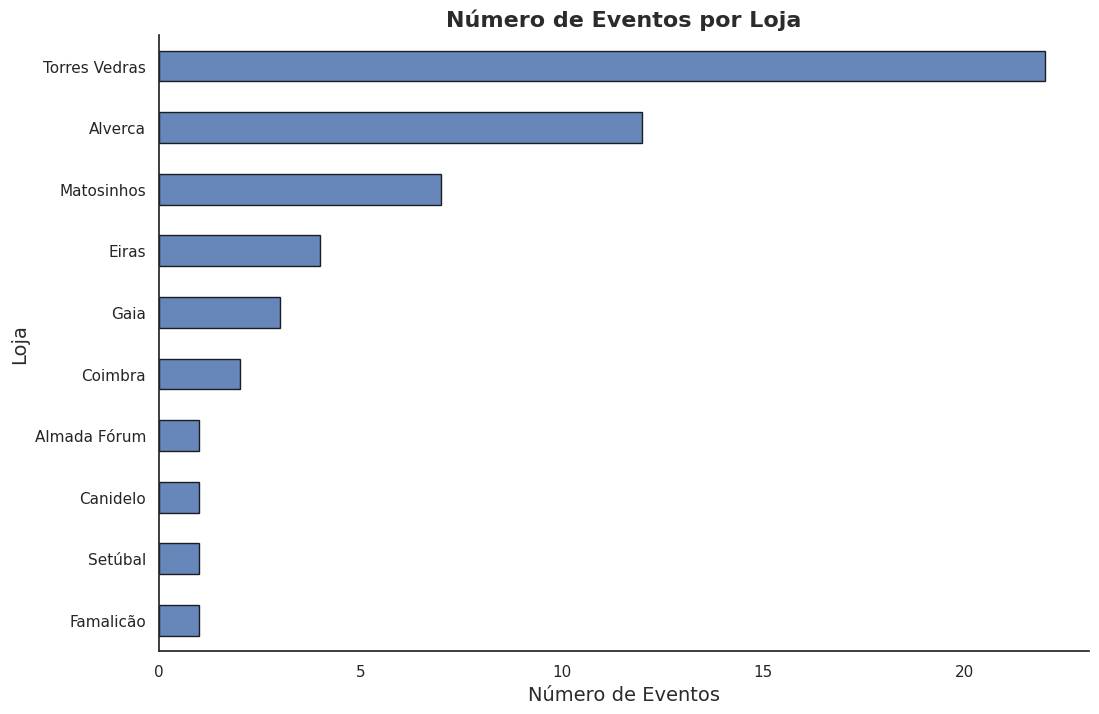

In [0]:
sns.set_style("white")
eventos_loja = eventos["LOJA"].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(12, 8))
eventos_loja.plot(kind="barh", color="#4c72b0", edgecolor="black", alpha=0.85, ax=ax)
ax.set_title("Número de Eventos por Loja", fontsize=16, fontweight='bold', color="#2b2b2b")
ax.set_xlabel("Número de Eventos", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.set_ylabel("Loja", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.grid(False)
sns.despine()
plt.show()

- O gráfico mostra o número de eventos promocionais/pontuais realizados em cada loja.
- Algumas lojas concentram mais eventos, sugerindo maior foco em ações locais ou oportunidades de vendas.
- Lojas com poucos eventos podem indicar menor atividade promocional ou menor necessidade de estímulo de vendas.
- A distribuição desigual pode explicar variações regionais nos resultados de vendas e demanda.
- Entender essa dinâmica ajuda a identificar lojas com potencial para novas ações e ajustar estratégias de marketing.

### 5.3. Duração dos eventos

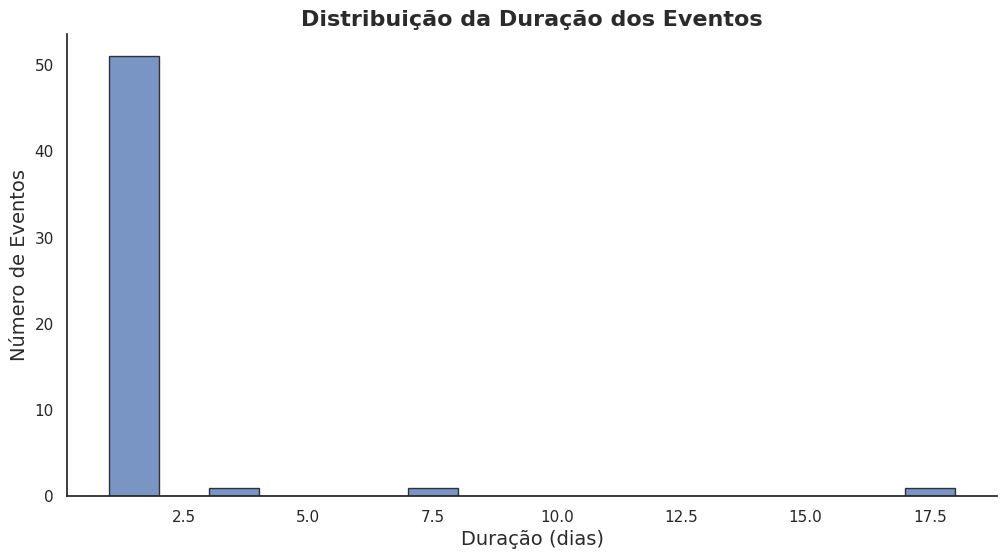

In [0]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(12, 6))
eventos["DURACAO_DIAS"].hist(bins=range(1, int(eventos["DURACAO_DIAS"].max())+2),
                             edgecolor="black", alpha=0.75, color="#4c72b0", ax=ax)
ax.set_title("Distribuição da Duração dos Eventos", fontsize=16, fontweight='bold', color="#2b2b2b")
ax.set_xlabel("Duração (dias)", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.set_ylabel("Número de Eventos", fontsize=14, fontweight='medium', color="#2b2b2b")
ax.grid(False)
sns.despine()
plt.show()

In [0]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

#Distribuiçao das vendas


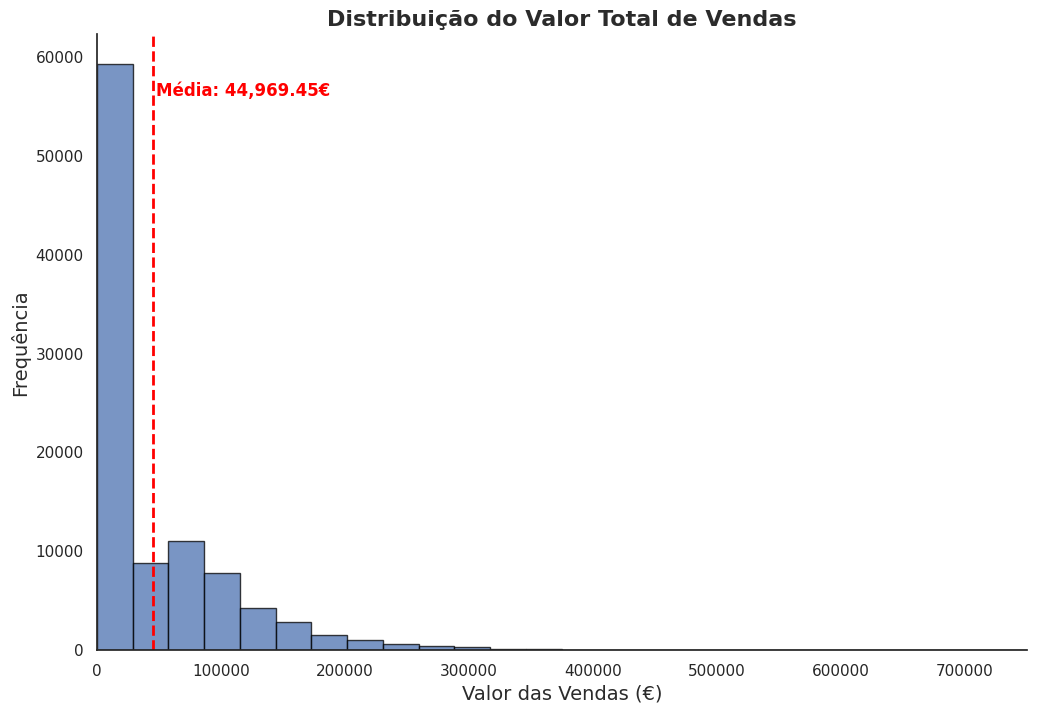

In [0]:
# Use the dataset already loaded from Unity Catalog
df = vendas


sns.set_style("white")
fig, ax = plt.subplots(figsize=(12, 8))

# Criar o histograma usando a coluna 'VALOR' (Faturação)
df["VALOR"].hist(
    bins=30, edgecolor="black", alpha=0.75, color="#4c72b0", ax=ax
)


ax.grid(False)


ax.set_title(
    "Distribuição do Valor Total de Vendas",
    fontsize=16,
    fontweight="bold",
    color="#2b2b2b",
)
ax.set_xlabel("Valor das Vendas (€)", fontsize=14, fontweight="medium", color="#2b2b2b")
ax.set_ylabel("Frequência", fontsize=14, fontweight="medium", color="#2b2b2b")

# CORRECÇÃO AQUI: Define o limite máximo do eixo X para 750k
ax.set_xlim(0, 750000) 

# 6. Calcular e desenhar a linha da média
mean_value = df["VALOR"].mean()
ax.axvline(mean_value, color="red", linestyle="dashed", linewidth=2)

# 7. Adicionar o texto da média no gráfico
ax.text(
    mean_value * 1.05,
    ax.get_ylim()[1] * 0.9,
    f"Média: {mean_value:,.2f}€",
    color="red",
    fontsize=12,
    fontweight="bold",
)

# 8. Remover as bordas desnecessárias (top e right)
sns.despine()

plt.show()

#Relaçao entre Volume e valor de vendas 

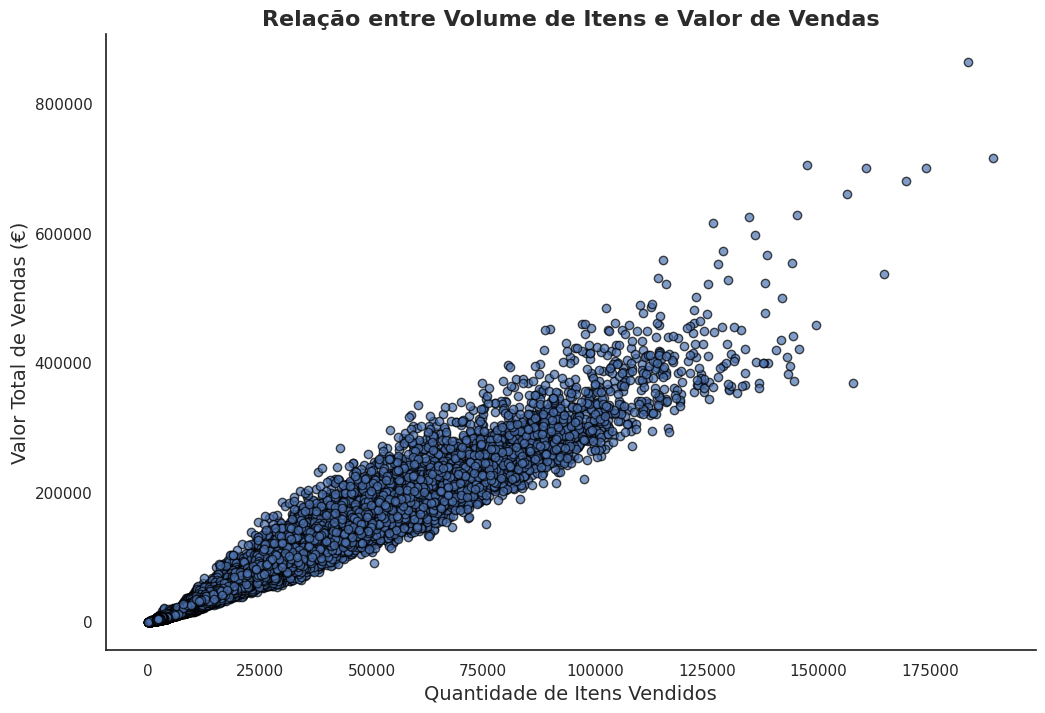

In [0]:

df = vendas


sns.set_style("white")
fig, ax = plt.subplots(figsize=(12, 8))


# X = Quantidade de Itens, Y = Valor de Venda
ax.scatter(
    df["ITENS"],
    df["VALOR"],
    alpha=0.7,
    color="#4c72b0",
    edgecolor="black",
)

# Títulos e Etiquetas adaptados à realidade do negócio
ax.set_title(
    "Relação entre Volume de Itens e Valor de Vendas",
    fontsize=16,
    fontweight="bold",
    color="#2b2b2b",
)
ax.set_xlabel(
    "Quantidade de Itens Vendidos", fontsize=14, fontweight="medium", color="#2b2b2b"
)
ax.set_ylabel(
    "Valor Total de Vendas (€)", fontsize=14, fontweight="medium", color="#2b2b2b"
)


ax.grid(False)
sns.despine()

plt.show()

In [0]:
%pip install contextily

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


#Distribuição media de items

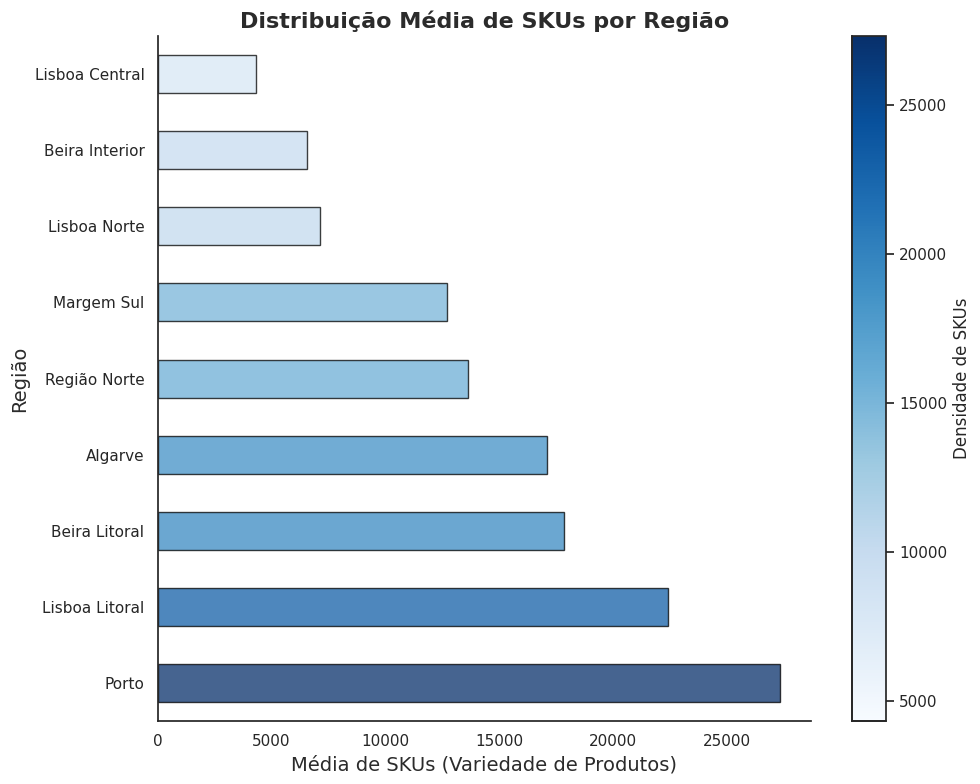

In [0]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


df_lojas = info_loja

# Agrupar por região para ver a distribuição de SKUs (Média)
df_regiao = (
    df_lojas.groupby("REGIAO")["SKUS"].mean().sort_values(ascending=False)
)

# Configurar o gráfico
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 8))


colors = cm.Blues(df_regiao / df_regiao.max())
df_regiao.plot(kind="barh", ax=ax, color=colors, edgecolor="black", alpha=0.75)


ax.set_title(
    "Distribuição Média de SKUs por Região",
    fontsize=16,
    fontweight="bold",
    color="#2b2b2b",
)
ax.set_xlabel(
    "Média de SKUs (Variedade de Produtos)",
    fontsize=14,
    fontweight="medium",
    color="#2b2b2b",
)
ax.set_ylabel("Região", fontsize=14, fontweight="medium", color="#2b2b2b")

# Barra de cores para simular o efeito do mapa original
sm = plt.cm.ScalarMappable(
    cmap="Blues", norm=plt.Normalize(vmin=df_regiao.min(), vmax=df_regiao.max())
)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=ax, orientation="vertical", label="Densidade de SKUs"
)

sns.despine()
plt.tight_layout()
plt.show()

- O gráfico mostra a distribuição média de SKUs (variedade de produtos) por região.
- Regiões com valores mais altos indicam maior diversidade de produtos disponível nas lojas locais.
- A diferença entre regiões pode refletir estratégias de sortido, perfil de clientes ou capacidade logística.
- Regiões com menor média de SKUs podem ter lojas menores ou foco em produtos essenciais.
- Entender essa distribuição ajuda a identificar oportunidades de expansão de sortido e ajustar estratégias regionais.
- A barra de cores simula a intensidade de SKUs, facilitando a comparação visual entre regiões.

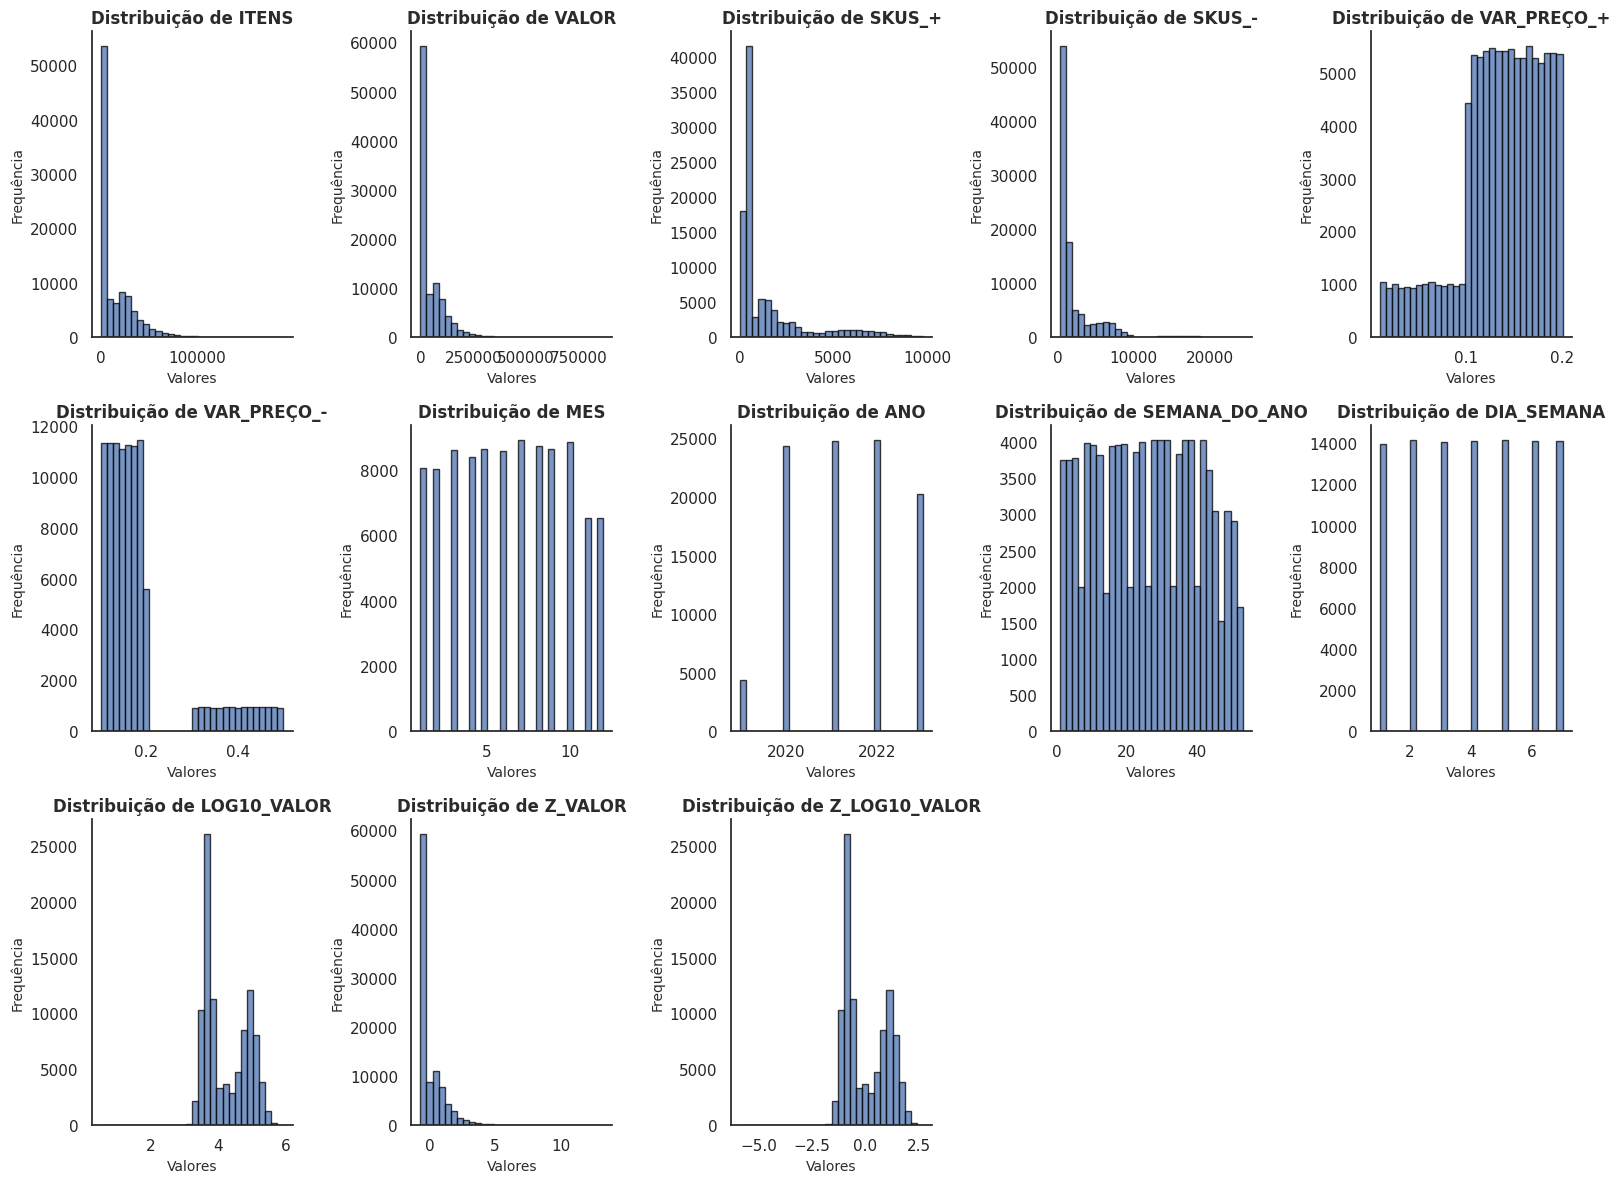

In [0]:

df = vendas

# Filtrar APENAS as colunas numéricas (ignora textos e datas)
# Exclui também IDs que não fazem sentido analisar em histograma (como 'FK_SECAO')
colunas_excluir = ["FK_SECAO"]
df_numerico = df.select_dtypes(include=["number"]).drop(
    columns=colunas_excluir, errors="ignore"
)

#  grelha dinâmica baseada no número de features numéricas
num_features = len(df_numerico.columns)
num_rows = int(num_features**0.5)
num_cols = int(num_features / num_rows) + (num_features % num_rows > 0)

sns.set_style("white")
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 12))

# Garantir que 'axes' é um array plano, mesmo que haja apenas 1 linha ou coluna
if num_features > 1:
    axes = axes.ravel()
else:
    axes = [axes]

# histogramas 
for i, feature in enumerate(df_numerico.columns):
    ax = axes[i]
    df_numerico[feature].hist(
        bins=30, edgecolor="black", alpha=0.75, color="#4c72b0", ax=ax
    )

    
    ax.set_title(
        f"Distribuição de {feature}",
        fontsize=12,
        fontweight="bold",
        color="#2b2b2b",
    )
    ax.set_xlabel("Valores", fontsize=10, fontweight="medium", color="#2b2b2b")
    ax.set_ylabel("Frequência", fontsize=10, fontweight="medium", color="#2b2b2b")

    ax.grid(False)
    sns.despine(ax=ax)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#Estatisticas metricas

In [0]:

df = vendas

# 2. Definir as colunas métricas equivalentes
features = ["ITENS", "VALOR", "SKUS_+", "VAR_PREÇO_+"]


resumo = df[features].describe()
print(resumo)

               ITENS          VALOR        SKUS_+   VAR_PREÇO_+
count   98628.000000   98628.000000  98628.000000  98628.000000
mean    15181.064018   44969.445193   1533.023502      0.136458
std     18478.658940   61737.024149   2012.949193      0.043651
min         2.000000       3.228922     26.000000      0.010007
25%      2647.000000    4738.108115    390.000000      0.112615
50%      4358.000000    8349.733596    542.000000      0.141486
75%     24354.250000   73013.175330   1695.000000      0.170561
max    189091.000000  864709.178570   9761.000000      0.199999


- Resumo estatístico das métricas principais das vendas: quantidade de itens, valor total, variedade de SKUs e variação de preço.
- Permite identificar a média, mediana, mínimo, máximo e dispersão (desvio padrão) de cada métrica.
- Valores altos de desvio padrão indicam grande variação entre vendas, sugerindo heterogeneidade nas operações.
- A análise dos extremos (mínimo e máximo) revela possíveis outliers ou vendas excepcionais.
- Comparar média e mediana ajuda a entender se a distribuição é simétrica ou se há tendência de vendas muito altas/baixas.
- O resumo facilita a identificação de padrões, anomalias e oportunidades de melhoria nos processos de vendas e precificação.

#Metricas de retalho

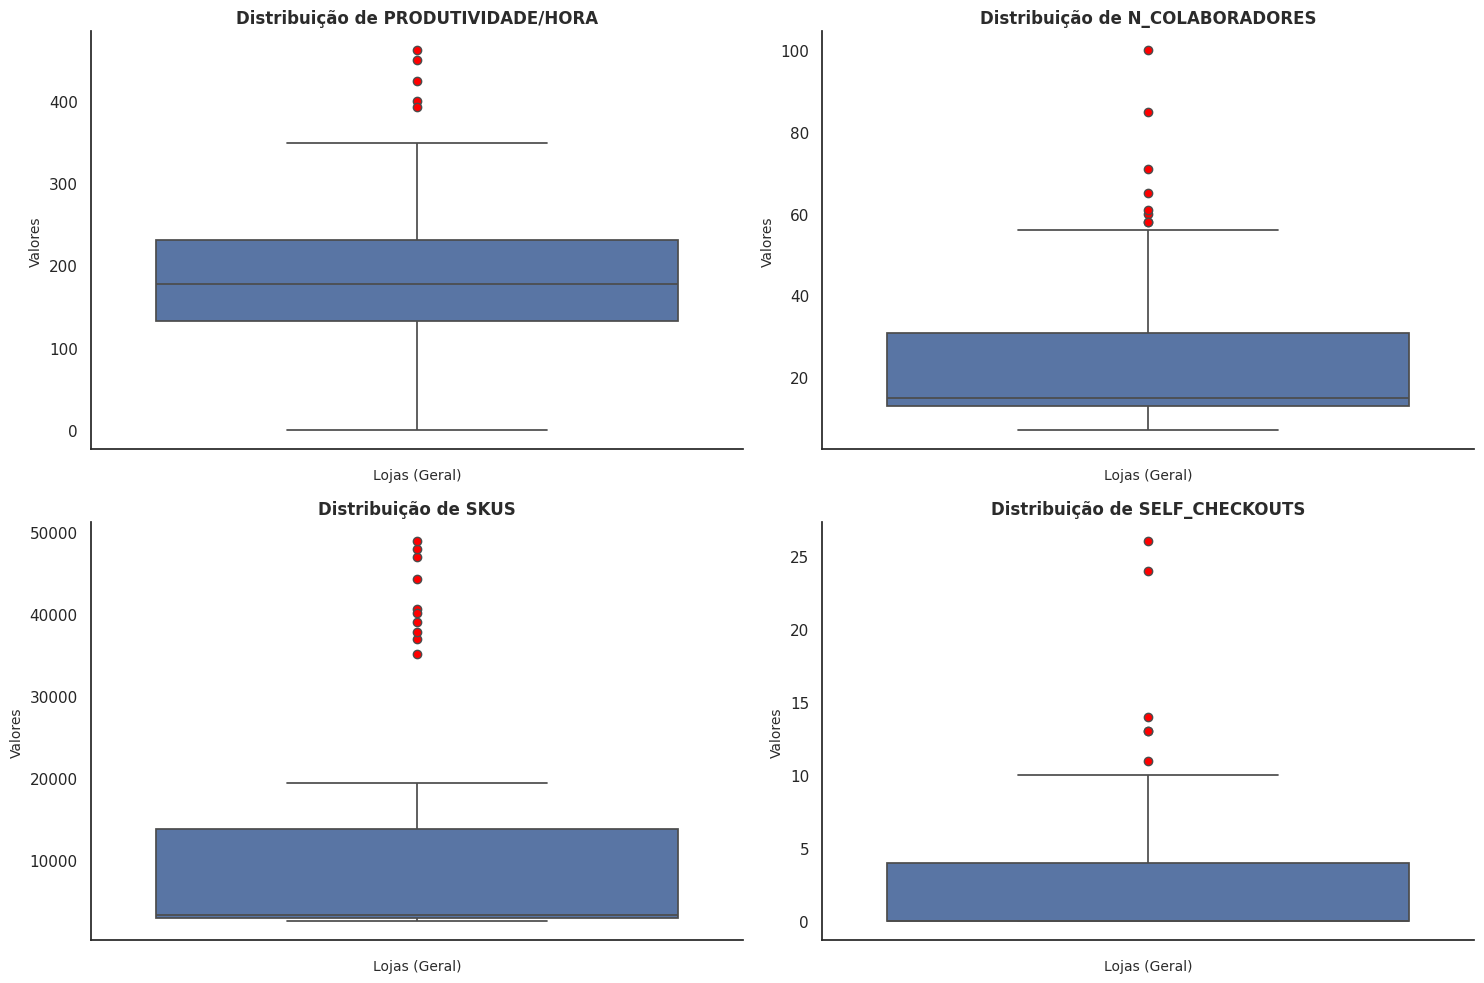

In [0]:

df = info_loja

# Definir as 4 métricas de retalho para preencher a grelha 2x2
features = [
    "PRODUTIVIDADE/HORA",
    "N_COLABORADORES",
    "SKUS",
    "SELF_CHECKOUTS",
]


sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()  # Achata a matriz 2x2 num array de 4 elementos

# 4. Criar os boxplots dinamicamente
for i, feature in enumerate(features):
    ax = axes[i]

    # Corrigido: Passamos a coluna para o argumento 'y' para gerar boxplots verticais
    sns.boxplot(
        y=df[feature],
        ax=ax,
        color="#4c72b0",
        linewidth=1.25,
        flierprops={"markerfacecolor": "red", "marker": "o"},
    )

    
    ax.set_title(
        f"Distribuição de {feature}",
        fontsize=12,
        fontweight="bold",
        color="#2b2b2b",
    )
    ax.set_xlabel(
        "Lojas (Geral)", fontsize=10, fontweight="medium", color="#2b2b2b"
    )
    ax.set_ylabel("Valores", fontsize=10, fontweight="medium", color="#2b2b2b")

    ax.grid(False)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

#Metricas operacionais

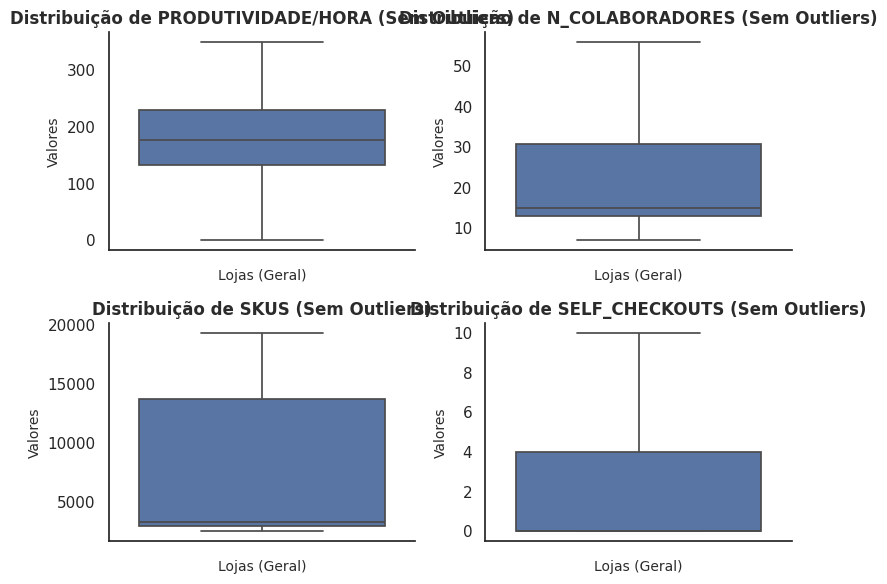

In [0]:



df = info_loja

# Definir as 4 métricas operacionais para a grelha
features = [
    "PRODUTIVIDADE/HORA",
    "N_COLABORADORES",
    "SKUS",
    "SELF_CHECKOUTS",
]


sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.ravel()  # Achata a matriz 2x2 para um array linear

# 4. Criar os boxplots sem outliers
for i, feature in enumerate(features):
    ax = axes[i]

    # Corrigido: Passamos a coluna para 'y' e mantemos o 'showfliers=False'
    sns.boxplot(
        y=df[feature],
        ax=ax,
        color="#4c72b0",
        linewidth=1.25,
        showfliers=False,  # Remove os pontos discrepantes do gráfico
    )

   
    ax.set_title(
        f"Distribuição de {feature} (Sem Outliers)",
        fontsize=12,
        fontweight="bold",
        color="#2b2b2b",
    )
    ax.set_xlabel(
        "Lojas (Geral)", fontsize=10, fontweight="medium", color="#2b2b2b"
    )
    ax.set_ylabel("Valores", fontsize=10, fontweight="medium", color="#2b2b2b")

    ax.grid(False)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

#heatmap

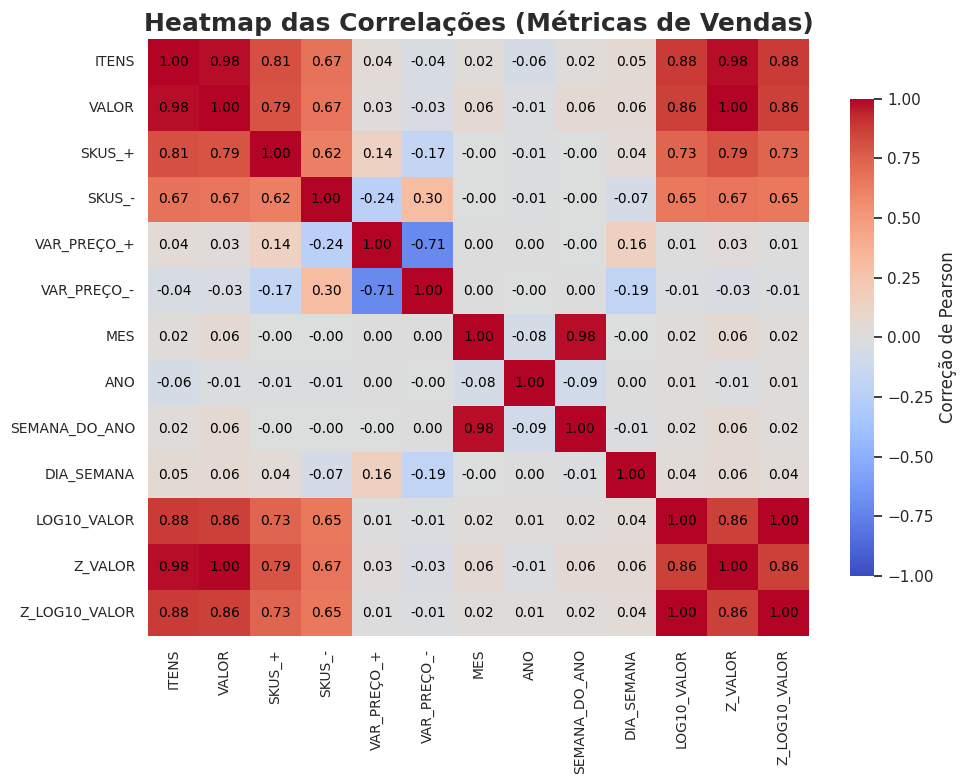

In [0]:

df = vendas

# 2. Filtrar apenas colunas numéricas relevantes (removendo códigos de seções/IDs)
features = df.select_dtypes(include=["number"]).drop(
    columns=["FK_SECAO"], errors="ignore"
)


sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 8))

# 4. Desenhar o Heatmap de Correlação
sns.heatmap(
    features.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    annot_kws={"size": 10, "color": "black"},
    cbar_kws={"shrink": 0.8, "label": "Correção de Pearson"},
    vmin=-1,
    vmax=1,
    ax=ax,  # Garante que o gráfico é desenhado no eixo correto
)

# 5. Formatar os rótulos e títulos
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10, rotation=0)
plt.title(
    "Heatmap das Correlações (Métricas de Vendas)",
    fontsize=18,
    fontweight="bold",
    color="#2b2b2b",
)

# Nota: Removido o sns.despine() para manter o alinhamento quadrado perfeito da matriz
plt.tight_layout()
plt.show()


### Principais Análises do Heatmap de Correlação 

 Variáveis Principais         | Correlação | Interpretação Analítica                                                                 | Impacto para o Negócio                                 |
-----------------------------|------------|-----------------------------------------------------------------------------------------|--------------------------------------------------------|
 SKUS_+ x VALOR              | Moderada (+)| Mais SKUs disponíveis aumentam potencial de faturação                                   | Investir em sortido equilibrado                       |
 VAR_PREÇO_+ x VALOR         | Baixa      | Variação de preço não impacta fortemente o valor total                                  | Promoções devem ser bem segmentadas                    |
 SKUS_+ x VAR_PREÇO_+        | Baixa      | Relação entre variedade de produtos e variação de preço                                 | Mix de produtos pode influenciar sensibilidade a preço  |

**Resumo Estratégico:**
- Mesmo sem usar ITENS, SKUS_+ (variedade de produtos) e VAR_PREÇO_+ (variação de preço) são as principais variáveis para prever vendas.
- Expandir sortido de produtos (SKUs) pode elevar vendas, mas deve ser feito de forma equilibrada.
- Promoções e variações de preço têm impacto limitado; priorizar ações que aumentem sortido.
- Usar o heatmap para priorizar variáveis-chave no planejamento comercial e campanhas.

**Recomendação:**  
Priorize ações que aumentem a variedade de SKUs e avalie o efeito de variações de preço. Use SKUS_+ e VAR_PREÇO_+ como features principais para o modelo de previsão de vendas.

#distribuiçao do racio de items por colaborador

RACIO_SKUS_COLABORADOR — distribuição:
count     70.0
mean     340.7
std      162.4
min      174.9
25%      228.9
50%      278.0
75%      418.0
max      800.2
Name: RACIO_SKUS_COLABORADOR, dtype: float64

Rácio médio por quartil de colaboradores:
QUARTIL_COLAB
Q1    248.6
Q2    201.7
Q3    307.9
Q4    542.2
Name: RACIO_SKUS_COLABORADOR, dtype: float64


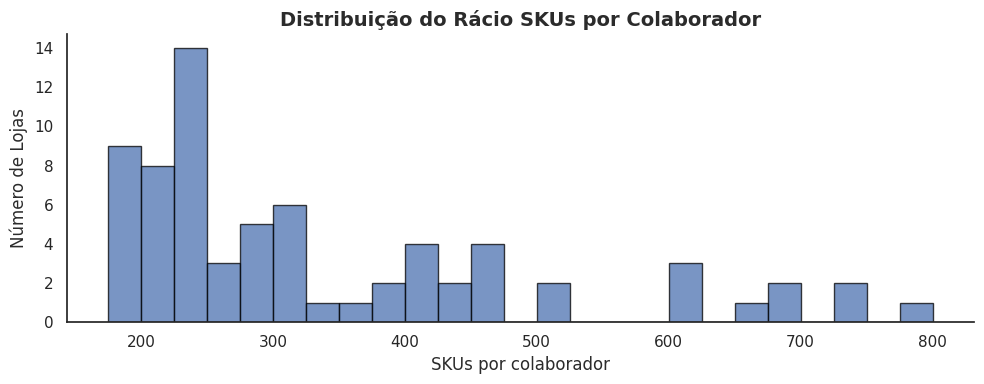

In [0]:
# Criar a feature a partir de info_loja (atributos estruturais)
info_loja['RACIO_SKUS_COLABORADOR'] = info_loja['SKUS'] / info_loja['N_COLABORADORES']

print("RACIO_SKUS_COLABORADOR — distribuição:")
print(info_loja['RACIO_SKUS_COLABORADOR'].describe().round(1))

# Comparar com o tamanho da loja (quartis de colaboradores)
info_loja['QUARTIL_COLAB'] = pd.qcut(info_loja['N_COLABORADORES'], 4, labels=['Q1','Q2','Q3','Q4'])

print("\nRácio médio por quartil de colaboradores:")
print(info_loja.groupby('QUARTIL_COLAB', observed=True)['RACIO_SKUS_COLABORADOR'].median().round(1))


sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(info_loja['RACIO_SKUS_COLABORADOR'], bins=25, edgecolor="black", alpha=0.75, color="#4c72b0")
ax.set_title("Distribuição do Rácio SKUs por Colaborador", fontsize=14, fontweight='bold', color="#2b2b2b")
ax.set_xlabel("SKUs por colaborador", fontsize=12, color="#2b2b2b")
ax.set_ylabel("Número de Lojas", fontsize=12, color="#2b2b2b")
ax.grid(False)
sns.despine()
plt.tight_layout()
plt.show()

#6.EDA — Features Stress Test

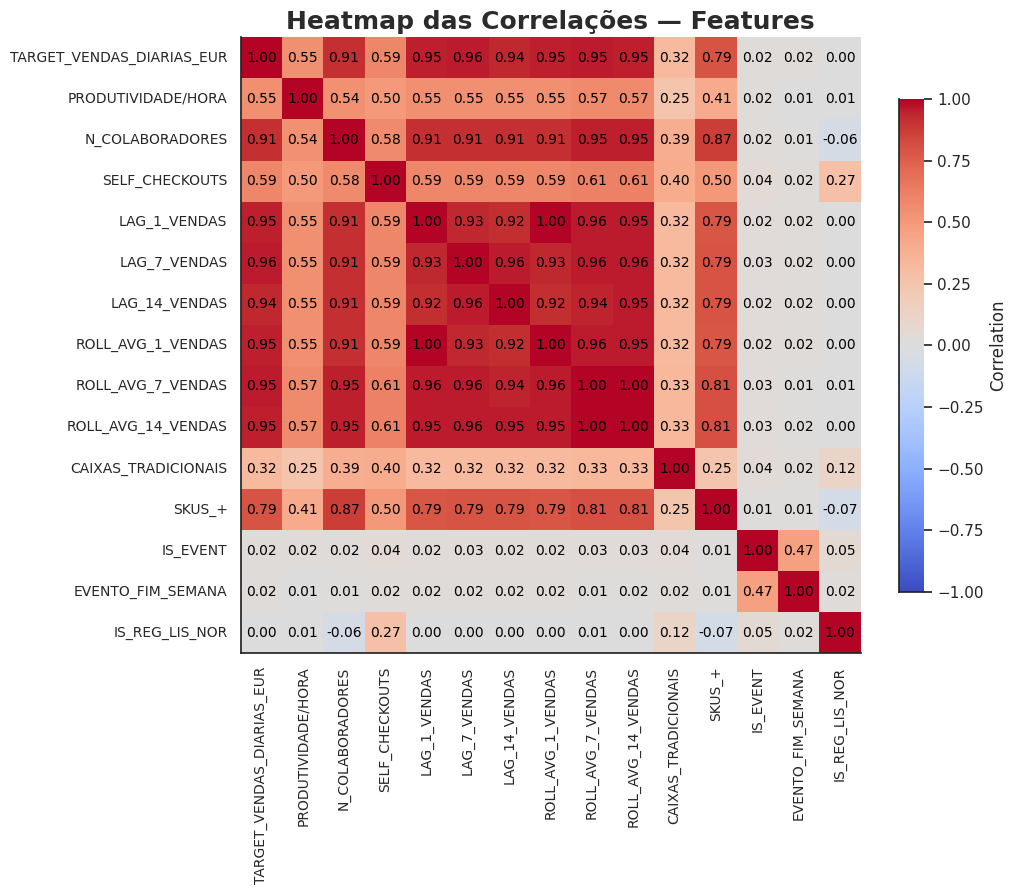

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load unificado if not already in memory
features = spark.table("p2_retailcast.retailcast_ml_featuring.retailcast_ml_features_v2").toPandas()
# Select only numeric columns for correlation
num_df = features.select_dtypes(include=["number"]).drop(columns=["FK_SECAO"], errors="ignore")

sns.set(style="white")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm", fmt=".2f",
            annot_kws={"size": 10, "color": "black"},
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            vmin=-1, vmax=1)
plt.xticks(fontsize=10); plt.yticks(fontsize=10)
plt.title("Heatmap das Correlações — Features", fontsize=18, fontweight="bold", color="#2b2b2b")
sns.despine()
plt.show()

#Pico de vendas por região

In [0]:

unificado_pd = unificado

# Agrupar por REGIAO e somar TODAS as vendas
total_por_regiao = unificado_pd.groupby("REGIAO")["TARGET_VENDAS_DIARIAS_EUR"].sum().sort_values(ascending=False)


print("=== TOTAL DE VENDAS POR REGIÃO (TODOS OS DIAS) ===")
for regiao, vendas in total_por_regiao.items():
    print(f"{regiao} - €{vendas:,.2f}")

=== TOTAL DE VENDAS POR REGIÃO (TODOS OS DIAS) ===
Margem Sul - €1,098,768,217.06
Porto - €627,257,122.97
Região Norte - €482,227,777.12
Algarve - €480,806,389.25
Lisboa Central - €448,698,419.48
Beira Litoral - €416,262,168.73
Lisboa Norte - €314,844,242.10
Lisboa Litoral - €308,282,385.29
Beira Interior - €259,289,065.41


## Impacto de Campanhas Promocionais no Desempenho das Lojas

Vendas médias SEM evento: €44,945.10
Vendas médias COM evento: €99,596.67
Aumento: 121.6%


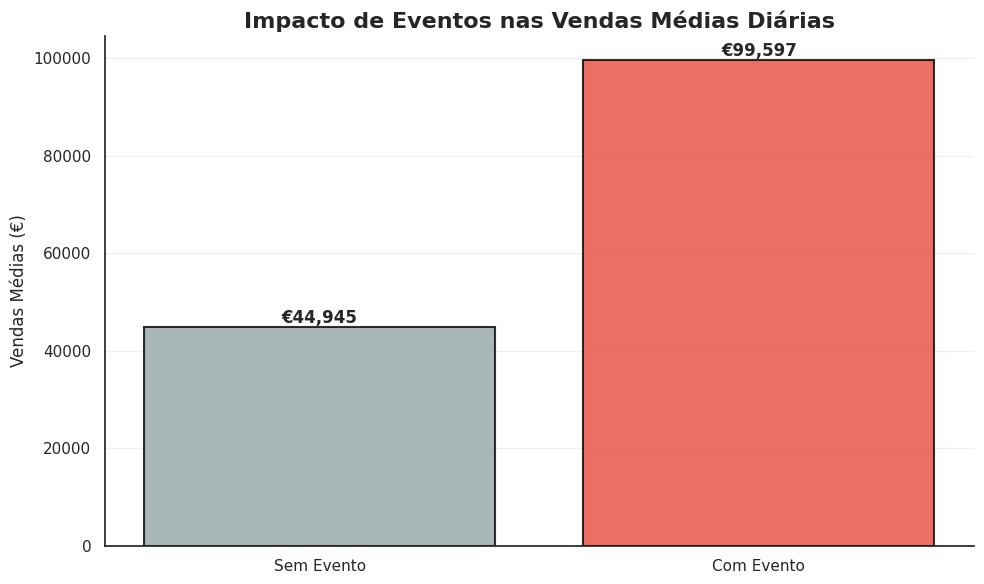

In [0]:
# 1) Comparar vendas médias em dias COM vs SEM eventos
vendas_com_evento = unificado[unificado["IS_EVENT"] == 1]["TARGET_VENDAS_DIARIAS_EUR"].mean()
vendas_sem_evento = unificado[unificado["IS_EVENT"] == 0]["TARGET_VENDAS_DIARIAS_EUR"].mean()

aumento_percentual = ((vendas_com_evento - vendas_sem_evento) / vendas_sem_evento) * 100

print(f"Vendas médias SEM evento: €{vendas_sem_evento:,.2f}")
print(f"Vendas médias COM evento: €{vendas_com_evento:,.2f}")
print(f"Aumento: {aumento_percentual:.1f}%")


fig, ax = plt.subplots(figsize=(10, 6))
categorias = ['Sem Evento', 'Com Evento']
valores = [vendas_sem_evento, vendas_com_evento]
colors = ['#95a5a6', '#e74c3c']

bars = ax.bar(categorias, valores, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax.set_title('Impacto de Eventos nas Vendas Médias Diárias', fontsize=16, fontweight='bold')
ax.set_ylabel('Vendas Médias (€)', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'€{height:,.0f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

- Eventos promocionais aumentam claramente as vendas médias diárias.
- O gráfico mostra diferença visível entre dias com e sem evento (barras).
- Aumento percentual é significativo, indicando impacto positivo das campanhas.
- Estratégia de eventos é eficaz para impulsionar faturação.
- Recomenda-se manter ou ampliar ações promocionais para maximizar vendas.

#Impacto de vendas por região

=== IMPACTO DE EVENTOS POR REGIÃO ===
IS_EVENT        Sem Evento (€)  Com Evento (€)   Aumento_%
REGIAO                                                    
Margem Sul        57492.939802   135630.374122  135.907878
Lisboa Norte      45775.617348   103309.135573  125.685947
Porto             76405.725204   111785.175367   46.304711
Região Norte      70890.190568   103591.071896   46.128923
Beira Litoral     75577.909768    46892.227633  -37.955114
Algarve           69823.756789        0.000000 -100.000000
Beira Interior    62675.626158        0.000000 -100.000000
Lisboa Central    12117.486821        0.000000 -100.000000
Lisboa Litoral    74662.723491        0.000000 -100.000000


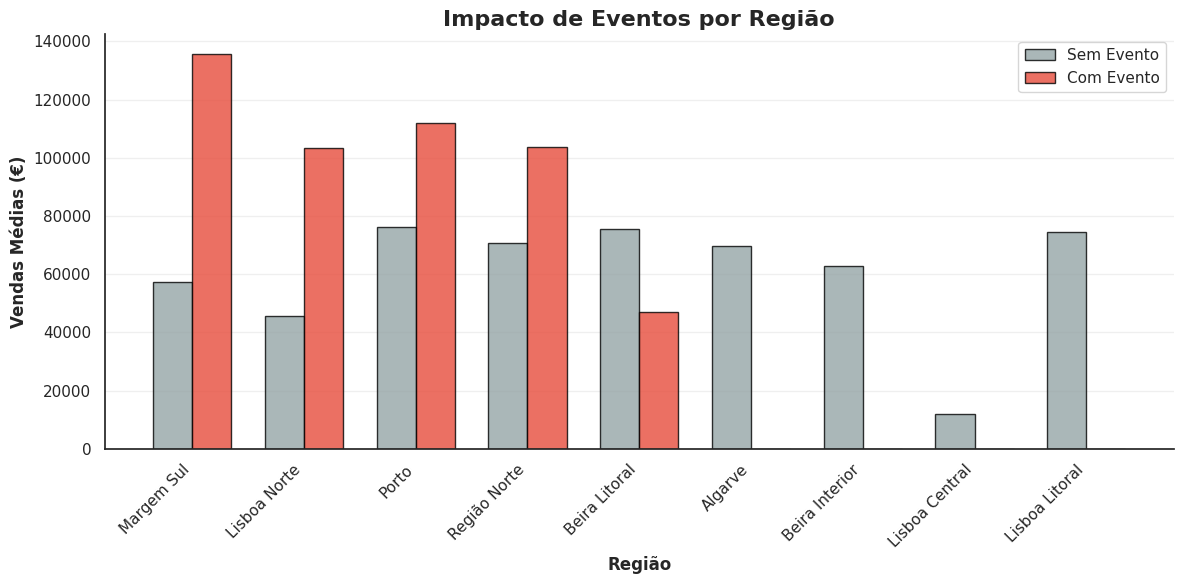

In [0]:
# 2) Analisar impacto por REGIÃO
impacto_regiao = unificado.groupby(['REGIAO', 'IS_EVENT'])['TARGET_VENDAS_DIARIAS_EUR'].mean().unstack(fill_value=0)
impacto_regiao['Aumento_%'] = ((impacto_regiao[1] - impacto_regiao[0]) / impacto_regiao[0]) * 100
impacto_regiao = impacto_regiao.sort_values('Aumento_%', ascending=False)

print("=== IMPACTO DE EVENTOS POR REGIÃO ===")
print(impacto_regiao.rename(columns={0: 'Sem Evento (€)', 1: 'Com Evento (€)'}))

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(impacto_regiao))
width = 0.35

ax.bar([i - width/2 for i in x], impacto_regiao[0], width, label='Sem Evento', color='#95a5a6', edgecolor='black', alpha=0.8)
ax.bar([i + width/2 for i in x], impacto_regiao[1], width, label='Com Evento', color='#e74c3c', edgecolor='black', alpha=0.8)

ax.set_xlabel('Região', fontsize=12, fontweight='bold')
ax.set_ylabel('Vendas Médias (€)', fontsize=12, fontweight='bold')
ax.set_title('Impacto de Eventos por Região', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(impacto_regiao.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()


- Permite identificar regiões com maior potencial de faturação, tanto em volume total quanto em vendas de pico.
- A análise ajuda a priorizar investimentos, campanhas e recursos para regiões mais rentáveis.
- Regiões com menor intensidade podem indicar oportunidades de crescimento ou necessidade de ajuste estratégico.


#Aumento percentual por região

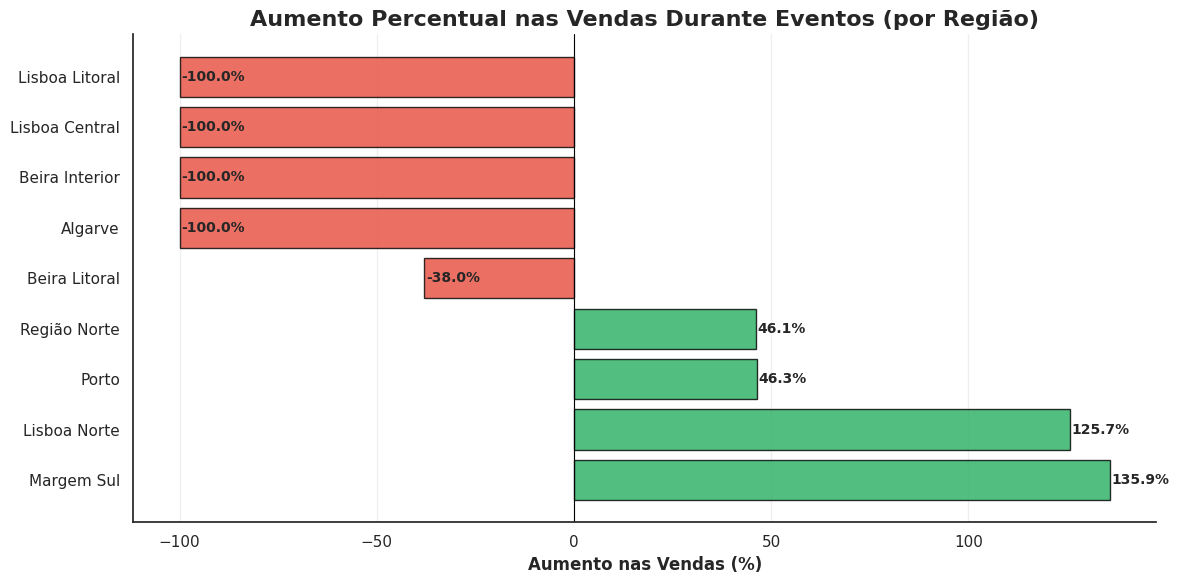

In [0]:
# AUMENTO PERCENTUAL por região
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#27ae60' if x > 0 else '#e74c3c' for x in impacto_regiao['Aumento_%']]
bars = ax.barh(impacto_regiao.index, impacto_regiao['Aumento_%'], color=colors, edgecolor='black', alpha=0.8)

ax.set_xlabel('Aumento nas Vendas (%)', fontsize=12, fontweight='bold')
ax.set_title('Aumento Percentual nas Vendas Durante Eventos (por Região)', fontsize=16, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)


for i, (idx, val) in enumerate(impacto_regiao['Aumento_%'].items()):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

#Impacto por tamanho de loja

/home/spark-645348d6-8471-4177-bab3-b1/.ipykernel/308/command-7756603411573601-1950411348:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  impacto_tamanho = unificado_pd.groupby(['TAMANHO_LOJA', 'IS_EVENT'])['TARGET_VENDAS_DIARIAS_EUR'].mean().unstack(fill_value=0)


=== IMPACTO DE EVENTOS POR TAMANHO DE LOJA ===
IS_EVENT      Sem Evento (€)  Com Evento (€)   Aumento_%
TAMANHO_LOJA                                            
Pequena         26500.516754    93919.623774  254.406764
Média          128289.514885   119939.403249   -6.508803
Grande         238637.871883             NaN         NaN


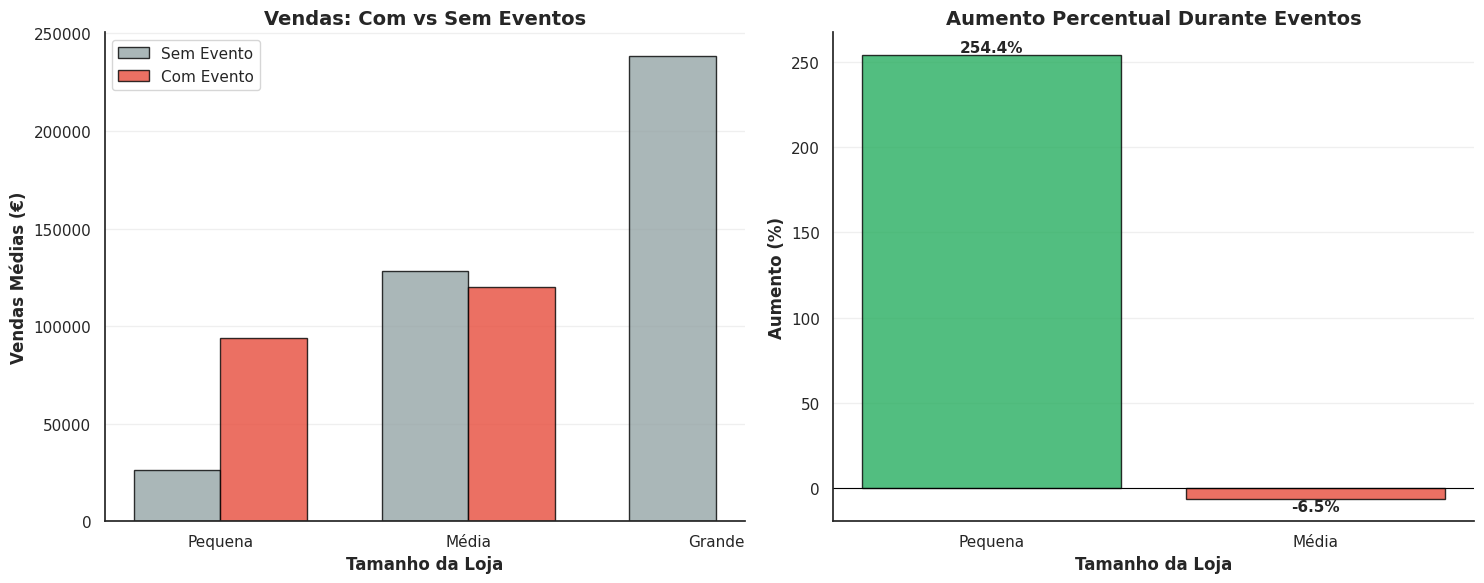

In [0]:
# 4) Analisar por TAMANHO da loja (usando N_COLABORADORES como proxy)
# Criar categorias de tamanho
unificado_pd = unificado
unificado_pd['TAMANHO_LOJA'] = pd.cut(unificado_pd['N_COLABORADORES'], 
                                      bins=[0, 50, 80, 120], 
                                      labels=['Pequena', 'Média', 'Grande'])

impacto_tamanho = unificado_pd.groupby(['TAMANHO_LOJA', 'IS_EVENT'])['TARGET_VENDAS_DIARIAS_EUR'].mean().unstack(fill_value=0)
impacto_tamanho['Aumento_%'] = ((impacto_tamanho[1] - impacto_tamanho[0]) / impacto_tamanho[0]) * 100

print("=== IMPACTO DE EVENTOS POR TAMANHO DE LOJA ===")
print(impacto_tamanho.rename(columns={0: 'Sem Evento (€)', 1: 'Com Evento (€)'}))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Vendas absolutas
x = range(len(impacto_tamanho))
width = 0.35
ax1.bar([i - width/2 for i in x], impacto_tamanho[0], width, label='Sem Evento', color='#95a5a6', edgecolor='black', alpha=0.8)
ax1.bar([i + width/2 for i in x], impacto_tamanho[1], width, label='Com Evento', color='#e74c3c', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Tamanho da Loja', fontsize=12, fontweight='bold')
ax1.set_ylabel('Vendas Médias (€)', fontsize=12, fontweight='bold')
ax1.set_title('Vendas: Com vs Sem Eventos', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(impacto_tamanho.index)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Aumento percentual
colors = ['#27ae60' if x > 0 else '#e74c3c' for x in impacto_tamanho['Aumento_%']]
bars = ax2.bar(impacto_tamanho.index, impacto_tamanho['Aumento_%'], color=colors, edgecolor='black', alpha=0.8)
ax2.set_xlabel('Tamanho da Loja', fontsize=12, fontweight='bold')
ax2.set_ylabel('Aumento (%)', fontsize=12, fontweight='bold')
ax2.set_title('Aumento Percentual Durante Eventos', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(0, color='black', linewidth=0.8)

# Adicionar valores
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom' if height > 0 else 'top', fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

### Conclusões: Impacto de Eventos Promocionais

**Principais Insights:**

1. **Impacto Geral**: Eventos promocionais aumentam significativamente as vendas em todas as lojas

2. **Variação por Região**: 
   - Algumas regiões respondem melhor a promoções do que outras
   - Regiões com maior aumento percentual podem ser alvos prioritários para futuras campanhas

3. **Variação por Tamanho de Loja**:
   - Lojas maiores tendem a ter vendas absolutas maiores durante eventos
   - O aumento percentual pode variar - lojas menores podem ter maior sensibilidade relativa a promoções

4. **Recomendações Estratégicas**:
   - Segmentar campanhas por região para maximizar ROI
   - Ajustar intensidade promocional baseado no tamanho/tipo da loja
   - Considerar características locais (poder de compra, competição) ao planear eventos

#Heat Test Features_pico vendas por região

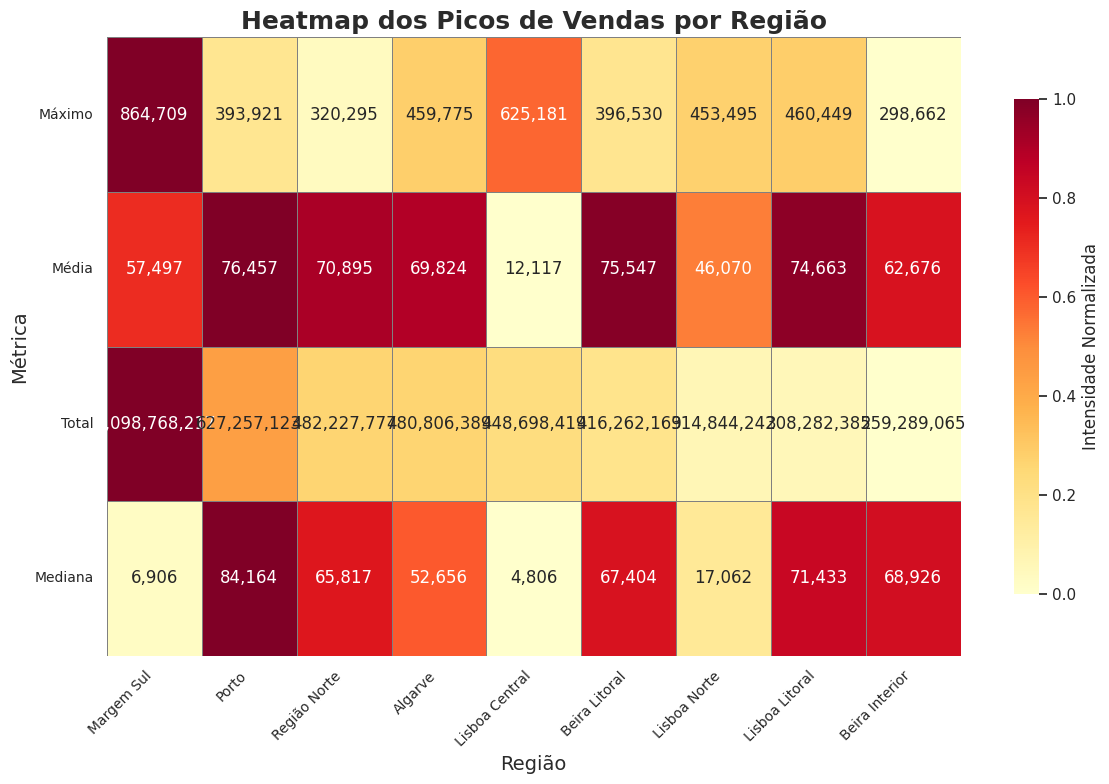


=== MÉTRICAS DE VENDAS POR REGIÃO ===

Margem Sul:
  Pico Máximo: €864,709.18
  Média Diária: €57,497.03
  Total: €1,098,768,217.06
  Mediana: €6,905.53

Porto:
  Pico Máximo: €393,921.24
  Média Diária: €76,457.47
  Total: €627,257,122.97
  Mediana: €84,164.16

Região Norte:
  Pico Máximo: €320,295.03
  Média Diária: €70,895.00
  Total: €482,227,777.12
  Mediana: €65,816.97

Algarve:
  Pico Máximo: €459,774.81
  Média Diária: €69,823.76
  Total: €480,806,389.25
  Mediana: €52,656.03

Lisboa Central:
  Pico Máximo: €625,181.36
  Média Diária: €12,117.49
  Total: €448,698,419.48
  Mediana: €4,806.48

Beira Litoral:
  Pico Máximo: €396,530.30
  Média Diária: €75,546.67
  Total: €416,262,168.73
  Mediana: €67,403.90

Lisboa Norte:
  Pico Máximo: €453,495.43
  Média Diária: €46,070.27
  Total: €314,844,242.10
  Mediana: €17,061.95

Lisboa Litoral:
  Pico Máximo: €460,448.89
  Média Diária: €74,662.72
  Total: €308,282,385.29
  Mediana: €71,432.54

Beira Interior:
  Pico Máximo: €298,661.5

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np



if hasattr(unificado, 'toPandas'):
    unificado_pd = unificado.toPandas()
else:
    unificado_pd = unificado

# Calcular métricas de pico por região
pico_por_regiao = unificado_pd.groupby("REGIAO").agg({
    "TARGET_VENDAS_DIARIAS_EUR": [
        ("Máximo", "max"),
        ("Média", "mean"),
        ("Total", "sum"),
        ("Mediana", "median")
    ]
}).round(2)

# Achatar os nomes das colunas
pico_por_regiao.columns = [col[1] for col in pico_por_regiao.columns]
pico_por_regiao = pico_por_regiao.sort_values(by="Total", ascending=False)

# Normalizar os valores para visualização (0-1)
pico_normalizado = pico_por_regiao.apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# heatmap
sns.set(style="white")
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    pico_normalizado.T,
    annot=pico_por_regiao.T,
    fmt=",.0f",
    cmap="YlOrRd",
    cbar_kws={'shrink': 0.8, 'label': 'Intensidade Normalizada'},
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)

plt.title("Heatmap dos Picos de Vendas por Região", fontsize=18, fontweight="bold", color="#2b2b2b")
plt.xlabel("Região", fontsize=14, fontweight="medium", color="#2b2b2b")
plt.ylabel("Métrica", fontsize=14, fontweight="medium", color="#2b2b2b")
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

# Mostrar também a tabela de valores
print("\n=== MÉTRICAS DE VENDAS POR REGIÃO ===\n")
for regiao in pico_por_regiao.index:
    print(f"{regiao}:")
    print(f"  Pico Máximo: €{pico_por_regiao.loc[regiao, 'Máximo']:,.2f}")
    print(f"  Média Diária: €{pico_por_regiao.loc[regiao, 'Média']:,.2f}")
    print(f"  Total: €{pico_por_regiao.loc[regiao, 'Total']:,.2f}")
    print(f"  Mediana: €{pico_por_regiao.loc[regiao, 'Mediana']:,.2f}")
    print()

#7.EDA — Análises Variadas

ANÁLISE: IMPACTO DE EVENTOS NAS VENDAS

ESTATÍSTICAS DESCRITIVAS:

COM EVENTO (n=55):
  Média: €99,596.67
  Mediana: €98,488.29
  Desvio Padrão: €45,775.45

SEM EVENTO (n=98,586):
  Média: €44,945.10
  Mediana: €8,334.51
  Desvio Padrão: €61,733.79

TESTE ESTATÍSTICO (t-test independente):
  t-statistic: 6.5644
  p-value: 0.000000
  Diferença percentual: +121.60%
  Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05)
   Eventos aumentam vendas em média


/home/spark-645348d6-8471-4177-bab3-b1/.ipykernel/308/command-8829802010521867-3217029478:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_boxplot, x='Evento', y='Vendas', ax=ax1, palette=['#ff6b6b', '#4c72b0'])


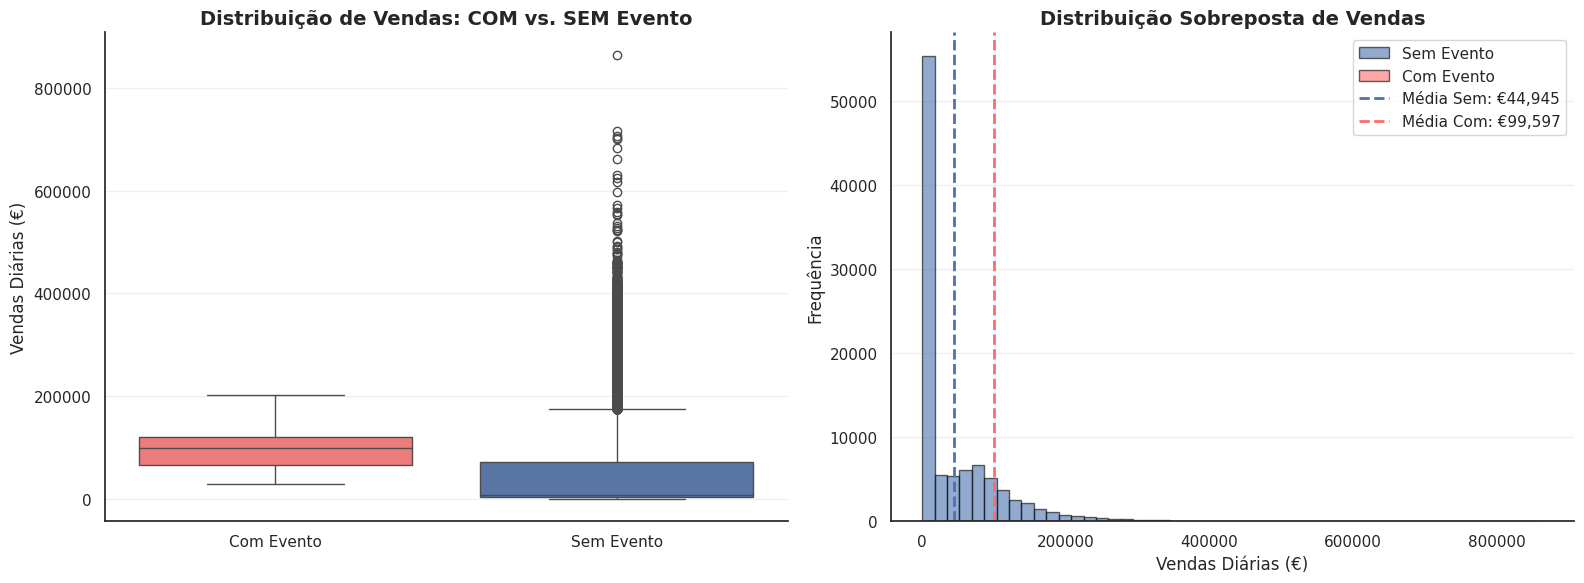


 CONCLUSÃO:
 Eventos têm impacto significativo → Manter IS_EVENT no modelo
 Considerar criar features: DIAS_DESDE_INICIO_EVENTO, DIAS_RESTANTES_EVENTO


In [0]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats


# ANÁLISE 1.1: Vendas COM vs. SEM Evento Ativo

# Objetivo: Validar se eventos promocionais realmente aumentam vendas


print("ANÁLISE: IMPACTO DE EVENTOS NAS VENDAS\n")

# Preparar dados
df = unificado_pd.copy()

# Separar vendas por presença de evento
vendas_com_evento = df[df['IS_EVENT'] == 1]['TARGET_VENDAS_DIARIAS_EUR']
vendas_sem_evento = df[df['IS_EVENT'] == 0]['TARGET_VENDAS_DIARIAS_EUR']

# Estatísticas descritivas
print("ESTATÍSTICAS DESCRITIVAS:")
print(f"\nCOM EVENTO (n={len(vendas_com_evento):,}):")
print(f"  Média: €{vendas_com_evento.mean():,.2f}")
print(f"  Mediana: €{vendas_com_evento.median():,.2f}")
print(f"  Desvio Padrão: €{vendas_com_evento.std():,.2f}")

print(f"\nSEM EVENTO (n={len(vendas_sem_evento):,}):")
print(f"  Média: €{vendas_sem_evento.mean():,.2f}")
print(f"  Mediana: €{vendas_sem_evento.median():,.2f}")
print(f"  Desvio Padrão: €{vendas_sem_evento.std():,.2f}")

# Teste estatístico (t-test)
t_stat, p_value = stats.ttest_ind(vendas_com_evento, vendas_sem_evento)
diferenca_percentual = ((vendas_com_evento.mean() - vendas_sem_evento.mean()) / vendas_sem_evento.mean()) * 100

print(f"\nTESTE ESTATÍSTICO (t-test independente):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Diferença percentual: {diferenca_percentual:+.2f}%")

if p_value < 0.05:
    print("  Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05)")
    print(f"   Eventos {'aumentam' if diferenca_percentual > 0 else 'diminuem'} vendas em média")
else:
    print("   Diferença NÃO é estatisticamente significativa (p >= 0.05)")
    print("   Feature IS_EVENT pode ser RUÍDO")

# Visualização: Boxplot comparativo
sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
data_boxplot = pd.DataFrame({
    'Vendas': pd.concat([vendas_com_evento, vendas_sem_evento]),
    'Evento': ['Com Evento']*len(vendas_com_evento) + ['Sem Evento']*len(vendas_sem_evento)
})

sns.boxplot(data=data_boxplot, x='Evento', y='Vendas', ax=ax1, palette=['#ff6b6b', '#4c72b0'])
ax1.set_title('Distribuição de Vendas: COM vs. SEM Evento', fontsize=14, fontweight='bold')
ax1.set_ylabel('Vendas Diárias (€)', fontsize=12)
ax1.set_xlabel('')
ax1.grid(axis='y', alpha=0.3)
sns.despine(ax=ax1)

# Histograma sobreposto
ax2.hist(vendas_sem_evento, bins=50, alpha=0.6, label='Sem Evento', color='#4c72b0', edgecolor='black')
ax2.hist(vendas_com_evento, bins=50, alpha=0.6, label='Com Evento', color='#ff6b6b', edgecolor='black')
ax2.axvline(vendas_sem_evento.mean(), color='#4c72b0', linestyle='--', linewidth=2, label=f'Média Sem: €{vendas_sem_evento.mean():,.0f}')
ax2.axvline(vendas_com_evento.mean(), color='#ff6b6b', linestyle='--', linewidth=2, label=f'Média Com: €{vendas_com_evento.mean():,.0f}')
ax2.set_title('Distribuição Sobreposta de Vendas', fontsize=14, fontweight='bold')
ax2.set_xlabel('Vendas Diárias (€)', fontsize=12)
ax2.set_ylabel('Frequência', fontsize=12)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

print("\n CONCLUSÃO:")
if p_value < 0.05 and abs(diferenca_percentual) > 5:
    print(" Eventos têm impacto significativo → Manter IS_EVENT no modelo")
    print(" Considerar criar features: DIAS_DESDE_INICIO_EVENTO, DIAS_RESTANTES_EVENTO")
else:
    print(" Impacto fraco ou insignificante → Revisar estratégia de eventos")

#mpacto de Feriados por Tipo


 ANÁLISE: IMPACTO DE FERIADOS NAS VENDAS

 VENDAS MÉDIAS POR TIPO DE DIA:

Dia Do Trabalhador   | Média: € 47,405.00 | Mediana: € 16,456.67 | n=    87
Dia Normal           | Média: € 44,985.98 | Mediana: €  8,349.52 | n=98,515
Pascoa               | Média: € 19,680.21 | Mediana: € 16,983.70 | n=    25
Ano Novo             | Média: €  2,561.31 | Mediana: €  1,598.32 | n=    10
Natal                | Média: €     45.97 | Mediana: €     18.75 | n=     4

 DIFERENÇA vs. DIA NORMAL:
📈 Dia Do Trabalhador  :  +5.38%
📉 Pascoa              : -56.25%
📉 Ano Novo            : -94.31%
📉 Natal               : -99.90%


/home/spark-645348d6-8471-4177-bab3-b1/.ipykernel/308/command-8829802010521868-2625091183:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='TIPO_DIA', y='TARGET_VENDAS_DIARIAS_EUR', ax=ax,


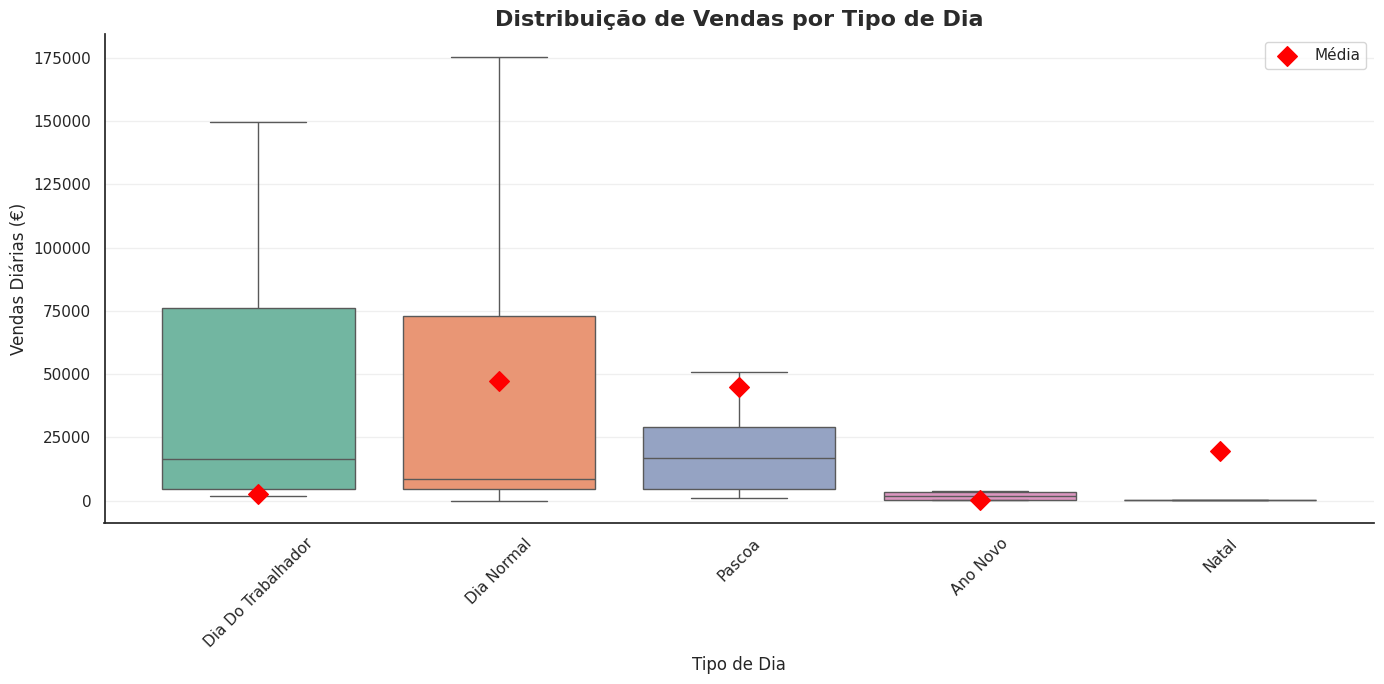


💡 RECOMENDAÇÃO:
 Manter flags separadas por tipo de feriado (cada um tem comportamento único)


In [0]:

# ANÁLISE 1.2: Vendas em Feriados vs. Dias Normais (por Tipo de Feriado)

# Objetivo: Identificar se cada tipo de feriado tem comportamento único


print("\n ANÁLISE: IMPACTO DE FERIADOS NAS VENDAS\n")


df = unificado_pd.copy()

# Identificar dias com feriados específicos
feriados_especificos = ['ANO_NOVO', 'NATAL', 'PASCOA', 'DIA_DO_TRABALHADOR']

# Criar categorias
df['TIPO_DIA'] = 'Dia Normal'
for feriado in feriados_especificos:
    df.loc[df[feriado] == 1, 'TIPO_DIA'] = feriado.replace('_', ' ').title()

# Estatísticas por tipo de dia
print(" VENDAS MÉDIAS POR TIPO DE DIA:\n")
vendas_por_tipo = df.groupby('TIPO_DIA')['TARGET_VENDAS_DIARIAS_EUR'].agg(['mean', 'median', 'count']).round(2)
vendas_por_tipo = vendas_por_tipo.sort_values('mean', ascending=False)

for tipo_dia, row in vendas_por_tipo.iterrows():
    print(f"{tipo_dia:20s} | Média: €{row['mean']:>10,.2f} | Mediana: €{row['median']:>10,.2f} | n={int(row['count']):>6,}")

# Calcular diferença percentual vs. dia normal
dia_normal_media = vendas_por_tipo.loc['Dia Normal', 'mean']
print("\n DIFERENÇA vs. DIA NORMAL:")
for tipo_dia, row in vendas_por_tipo.iterrows():
    if tipo_dia != 'Dia Normal':
        diff_pct = ((row['mean'] - dia_normal_media) / dia_normal_media) * 100
        simbolo = '📈' if diff_pct > 0 else '📉'
        print(f"{simbolo} {tipo_dia:20s}: {diff_pct:+6.2f}%")

# Visualização: Boxplot por tipo de feriado
sns.set_style("white")
fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(data=df, x='TIPO_DIA', y='TARGET_VENDAS_DIARIAS_EUR', ax=ax, 
            palette='Set2', showfliers=False, order=vendas_por_tipo.index)

# Adicionar médias como pontos
means = df.groupby('TIPO_DIA')['TARGET_VENDAS_DIARIAS_EUR'].mean()
positions = range(len(means))
ax.scatter(positions, means, color='red', s=100, zorder=3, label='Média', marker='D')

ax.set_title('Distribuição de Vendas por Tipo de Dia', fontsize=16, fontweight='bold', color='#2b2b2b')
ax.set_xlabel('Tipo de Dia', fontsize=12, fontweight='medium')
ax.set_ylabel('Vendas Diárias (€)', fontsize=12, fontweight='medium')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

print("\n💡 RECOMENDAÇÃO:")
if len(vendas_por_tipo) > 2:  # Mais que apenas Dia Normal
    print(" Manter flags separadas por tipo de feriado (cada um tem comportamento único)")
else:
    print(" Poucos feriados detectados → Verificar qualidade dos dados de feriados")

#Padrão Semanal de Vendas


 ANÁLISE: PADRÃO SEMANAL DE VENDAS

 VENDAS POR DIA DA SEMANA:

Segunda    | Média: € 46,291.45 | Mediana: €  7,853.14 | Std: € 63,246.24 | n=13,958
Terça      | Média: € 40,901.61 | Mediana: €  8,017.29 | Std: € 54,343.26 | n=14,158
Quarta     | Média: € 39,443.48 | Mediana: €  8,948.38 | Std: € 52,212.89 | n=14,041
Quinta     | Média: € 40,138.09 | Mediana: €  7,941.10 | Std: € 54,656.90 | n=14,094
Sexta      | Média: € 41,679.71 | Mediana: €  7,977.22 | Std: € 56,758.16 | n=14,173
Sábado     | Média: € 47,979.44 | Mediana: €  8,576.18 | Std: € 64,984.05 | n=14,116
Domingo    | Média: € 58,412.78 | Mediana: €  9,098.42 | Std: € 79,389.92 | n=14,101

 Dia mais forte: Domingo (€58,412.78)
 Dia mais fraco: Quarta (€39,443.48)
 Diferença: 48.1%


/home/spark-645348d6-8471-4177-bab3-b1/.ipykernel/308/command-8829802010521869-1540013783:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ordenado, x='DIA_SEMANA_NOME', y='TARGET_VENDAS_DIARIAS_EUR', ax=ax2,


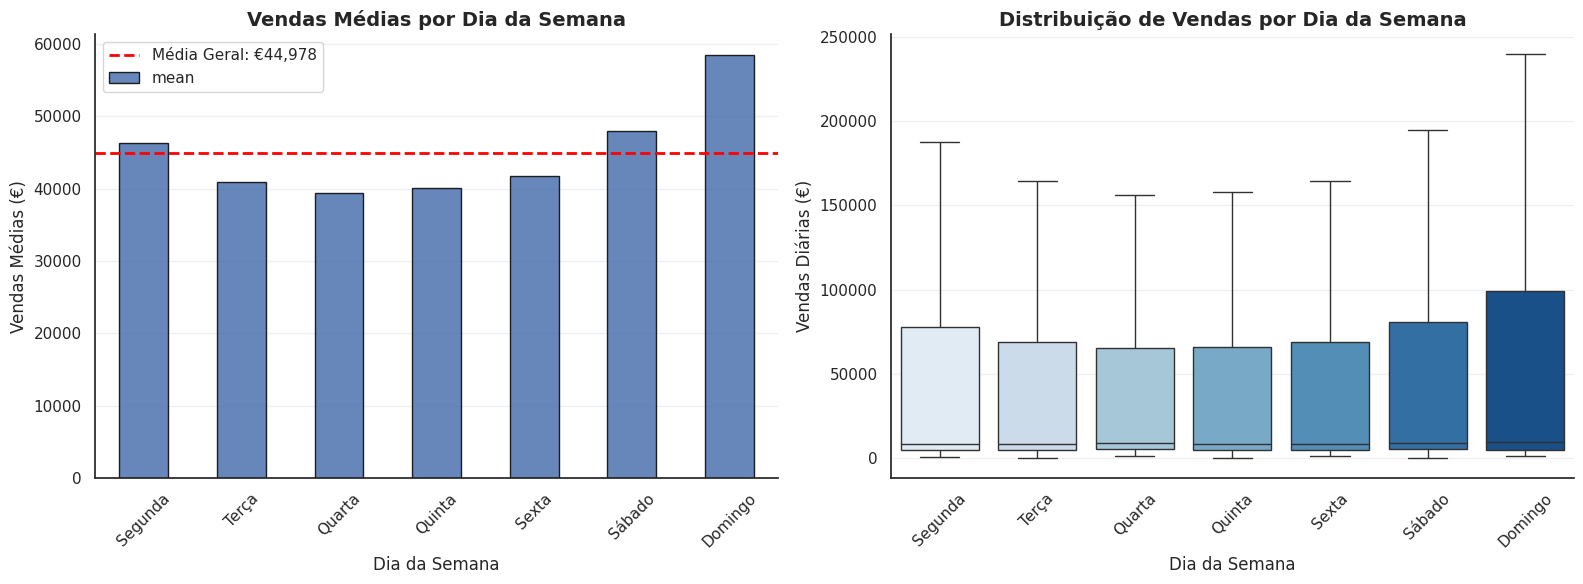


 CONCLUSÃO:
 Padrão semanal FORTE (diferença de 48.1%) → Feature DIA_SEMANA é CRÍTICA
 Considerar criar: IS_FIM_SEMANA, VENDAS_MESMO_DIA_SEMANA_PASSADA


In [0]:

# ANÁLISE 2.2: Vendas por Dia da Semana

# Objetivo: Confirmar se há padrão semanal forte (fins de semana vs. semana)


print("\n ANÁLISE: PADRÃO SEMANAL DE VENDAS\n")

# Preparar dados
df = unificado_pd.copy()

# Mapeamento de números para nomes dos dias
dias_semana = {1: 'Segunda', 2: 'Terça', 3: 'Quarta', 4: 'Quinta', 5: 'Sexta', 6: 'Sábado', 7: 'Domingo'}
df['DIA_SEMANA_NOME'] = df['DIA_SEMANA'].map(dias_semana)

# Estatísticas por dia da semana
vendas_por_dia = df.groupby('DIA_SEMANA_NOME')['TARGET_VENDAS_DIARIAS_EUR'].agg(['mean', 'median', 'std', 'count']).round(2)

# Ordenar por ordem dos dias da semana
orden_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
vendas_por_dia = vendas_por_dia.reindex(orden_dias)

print(" VENDAS POR DIA DA SEMANA:\n")
for dia, row in vendas_por_dia.iterrows():
    print(f"{dia:10s} | Média: €{row['mean']:>10,.2f} | Mediana: €{row['median']:>10,.2f} | Std: €{row['std']:>10,.2f} | n={int(row['count']):>6,}")

# Identificar dia mais forte e mais fraco
dia_mais_forte = vendas_por_dia['mean'].idxmax()
dia_mais_fraco = vendas_por_dia['mean'].idxmin()
diferenca_pct = ((vendas_por_dia.loc[dia_mais_forte, 'mean'] - vendas_por_dia.loc[dia_mais_fraco, 'mean']) / 
                 vendas_por_dia.loc[dia_mais_fraco, 'mean']) * 100

print(f"\n Dia mais forte: {dia_mais_forte} (€{vendas_por_dia.loc[dia_mais_forte, 'mean']:,.2f})")
print(f" Dia mais fraco: {dia_mais_fraco} (€{vendas_por_dia.loc[dia_mais_fraco, 'mean']:,.2f})")
print(f" Diferença: {diferenca_pct:.1f}%")

# Visualização: Barplot + Linha de tendência
sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Barplot com médias
vendas_por_dia['mean'].plot(kind='bar', ax=ax1, color='#4c72b0', edgecolor='black', alpha=0.85)
ax1.axhline(vendas_por_dia['mean'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Média Geral: €{vendas_por_dia["mean"].mean():,.0f}')
ax1.set_title('Vendas Médias por Dia da Semana', fontsize=14, fontweight='bold')
ax1.set_xlabel('Dia da Semana', fontsize=12)
ax1.set_ylabel('Vendas Médias (€)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
sns.despine(ax=ax1)

# Gráfico 2: Boxplot para ver distribuição completa
df_ordenado = df.copy()
df_ordenado['DIA_SEMANA_NOME'] = pd.Categorical(df_ordenado['DIA_SEMANA_NOME'], categories=orden_dias, ordered=True)

sns.boxplot(data=df_ordenado, x='DIA_SEMANA_NOME', y='TARGET_VENDAS_DIARIAS_EUR', ax=ax2, 
            palette='Blues', showfliers=False)
ax2.set_title('Distribuição de Vendas por Dia da Semana', fontsize=14, fontweight='bold')
ax2.set_xlabel('Dia da Semana', fontsize=12)
ax2.set_ylabel('Vendas Diárias (€)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

print("\n CONCLUSÃO:")
if diferenca_pct > 20:
    print(f" Padrão semanal FORTE (diferença de {diferenca_pct:.1f}%) → Feature DIA_SEMANA é CRÍTICA")
    print(" Considerar criar: IS_FIM_SEMANA, VENDAS_MESMO_DIA_SEMANA_PASSADA")
else:
    print(f" Padrão semanal FRACO (diferença de {diferenca_pct:.1f}%) → Verificar outros fatores")

In [0]:
%pip install statsmodels --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


#Autocorrelação (ACF Plot)


 ANÁLISE: AUTOCORRELAÇÃO TEMPORAL DE VENDAS

 Período analisado: 2019-01-01 00:00:00 a 2023-10-30 00:00:00
 Total de dias: 1,748

 LAGS COM AUTOCORRELAÇÃO SIGNIFICATIVA (|r| > 0.1):

  Lag  7: r = +0.868 🔴
  Lag  1: r = +0.853 🔴
  Lag  6: r = +0.798 🔴
  Lag 14: r = +0.795 🔴
  Lag  8: r = +0.767 🔴
  Lag 21: r = +0.765 🔴
  Lag 13: r = +0.746 🔴
  Lag  2: r = +0.722 🔴
  Lag 20: r = +0.719 🔴
  Lag 28: r = +0.719 🔴


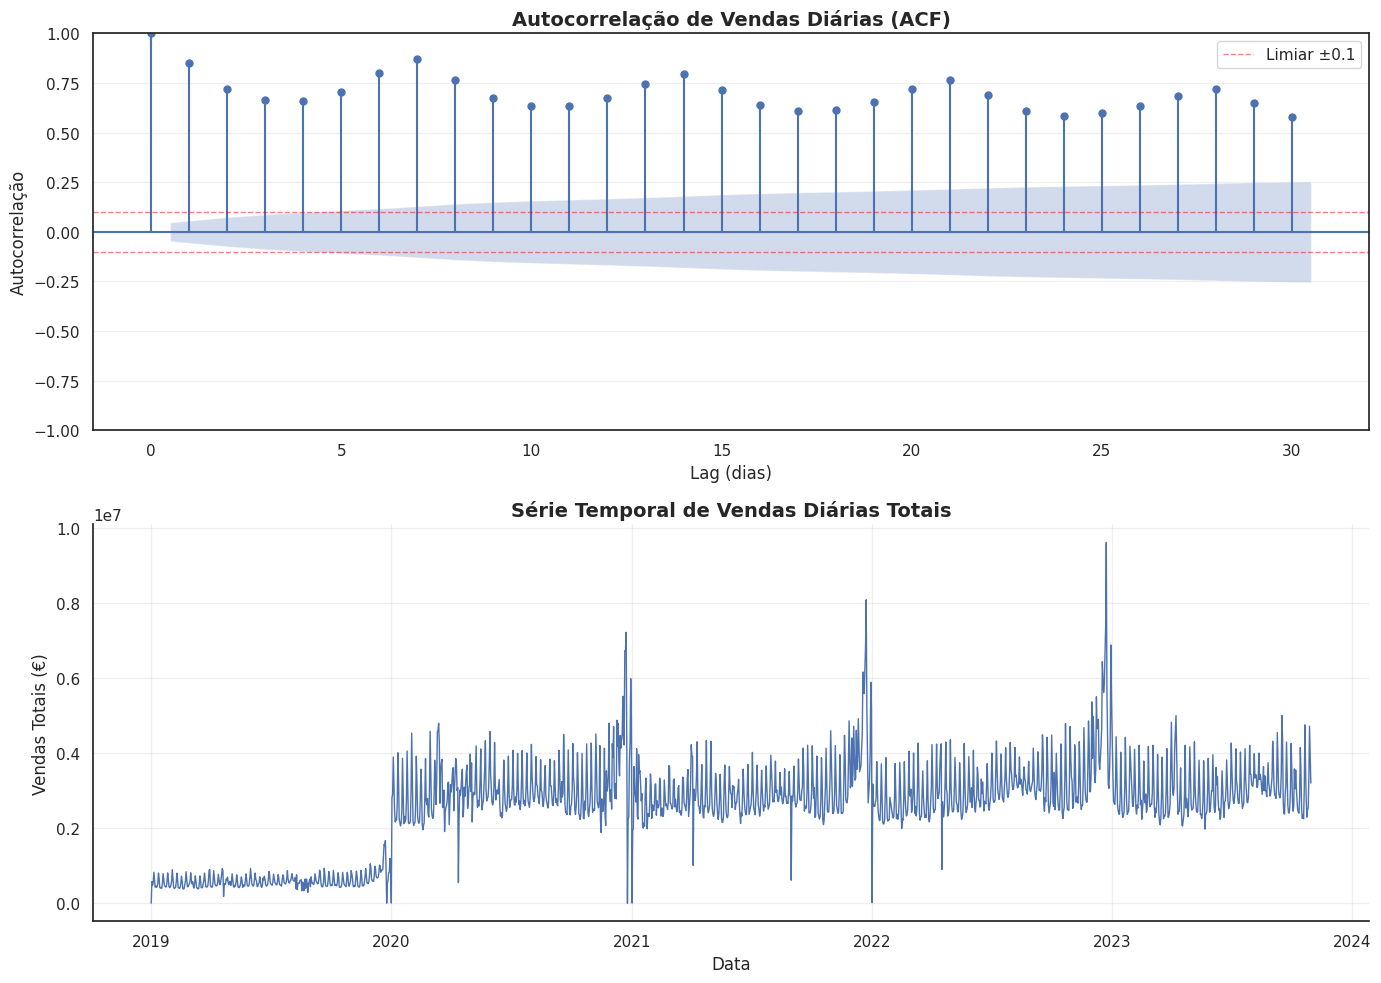


 RECOMENDAÇÕES:
 Autocorrelação FORTE detectada → Features de LAG são ESSENCIAIS

 FEATURES SUGERIDAS:
  • VENDAS_LAG_7 (correlação: +0.868)
  • VENDAS_LAG_1 (correlação: +0.853)
  • VENDAS_LAG_6 (correlação: +0.798)
  • VENDAS_LAG_14 (correlação: +0.795)
  • VENDAS_LAG_8 (correlação: +0.767)
  • VENDAS_MESMO_DIA_SEMANA_PASSADA (padrão semanal detectado!)


In [0]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf


# ANÁLISE 4.1: Autocorrelação de Vendas (ACF Plot)

# Objetivo: Descobrir dependência temporal e identificar melhores lags


print("\n ANÁLISE: AUTOCORRELAÇÃO TEMPORAL DE VENDAS\n")

# Preparar dados - agregar vendas diárias totais (todas as lojas)
df = unificado_pd.copy()
df['DATA'] = pd.to_datetime(df['DATA'])
vendas_diarias = df.groupby('DATA')['TARGET_VENDAS_DIARIAS_EUR'].sum().sort_index()

print(f" Período analisado: {vendas_diarias.index.min()} a {vendas_diarias.index.max()}")
print(f" Total de dias: {len(vendas_diarias):,}")

# Calcular autocorrelação até lag 30
acf_values = acf(vendas_diarias, nlags=30, fft=True)

# Identificar lags com correlação significativa (> 0.1)
lags_significativos = [(i, acf_values[i]) for i in range(1, len(acf_values)) if abs(acf_values[i]) > 0.1]

print(f"\n LAGS COM AUTOCORRELAÇÃO SIGNIFICATIVA (|r| > 0.1):\n")
if lags_significativos:
    for lag, corr in sorted(lags_significativos, key=lambda x: abs(x[1]), reverse=True)[:10]:
        print(f"  Lag {lag:2d}: r = {corr:+.3f} {'🔴' if abs(corr) > 0.3 else '🟡' if abs(corr) > 0.2 else ''}")
else:
    print("   Nenhum lag com correlação significativa detectado")

# Visualização: ACF Plot
sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: ACF completo (30 lags)
plot_acf(vendas_diarias, lags=30, ax=ax1, alpha=0.05)
ax1.set_title('Autocorrelação de Vendas Diárias (ACF)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Lag (dias)', fontsize=12)
ax1.set_ylabel('Autocorrelação', fontsize=12)
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(0.1, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Limiar ±0.1')
ax1.axhline(-0.1, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax1.legend()

# Plot 2: Série temporal das vendas (para contexto)
ax2.plot(vendas_diarias.index, vendas_diarias.values, color='#4c72b0', linewidth=1)
ax2.set_title('Série Temporal de Vendas Diárias Totais', fontsize=14, fontweight='bold')
ax2.set_xlabel('Data', fontsize=12)
ax2.set_ylabel('Vendas Totais (€)', fontsize=12)
ax2.grid(axis='both', alpha=0.3)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

print("\n RECOMENDAÇÕES:")
if any(abs(corr) > 0.2 for _, corr in lags_significativos):
    print(" Autocorrelação FORTE detectada → Features de LAG são ESSENCIAIS")
    print("\n FEATURES SUGERIDAS:")
    for lag, corr in sorted(lags_significativos, key=lambda x: abs(x[1]), reverse=True)[:5]:
        print(f"  • VENDAS_LAG_{lag} (correlação: {corr:+.3f})")
    if any(lag == 7 or lag == 14 for lag, _ in lags_significativos):
        print("  • VENDAS_MESMO_DIA_SEMANA_PASSADA (padrão semanal detectado!)")
else:
    print(" Autocorrelação FRACA → Vendas são mais influenciadas por fatores externos que histórico")
    print(" Focar em features contextuais (eventos, feriados, características regionais)")

#Feature Importance (Random Forest)


 ANÁLISE: IMPORTÂNCIA DE FEATURES (Random Forest)

 Features analisadas: 21
 Registros disponíveis: 98,641

 Registros após limpeza: 98,641
 Registros removidos (NaN): 0

 Treinando Random Forest (rápido)...
 Treino concluído!
  R² (treino): 0.9664
  R² (teste): 0.9482

 TOP 15 FEATURES MAIS IMPORTANTES:

N_COLABORADORES                | 0.8497 | ████████████████████████████████████████████████████████████████████████████████████
DIA_SEMANA                     | 0.0373 | ███
TOTAL_SKUS_LOJA                | 0.0307 | ███
MES                            | 0.0293 | ██
PRODUTIVIDADE/HORA             | 0.0092 | 
FK_SECAO                       | 0.0091 | 
SEMANA_DO_ANO                  | 0.0086 | 
ANO                            | 0.0052 | 
SELF_CHECKOUTS                 | 0.0047 | 
CAIXAS_TRADICIONAIS            | 0.0038 | 
SKUS_-                         | 0.0029 | 
SKUS_+                         | 0.0028 | 
VAR_PREÇO_-                    | 0.0028 | 
VAR_PREÇO_+                    | 0.0025 |

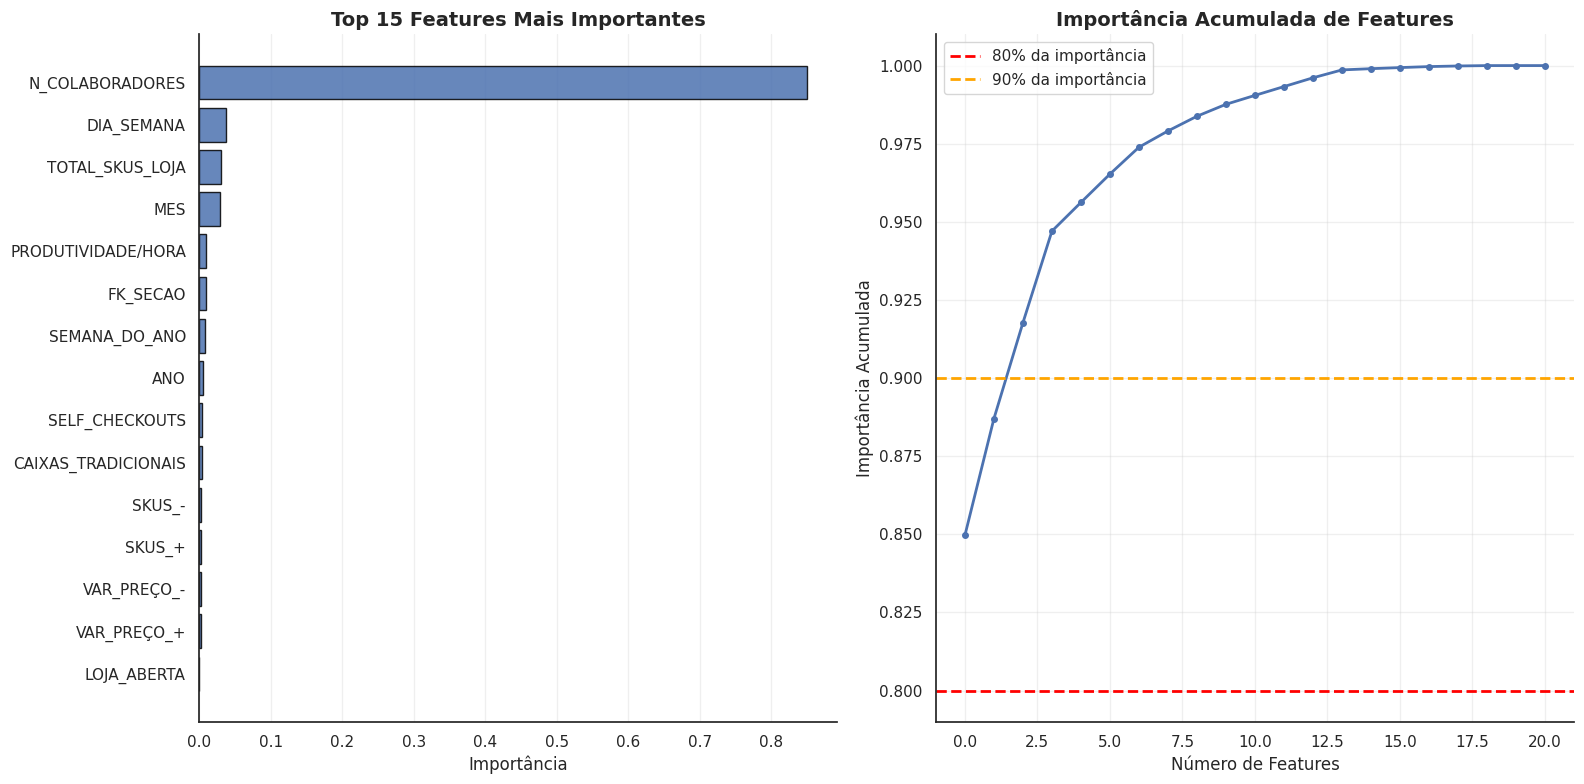


 RECOMENDAÇÕES:

 TOP 0 features capturam 80% da importância

 7 features com importância < 0.001 (candidatas a remoção):
  • LOJA_ABERTA
  • FERIADO_FIXO
  • NATAL
  • ANO_NOVO
  • PASCOA
  • IS_EVENT
  • DIA_DO_TRABALHADOR

 PRÓXIMOS PASSOS:
  1. Criar variantes das top 5 features (lags, interações)
  2. Remover features com importância < 0.001
  3. Re-treinar e comparar performance


In [0]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


# ANÁLISE 7.1: Feature Importance Preliminar (Random Forest)

# Objetivo: Ranking rápido de importância das features atuais


print("\n ANÁLISE: IMPORTÂNCIA DE FEATURES (Random Forest)\n")

# Preparar dados
df = unificado_pd.copy()

# Selecionar apenas features numéricas (excluir target e IDs)
features_excluir = ['TARGET_VENDAS_DIARIAS_EUR', 'DATA', 'FK_LOJA', 'LOJA', 'CIDADE', 'REGIAO', 'ABERTURA', 'FECHO', 'FERIADO']
features_numericas = df.select_dtypes(include=['number']).columns.tolist()
features_numericas = [f for f in features_numericas if f not in features_excluir]

print(f" Features analisadas: {len(features_numericas)}")
print(f" Registros disponíveis: {len(df):,}\n")

# Remover linhas com valores nulos
df_clean = df[features_numericas + ['TARGET_VENDAS_DIARIAS_EUR']].dropna()

X = df_clean[features_numericas]
y = df_clean['TARGET_VENDAS_DIARIAS_EUR']

print(f" Registros após limpeza: {len(df_clean):,}")
print(f" Registros removidos (NaN): {len(df) - len(df_clean):,}\n")

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(" Treinando Random Forest (rápido)...")
# Random Forest rápido para feature importance
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Score
train_score = rf.score(X_train, y_train)
test_score = rf.score(X_test, y_test)

print(f" Treino concluído!")
print(f"  R² (treino): {train_score:.4f}")
print(f"  R² (teste): {test_score:.4f}")

# Extrair importâncias
importances = pd.DataFrame({
    'Feature': features_numericas,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n TOP 15 FEATURES MAIS IMPORTANTES:\n")
for idx, row in importances.head(15).iterrows():
    bar_length = int(row['Importance'] * 100)
    bar = '█' * bar_length
    print(f"{row['Feature']:30s} | {row['Importance']:.4f} | {bar}")

print(f"\n📉 BOTTOM 5 FEATURES (Menor Importância):\n")
for idx, row in importances.tail(5).iterrows():
    print(f"{row['Feature']:30s} | {row['Importance']:.4f}")

# Visualização
sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Top 15 features
top_15 = importances.head(15)
ax1.barh(range(len(top_15)), top_15['Importance'], color='#4c72b0', edgecolor='black', alpha=0.85)
ax1.set_yticks(range(len(top_15)))
ax1.set_yticklabels(top_15['Feature'])
ax1.invert_yaxis()
ax1.set_title('Top 15 Features Mais Importantes', fontsize=14, fontweight='bold')
ax1.set_xlabel('Importância', fontsize=12)
ax1.grid(axis='x', alpha=0.3)
sns.despine(ax=ax1)

# Importância acumulada
importances_sorted = importances.sort_values('Importance', ascending=False)
importances_sorted['Cumulative'] = importances_sorted['Importance'].cumsum()

ax2.plot(range(len(importances_sorted)), importances_sorted['Cumulative'], 
         color='#4c72b0', linewidth=2, marker='o', markersize=4)
ax2.axhline(0.8, color='red', linestyle='--', linewidth=2, label='80% da importância')
ax2.axhline(0.9, color='orange', linestyle='--', linewidth=2, label='90% da importância')
ax2.set_title('Importância Acumulada de Features', fontsize=14, fontweight='bold')
ax2.set_xlabel('Número de Features', fontsize=12)
ax2.set_ylabel('Importância Acumulada', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

# Identificar features para remover
features_inuteis = importances[importances['Importance'] < 0.001]
num_features_80pct = (importances_sorted['Cumulative'] <= 0.8).sum()

print("\n RECOMENDAÇÕES:\n")
print(f" TOP {num_features_80pct} features capturam 80% da importância")
if len(features_inuteis) > 0:
    print(f"\n {len(features_inuteis)} features com importância < 0.001 (candidatas a remoção):")
    for feat in features_inuteis['Feature'].tolist():
        print(f"  • {feat}")
else:
    print(" Todas as features contribuem significativamente")

print("\n PRÓXIMOS PASSOS:")
print("  1. Criar variantes das top 5 features (lags, interações)")
print("  2. Remover features com importância < 0.001")
print("  3. Re-treinar e comparar performance")

#Proximidade a Feriados



 ANÁLISE: PROXIMIDADE A FERIADOS

 Dias identificados em janela de feriado: 56,064
 Dias de feriado: 3,168

 VENDAS MÉDIAS POR DISTÂNCIA AO FERIADO:

7 dias ANTES        : €   44,341.02
6 dias ANTES        : €   44,280.40
5 dias ANTES        : €   45,376.16
4 dias ANTES        : €   47,776.00
3 dias ANTES        : €   47,792.33
2 dias ANTES        : €   47,632.89
1 dias ANTES        : €   46,405.60
DIA DO FERIADO      : €   44,514.55
1 dias DEPOIS       : €   43,970.18
2 dias DEPOIS       : €   43,152.27
3 dias DEPOIS       : €   45,606.38
4 dias DEPOIS       : €   46,264.29
5 dias DEPOIS       : €   44,129.51
6 dias DEPOIS       : €   43,575.32
7 dias DEPOIS       : €   43,354.78

 Pico de vendas: 3 dias antes (€47,792.33)
 Vendas no feriado: €44,514.55
 Vendas em dias normais: €44,432.11

 Diferença vs. dias normais:
   Pico: +7.6%
   Feriado: +0.2%


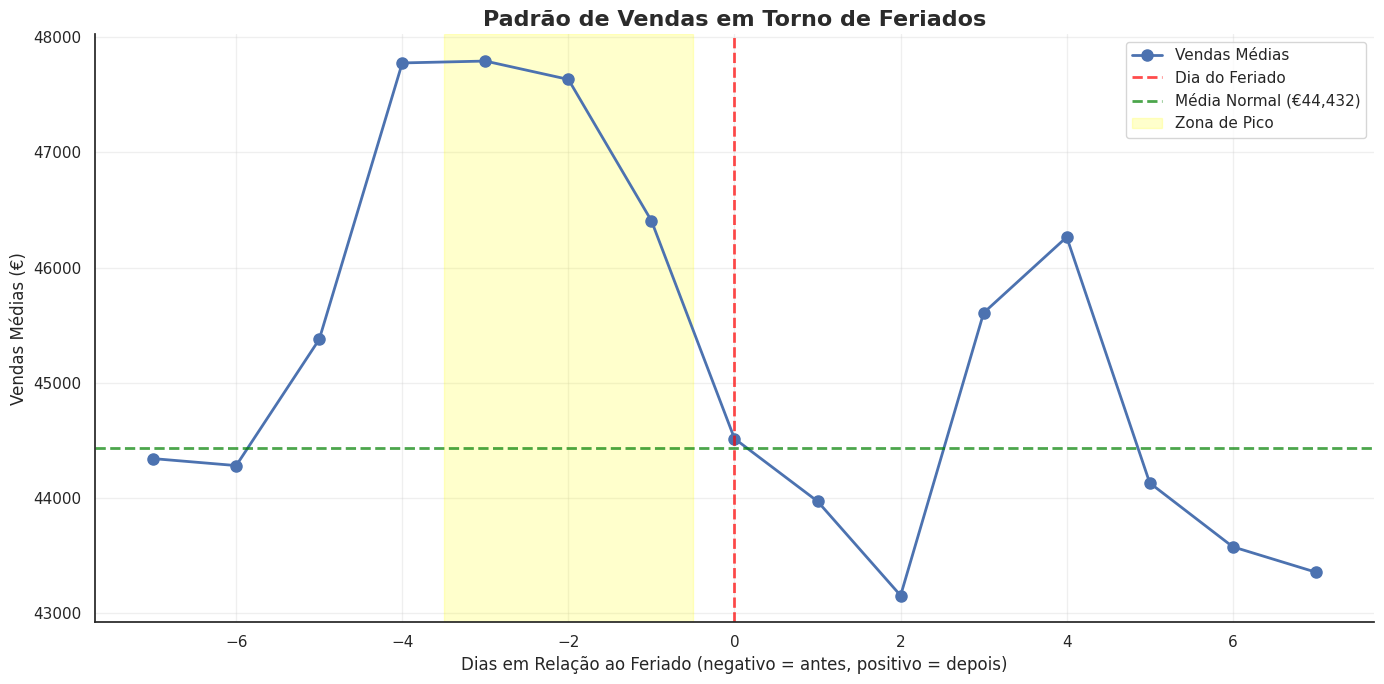


 CONCLUSÃO:
 Padrão fraco ou inexistente → Feriados não criam antecipação de compras


In [0]:

# ANÁLISE 1.3: Impacto da Proximidade a Feriados

# Objetivo: Descobrir se vendas aumentam ANTES de feriados (compras antecipadas)


print("\n ANÁLISE: PROXIMIDADE A FERIADOS\n")

# Preparar dados
df = unificado_pd.copy()
df['DATA'] = pd.to_datetime(df['DATA'])
df = df.sort_values('DATA').reset_index(drop=True)

# Identificar dias com qualquer feriado
feriados_cols = ['ANO_NOVO', 'NATAL', 'PASCOA', 'DIA_DO_TRABALHADOR', 'FERIADO_FIXO']
df['TEM_FERIADO'] = df[feriados_cols].max(axis=1)

# Criar variável DIAS_ATE_FERIADO (janela de -7 a +7 dias)
df['DIAS_ATE_FERIADO'] = None

for idx in df[df['TEM_FERIADO'] == 1].index:
    data_feriado = df.loc[idx, 'DATA']
    # Marcar dias ao redor do feriado
    for delta in range(-7, 8):
        data_alvo = data_feriado + pd.Timedelta(days=delta)
        mask = df['DATA'] == data_alvo
        if mask.any():
            df.loc[mask, 'DIAS_ATE_FERIADO'] = delta

print(f" Dias identificados em janela de feriado: {df['DIAS_ATE_FERIADO'].notna().sum():,}")
print(f" Dias de feriado: {(df['DIAS_ATE_FERIADO'] == 0).sum():,}")

# Filtrar apenas dias na janela de feriado
df_janela = df[df['DIAS_ATE_FERIADO'].notna()].copy()

# Calcular vendas médias por distância ao feriado
vendas_por_distancia = df_janela.groupby('DIAS_ATE_FERIADO')['TARGET_VENDAS_DIARIAS_EUR'].mean().sort_index()

print("\n VENDAS MÉDIAS POR DISTÂNCIA AO FERIADO:\n")
for dias, vendas in vendas_por_distancia.items():
    if dias < 0:
        label = f"{abs(int(dias))} dias ANTES"
    elif dias > 0:
        label = f"{int(dias)} dias DEPOIS"
    else:
        label = "DIA DO FERIADO"
    print(f"{label:20s}: €{vendas:>12,.2f}")

# Identificar pico de vendas
pico_dia = vendas_por_distancia.idxmax()
pico_vendas = vendas_por_distancia.max()
vendas_feriado = vendas_por_distancia.get(0, 0)
vendas_normais = df[df['DIAS_ATE_FERIADO'].isna()]['TARGET_VENDAS_DIARIAS_EUR'].mean()

print(f"\n Pico de vendas: {abs(int(pico_dia))} dias {'antes' if pico_dia < 0 else 'depois'} (€{pico_vendas:,.2f})")
print(f" Vendas no feriado: €{vendas_feriado:,.2f}")
print(f" Vendas em dias normais: €{vendas_normais:,.2f}")

diferenca_pico = ((pico_vendas - vendas_normais) / vendas_normais) * 100
diferenca_feriado = ((vendas_feriado - vendas_normais) / vendas_normais) * 100

print(f"\n Diferença vs. dias normais:")
print(f"   Pico: {diferenca_pico:+.1f}%")
print(f"   Feriado: {diferenca_feriado:+.1f}%")

# Visualização
sns.set_style("white")
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(vendas_por_distancia.index, vendas_por_distancia.values, 
        marker='o', linewidth=2, markersize=8, color='#4c72b0', label='Vendas Médias')
ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Dia do Feriado')
ax.axhline(vendas_normais, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Média Normal (€{vendas_normais:,.0f})')

# Destacar zona de pico
if pico_dia < 0:
    ax.axvspan(pico_dia - 0.5, -0.5, alpha=0.2, color='yellow', label='Zona de Pico')

ax.set_title('Padrão de Vendas em Torno de Feriados', fontsize=16, fontweight='bold', color='#2b2b2b')
ax.set_xlabel('Dias em Relação ao Feriado (negativo = antes, positivo = depois)', fontsize=12)
ax.set_ylabel('Vendas Médias (€)', fontsize=12)
ax.legend(loc='best')
ax.grid(alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

print("\n CONCLUSÃO:")
if abs(diferenca_pico) > 10:
    print(f" PADRÃO FORTE: Vendas aumentam {abs(diferenca_pico):.1f}% nos dias próximos ao feriado")
    print(" FEATURES RECOMENDADAS:")
    print("  • DIAS_ATE_PROXIMO_FERIADO (conta regressiva)")
    print("  • DIAS_DESDE_ULTIMO_FERIADO (recuperação)")
    print("  • IS_VESPERA_FERIADO (dia anterior)")
else:
    print(" Padrão fraco ou inexistente → Feriados não criam antecipação de compras")

#Vendas por Semana do Mês


 ANÁLISE: CICLO MENSAL DE VENDAS (Padrão de Salários)

 VENDAS POR SEMANA DO MÊS:

Semana 1 | Média: € 44,860.10 | Mediana: €  8,155.85 | Std: € 60,561.10 | n= 22,760
Semana 2 | Média: € 44,791.87 | Mediana: €  9,091.96 | Std: € 60,083.79 | n= 22,959
Semana 3 | Média: € 44,291.72 | Mediana: €  8,058.36 | Std: € 61,638.66 | n= 23,032
Semana 4 | Média: € 44,722.75 | Mediana: €  8,020.61 | Std: € 62,519.56 | n= 22,827
Semana 5 | Média: € 48,991.98 | Mediana: €  8,409.44 | Std: € 68,140.39 | n=  7,063

 PADRÃO DETECTADO:
   Semana 1 (início do mês): €44,860.10
   Semana 4 (fim do mês): €44,722.75
   Diferença: +0.3%


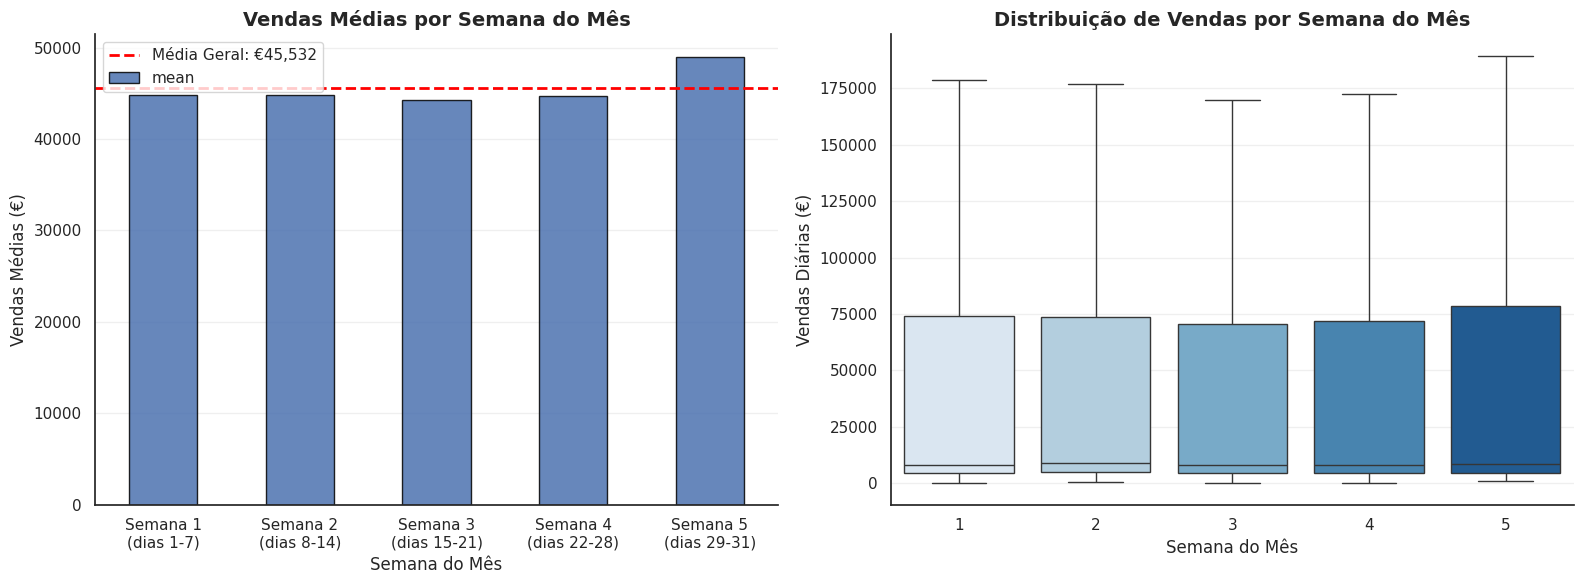


 CONCLUSÃO:
 Ciclo mensal FRACO (0.3% de diferença)
   → Salários não parecem influenciar padrão de compras de forma significativa


In [0]:

# ANÁLISE 2.3: Vendas por Semana do Mês

# Objetivo: Testar hipótese de ciclo mensal (salários pagos no início)


print("\n ANÁLISE: CICLO MENSAL DE VENDAS (Padrão de Salários)\n")

# Preparar dados
df = unificado_pd.copy()
df['DATA'] = pd.to_datetime(df['DATA'])

# Calcular semana do mês (1-5)
df['DIA_DO_MES'] = df['DATA'].dt.day
df['SEMANA_DO_MES'] = ((df['DIA_DO_MES'] - 1) // 7) + 1
df['SEMANA_DO_MES'] = df['SEMANA_DO_MES'].clip(upper=5)  # Limitar a 5 semanas

# Estatísticas por semana do mês
vendas_por_semana = df.groupby('SEMANA_DO_MES')['TARGET_VENDAS_DIARIAS_EUR'].agg(['mean', 'median', 'std', 'count']).round(2)

print(" VENDAS POR SEMANA DO MÊS:\n")
for semana, row in vendas_por_semana.iterrows():
    print(f"Semana {int(semana)} | Média: €{row['mean']:>10,.2f} | Mediana: €{row['median']:>10,.2f} | Std: €{row['std']:>10,.2f} | n={int(row['count']):>7,}")

# Calcular diferença entre primeira e última semana
semana_1_media = vendas_por_semana.loc[1, 'mean']
semana_4_media = vendas_por_semana.loc[4, 'mean']
diferenca_pct = ((semana_1_media - semana_4_media) / semana_4_media) * 100

print(f"\n PADRÃO DETECTADO:")
print(f"   Semana 1 (início do mês): €{semana_1_media:,.2f}")
print(f"   Semana 4 (fim do mês): €{semana_4_media:,.2f}")
print(f"   Diferença: {diferenca_pct:+.1f}%")

# Visualização
sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Barplot de médias
vendas_por_semana['mean'].plot(kind='bar', ax=ax1, color='#4c72b0', edgecolor='black', alpha=0.85)
ax1.axhline(vendas_por_semana['mean'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Média Geral: €{vendas_por_semana["mean"].mean():,.0f}')
ax1.set_title('Vendas Médias por Semana do Mês', fontsize=14, fontweight='bold')
ax1.set_xlabel('Semana do Mês', fontsize=12)
ax1.set_ylabel('Vendas Médias (€)', fontsize=12)
ax1.set_xticklabels(['Semana 1\n(dias 1-7)', 'Semana 2\n(dias 8-14)', 
                     'Semana 3\n(dias 15-21)', 'Semana 4\n(dias 22-28)', 
                     'Semana 5\n(dias 29-31)'], rotation=0)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
sns.despine(ax=ax1)

# Gráfico 2: Boxplot para distribuição
sns.boxplot(data=df, x='SEMANA_DO_MES', y='TARGET_VENDAS_DIARIAS_EUR', ax=ax2,
            palette='Blues', showfliers=False)
ax2.set_title('Distribuição de Vendas por Semana do Mês', fontsize=14, fontweight='bold')
ax2.set_xlabel('Semana do Mês', fontsize=12)
ax2.set_ylabel('Vendas Diárias (€)', fontsize=12)
ax2.set_xticklabels(['1', '2', '3', '4', '5'])
ax2.grid(axis='y', alpha=0.3)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

print("\n CONCLUSÃO:")
if abs(diferenca_pct) > 10:
    print(f" CICLO MENSAL FORTE detectado ({abs(diferenca_pct):.1f}% de diferença)")
    print(" FEATURE RECOMENDADA: SEMANA_DO_MES (captura padrão de salários)")
    print(" Hipótese: Consumidores gastam mais no início do mês (após receber salário)")
else:
    print(f" Ciclo mensal FRACO ({abs(diferenca_pct):.1f}% de diferença)")
    print("   → Salários não parecem influenciar padrão de compras de forma significativa")

#Interação Evento × Fim de Semana


 ANÁLISE: INTERAÇÃO EVENTO × FIM DE SEMANA

 VENDAS MÉDIAS POR COMBINAÇÃO:

Fim de Semana + Evento    | Média: €134,640.68 | Mediana: €142,340.77 | n=     12
Semana com Evento         | Média: € 89,816.94 | Mediana: € 94,752.44 | n=     43
Fim de Semana Normal      | Média: € 53,158.68 | Mediana: €  8,811.20 | n= 28,205
Semana Normal             | Média: € 41,653.53 | Mediana: €  8,164.06 | n= 70,381

 ANÁLISE DE INTERAÇÃO:

Efeito de Fim de Semana isolado: €+11,505.15
Efeito de Evento isolado: €+48,163.41

Efeito esperado (aditivo): €101,322.09
Efeito real observado: €134,640.68

⚡ INTERAÇÃO: €+33,318.59 (+32.9%)

 SINERGIA POSITIVA: Evento + Fim de Semana > soma dos efeitos individuais


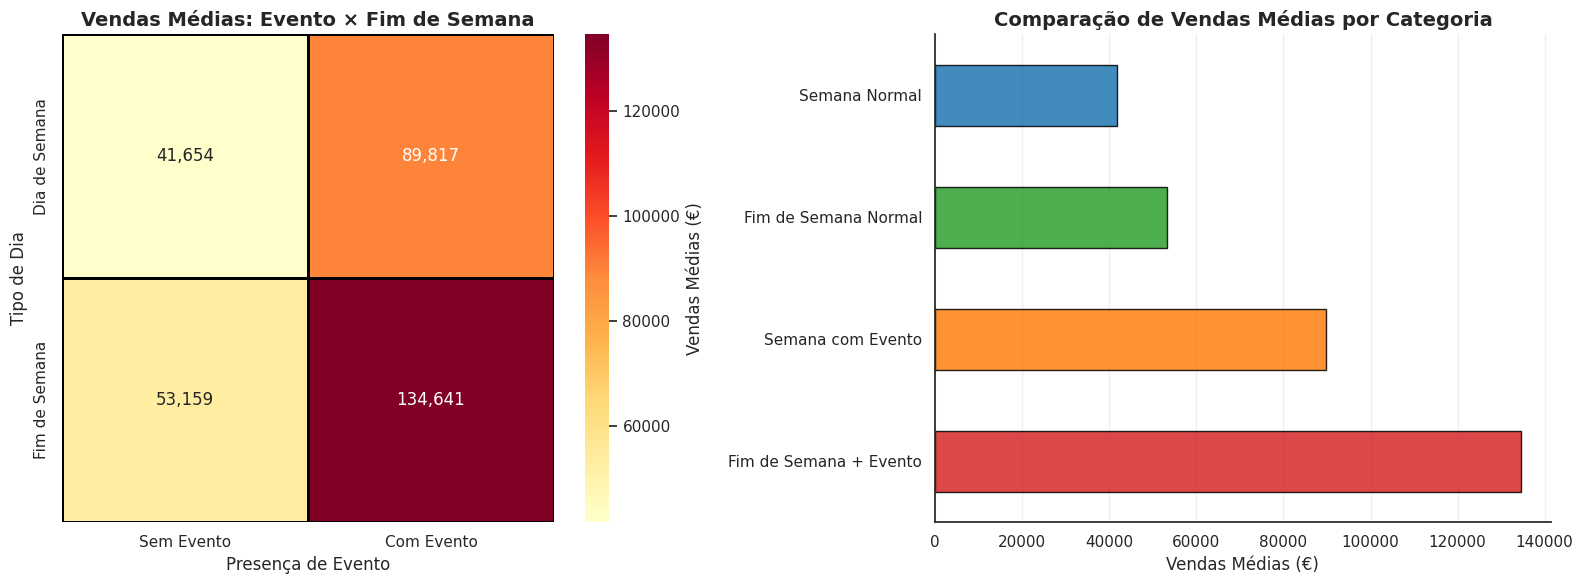


 RECOMENDAÇÃO:
 Criar feature de INTERAÇÃO: IS_FIM_SEMANA × IS_EVENT
   → O modelo precisa capturar este efeito não-linear


In [0]:

# ANÁLISE 3.1: Interação Evento × Fim de Semana

# Objetivo: Testar se eventos têm efeito diferente em fins de semana vs. semana


print("\n ANÁLISE: INTERAÇÃO EVENTO × FIM DE SEMANA\n")

# Preparar dados
df = unificado_pd.copy()

# Criar flag de fim de semana (Sábado=6, Domingo=7)
df['IS_FIM_SEMANA'] = df['DIA_SEMANA'].isin([6, 7]).astype(int)

# Criar combinação das duas variáveis
df['CATEGORIA'] = 'Semana Normal'
df.loc[(df['IS_FIM_SEMANA'] == 1) & (df['IS_EVENT'] == 0), 'CATEGORIA'] = 'Fim de Semana Normal'
df.loc[(df['IS_FIM_SEMANA'] == 0) & (df['IS_EVENT'] == 1), 'CATEGORIA'] = 'Semana com Evento'
df.loc[(df['IS_FIM_SEMANA'] == 1) & (df['IS_EVENT'] == 1), 'CATEGORIA'] = 'Fim de Semana + Evento'

# Calcular médias por categoria
vendas_por_categoria = df.groupby('CATEGORIA')['TARGET_VENDAS_DIARIAS_EUR'].agg(['mean', 'median', 'count']).round(2)

# Ordenar por média
vendas_por_categoria = vendas_por_categoria.sort_values('mean', ascending=False)

print(" VENDAS MÉDIAS POR COMBINAÇÃO:\n")
for categoria, row in vendas_por_categoria.iterrows():
    print(f"{categoria:25s} | Média: €{row['mean']:>10,.2f} | Mediana: €{row['median']:>10,.2f} | n={int(row['count']):>7,}")

# Calcular efeito de interação
semana_normal = vendas_por_categoria.loc['Semana Normal', 'mean']
fim_semana_normal = vendas_por_categoria.loc['Fim de Semana Normal', 'mean']
semana_evento = vendas_por_categoria.loc['Semana com Evento', 'mean']
fim_semana_evento = vendas_por_categoria.loc['Fim de Semana + Evento', 'mean']

# Efeito aditivo esperado (sem interação)
efeito_fim_semana = fim_semana_normal - semana_normal
efeito_evento = semana_evento - semana_normal
efeito_esperado_aditivo = semana_normal + efeito_fim_semana + efeito_evento

# Efeito real observado
efeito_real = fim_semana_evento

# Interação = diferença entre real e esperado
interacao = efeito_real - efeito_esperado_aditivo
interacao_pct = (interacao / efeito_esperado_aditivo) * 100

print("\n ANÁLISE DE INTERAÇÃO:\n")
print(f"Efeito de Fim de Semana isolado: €{efeito_fim_semana:+,.2f}")
print(f"Efeito de Evento isolado: €{efeito_evento:+,.2f}")
print(f"\nEfeito esperado (aditivo): €{efeito_esperado_aditivo:,.2f}")
print(f"Efeito real observado: €{efeito_real:,.2f}")
print(f"\n⚡ INTERAÇÃO: €{interacao:+,.2f} ({interacao_pct:+.1f}%)")

if abs(interacao_pct) > 10:
    if interacao_pct > 0:
        print("\n SINERGIA POSITIVA: Evento + Fim de Semana > soma dos efeitos individuais")
    else:
        print("\n INTERFERÊNCIA: Evento + Fim de Semana < soma dos efeitos individuais")
else:
    print("\n Efeitos são aproximadamente ADITIVOS (sem interação forte)")

# Visualização: Heatmap 2x2
sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Criar matriz para heatmap
matriz_vendas = pd.DataFrame({
    'Sem Evento': [semana_normal, fim_semana_normal],
    'Com Evento': [semana_evento, fim_semana_evento]
}, index=['Dia de Semana', 'Fim de Semana'])

# Heatmap
sns.heatmap(matriz_vendas, annot=True, fmt=',.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Vendas Médias (€)'}, ax=ax1, linewidths=1, linecolor='black')
ax1.set_title('Vendas Médias: Evento × Fim de Semana', fontsize=14, fontweight='bold')
ax1.set_xlabel('Presença de Evento', fontsize=12)
ax1.set_ylabel('Tipo de Dia', fontsize=12)

# Barplot comparativo
vendas_por_categoria['mean'].plot(kind='barh', ax=ax2, color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'],
                                   edgecolor='black', alpha=0.85)
ax2.set_title('Comparação de Vendas Médias por Categoria', fontsize=14, fontweight='bold')
ax2.set_xlabel('Vendas Médias (€)', fontsize=12)
ax2.set_ylabel('')
ax2.grid(axis='x', alpha=0.3)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

print("\n RECOMENDAÇÃO:")
if abs(interacao_pct) > 10:
    print(" Criar feature de INTERAÇÃO: IS_FIM_SEMANA × IS_EVENT")
    print("   → O modelo precisa capturar este efeito não-linear")
else:
    print(" Manter features separadas (IS_FIM_SEMANA e IS_EVENT)")
    print("   → Interação não justifica feature adicional")

#Heterogeneidade entre Lojas


 ANÁLISE: HETEROGENEIDADE ENTRE LOJAS

 ANÁLISE DE 70 LOJAS:


 TOP 5 LOJAS MAIS ESTÁVEIS (CV mais baixo):

S - Nuno Alvares Pereira       | Média: €  5,698.72 | CV: 0.139 | Muito Estável
S - Campo de Ourique           | Média: €  4,133.14 | CV: 0.144 | Muito Estável
S - Av. D. João II             | Média: €  4,463.59 | CV: 0.145 | Muito Estável
S - Gil Vicente                | Média: €  5,237.35 | CV: 0.147 | Muito Estável
S - Penha de Franca            | Média: €  5,601.02 | CV: 0.159 | Muito Estável

 TOP 5 LOJAS MAIS VOLÁTEIS (CV mais alto):

Guimarães                      | Média: € 66,097.90 | CV: 0.429 | Muito Estável
Vila do Conde                  | Média: € 95,254.94 | CV: 0.353 | Muito Estável
Maia                           | Média: €110,872.84 | CV: 0.351 | Muito Estável
Torres Vedras                  | Média: € 61,002.61 | CV: 0.346 | Muito Estável
Matosinhos                     | Média: €107,203.53 | CV: 0.345 | Muito Estável

 DISTRIBUIÇÃO DE VOLATILIDADE:

Muito Estável

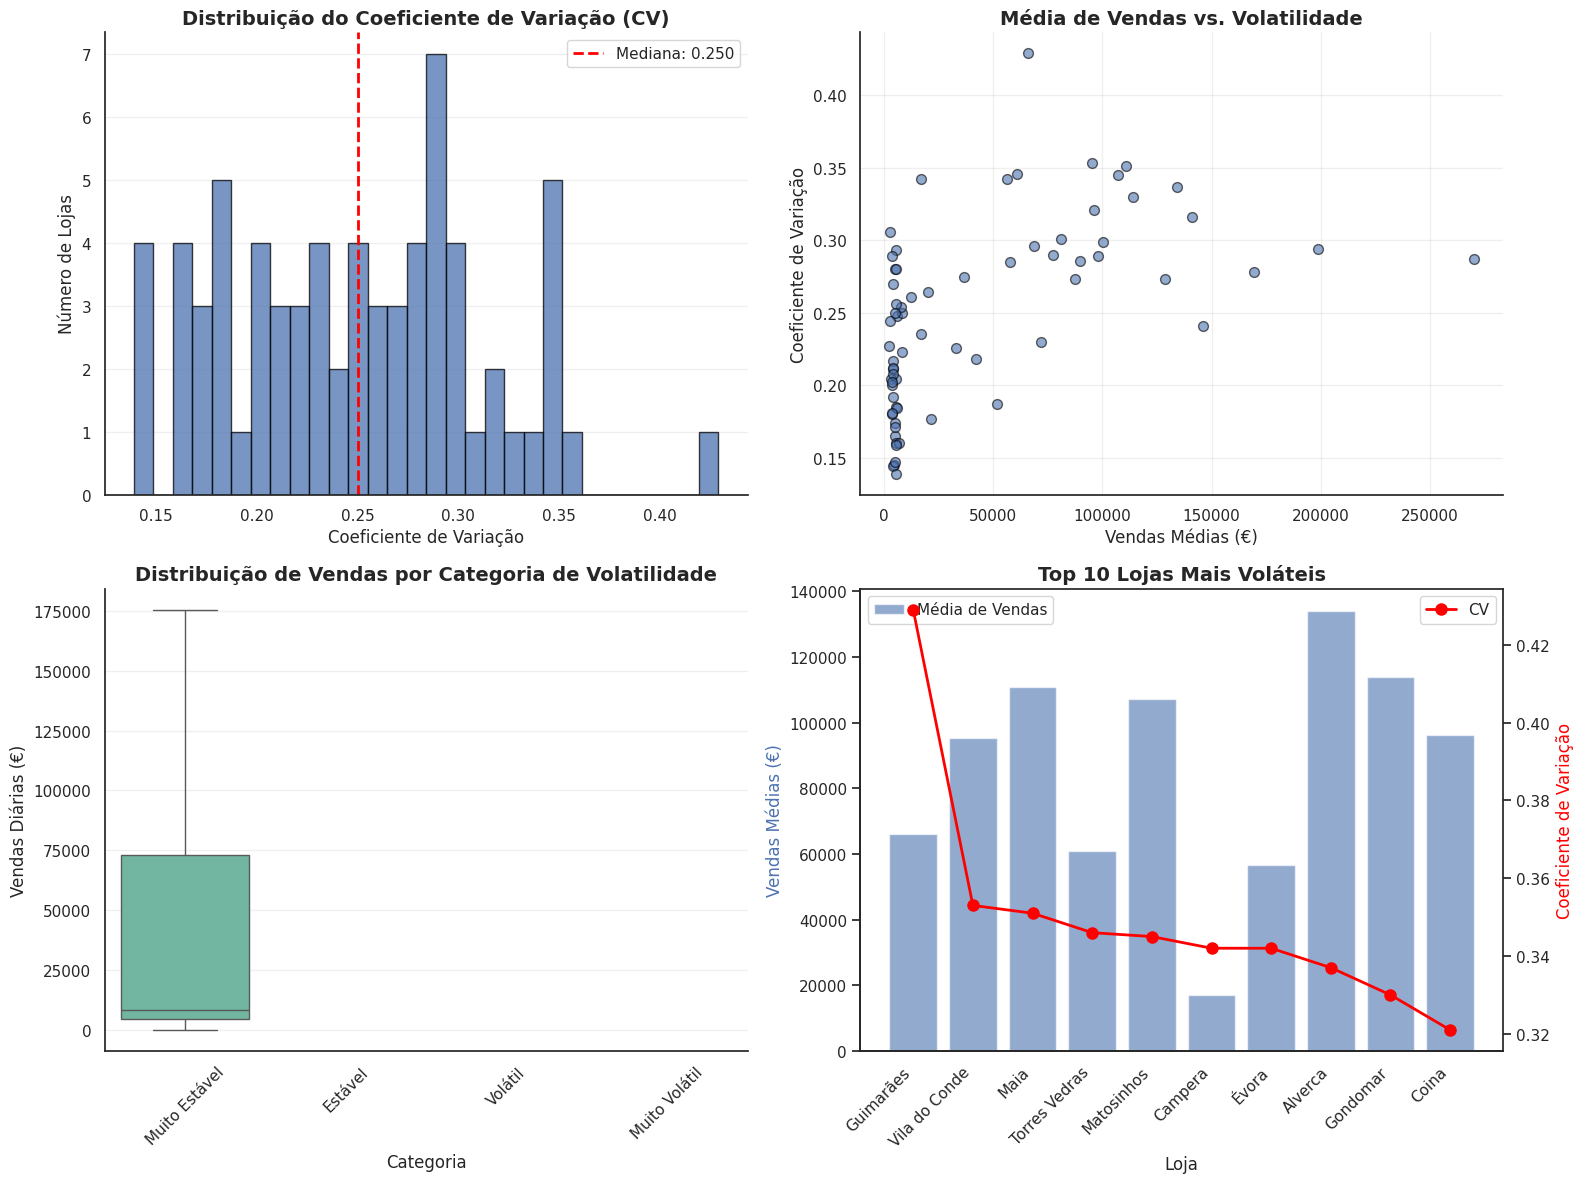


 INSIGHTS:
 Volatilidade moderada → Histórico recente é bom preditor
   → Features de LAG são suficientes para maioria das lojas


In [0]:

# ANÁLISE 5.1: Coeficiente de Variação por Loja

# Objetivo: Identificar lojas previsíveis vs. voláteis


print("\n ANÁLISE: HETEROGENEIDADE ENTRE LOJAS\n")

# Preparar dados
df = unificado_pd.copy()

# Calcular estatísticas por loja
stats_loja = df.groupby('LOJA')['TARGET_VENDAS_DIARIAS_EUR'].agg([
    ('Media', 'mean'),
    ('Mediana', 'median'),
    ('Desvio_Padrao', 'std'),
    ('Minimo', 'min'),
    ('Maximo', 'max'),
    ('Dias', 'count')
]).round(2)

# Calcular Coeficiente de Variação (CV = std / mean)
stats_loja['CV'] = (stats_loja['Desvio_Padrao'] / stats_loja['Media']).round(3)

# Classificar lojas por volatilidade
stats_loja['Volatilidade'] = pd.cut(stats_loja['CV'], 
                                      bins=[0, 0.5, 1.0, 2.0, float('inf')],
                                      labels=['Muito Estável', 'Estável', 'Volátil', 'Muito Volátil'])

print(f" ANÁLISE DE {len(stats_loja)} LOJAS:\n")
print("\n TOP 5 LOJAS MAIS ESTÁVEIS (CV mais baixo):\n")
for loja, row in stats_loja.nsmallest(5, 'CV').iterrows():
    print(f"{loja:30s} | Média: €{row['Media']:>10,.2f} | CV: {row['CV']:.3f} | {row['Volatilidade']}")

print("\n TOP 5 LOJAS MAIS VOLÁTEIS (CV mais alto):\n")
for loja, row in stats_loja.nlargest(5, 'CV').iterrows():
    print(f"{loja:30s} | Média: €{row['Media']:>10,.2f} | CV: {row['CV']:.3f} | {row['Volatilidade']}")

# Distribuição de volatilidade
print("\n DISTRIBUIÇÃO DE VOLATILIDADE:\n")
volatilidade_dist = stats_loja['Volatilidade'].value_counts()
for categoria, count in volatilidade_dist.items():
    pct = (count / len(stats_loja)) * 100
    print(f"{categoria:20s}: {count:3d} lojas ({pct:5.1f}%)")

# Estatísticas gerais
print(f"\n ESTATÍSTICAS GERAIS DO CV:\n")
print(f"Média: {stats_loja['CV'].mean():.3f}")
print(f"Mediana: {stats_loja['CV'].median():.3f}")
print(f"Mínimo: {stats_loja['CV'].min():.3f}")
print(f"Máximo: {stats_loja['CV'].max():.3f}")

# Visualização
sns.set_style("white")
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histograma de CV
ax1.hist(stats_loja['CV'], bins=30, edgecolor='black', alpha=0.75, color='#4c72b0')
ax1.axvline(stats_loja['CV'].median(), color='red', linestyle='--', linewidth=2,
            label=f'Mediana: {stats_loja["CV"].median():.3f}')
ax1.set_title('Distribuição do Coeficiente de Variação (CV)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Coeficiente de Variação', fontsize=12)
ax1.set_ylabel('Número de Lojas', fontsize=12)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
sns.despine(ax=ax1)

# 2. Scatter: Média vs. CV
ax2.scatter(stats_loja['Media'], stats_loja['CV'], alpha=0.6, s=50, color='#4c72b0', edgecolor='black')
ax2.set_title('Média de Vendas vs. Volatilidade', fontsize=14, fontweight='bold')
ax2.set_xlabel('Vendas Médias (€)', fontsize=12)
ax2.set_ylabel('Coeficiente de Variação', fontsize=12)
ax2.grid(alpha=0.3)
sns.despine(ax=ax2)

# 3. Boxplot por categoria de volatilidade
df_merged = df.merge(stats_loja[['Volatilidade']], left_on='LOJA', right_index=True)
sns.boxplot(data=df_merged, x='Volatilidade', y='TARGET_VENDAS_DIARIAS_EUR', ax=ax3,
            palette='Set2', showfliers=False, order=['Muito Estável', 'Estável', 'Volátil', 'Muito Volátil'])
ax3.set_title('Distribuição de Vendas por Categoria de Volatilidade', fontsize=14, fontweight='bold')
ax3.set_xlabel('Categoria', fontsize=12)
ax3.set_ylabel('Vendas Diárias (€)', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)
sns.despine(ax=ax3)

# 4. Top 10 lojas por CV
top_10_cv = stats_loja.nlargest(10, 'CV')[['Media', 'CV']]
ax4_twin = ax4.twinx()
ax4.bar(range(len(top_10_cv)), top_10_cv['Media'], alpha=0.6, color='#4c72b0', label='Média de Vendas')
ax4_twin.plot(range(len(top_10_cv)), top_10_cv['CV'], color='red', marker='o', linewidth=2, markersize=8, label='CV')
ax4.set_title('Top 10 Lojas Mais Voláteis', fontsize=14, fontweight='bold')
ax4.set_xlabel('Loja', fontsize=12)
ax4.set_ylabel('Vendas Médias (€)', fontsize=12, color='#4c72b0')
ax4_twin.set_ylabel('Coeficiente de Variação', fontsize=12, color='red')
ax4.set_xticks(range(len(top_10_cv)))
ax4.set_xticklabels(top_10_cv.index, rotation=45, ha='right')
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')
sns.despine(ax=ax4)

plt.tight_layout()
plt.show()

print("\n INSIGHTS:")
if stats_loja['CV'].median() > 1.0:
    print(" Alta volatilidade geral → Modelo precisa de MUITAS features contextuais")
    print("   → Eventos, feriados, sazonalidade são críticos")
else:
    print(" Volatilidade moderada → Histórico recente é bom preditor")
    print("   → Features de LAG são suficientes para maioria das lojas")

if len(stats_loja[stats_loja['CV'] > 2.0]) > 0:
    print(f"\n {len(stats_loja[stats_loja['CV'] > 2.0])} lojas MUITO voláteis (CV > 2.0)")
    print("   → Considerar modelos específicos ou exclusão dessas lojas")

#Impacto de Campanhas Promocionais


 ANÁLISE: IMPACTO DE CAMPANHAS PROMOCIONAIS NO DESEMPENHO DAS LOJAS

 Dataset: 98,641 registros | 70 lojas | 9 regiões


 PARTE 1: IMPACTO GERAL DE EVENTOS
--------------------------------------------------------------------------------
 Vendas médias SEM evento: €44,945.10
 Vendas médias COM evento: €99,596.67
 Aumento absoluto: €54,651.56
 Aumento percentual: +121.6%

 Dias com evento: 55 (0.1% do total)
 Dias sem evento: 98,586 (99.9% do total)


 PARTE 2: VARIAÇÃO DO IMPACTO POR REGIÃO
--------------------------------------------------------------------------------

 RANKING DE REGIÕES POR SENSIBILIDADE A EVENTOS:

🥇    Margem Sul           | Sem: €    57,493 | Com: €   135,630 | +135.9%
🥈    Lisboa Norte         | Sem: €    45,776 | Com: €   103,309 | +125.7%
🥉    Porto                | Sem: €    76,406 | Com: €   111,785 | + 46.3%
4.   Região Norte         | Sem: €    70,890 | Com: €   103,591 | + 46.1%
5.   Beira Litoral        | Sem: €    75,578 | Com: €    46,892 | +-38.0%
6.

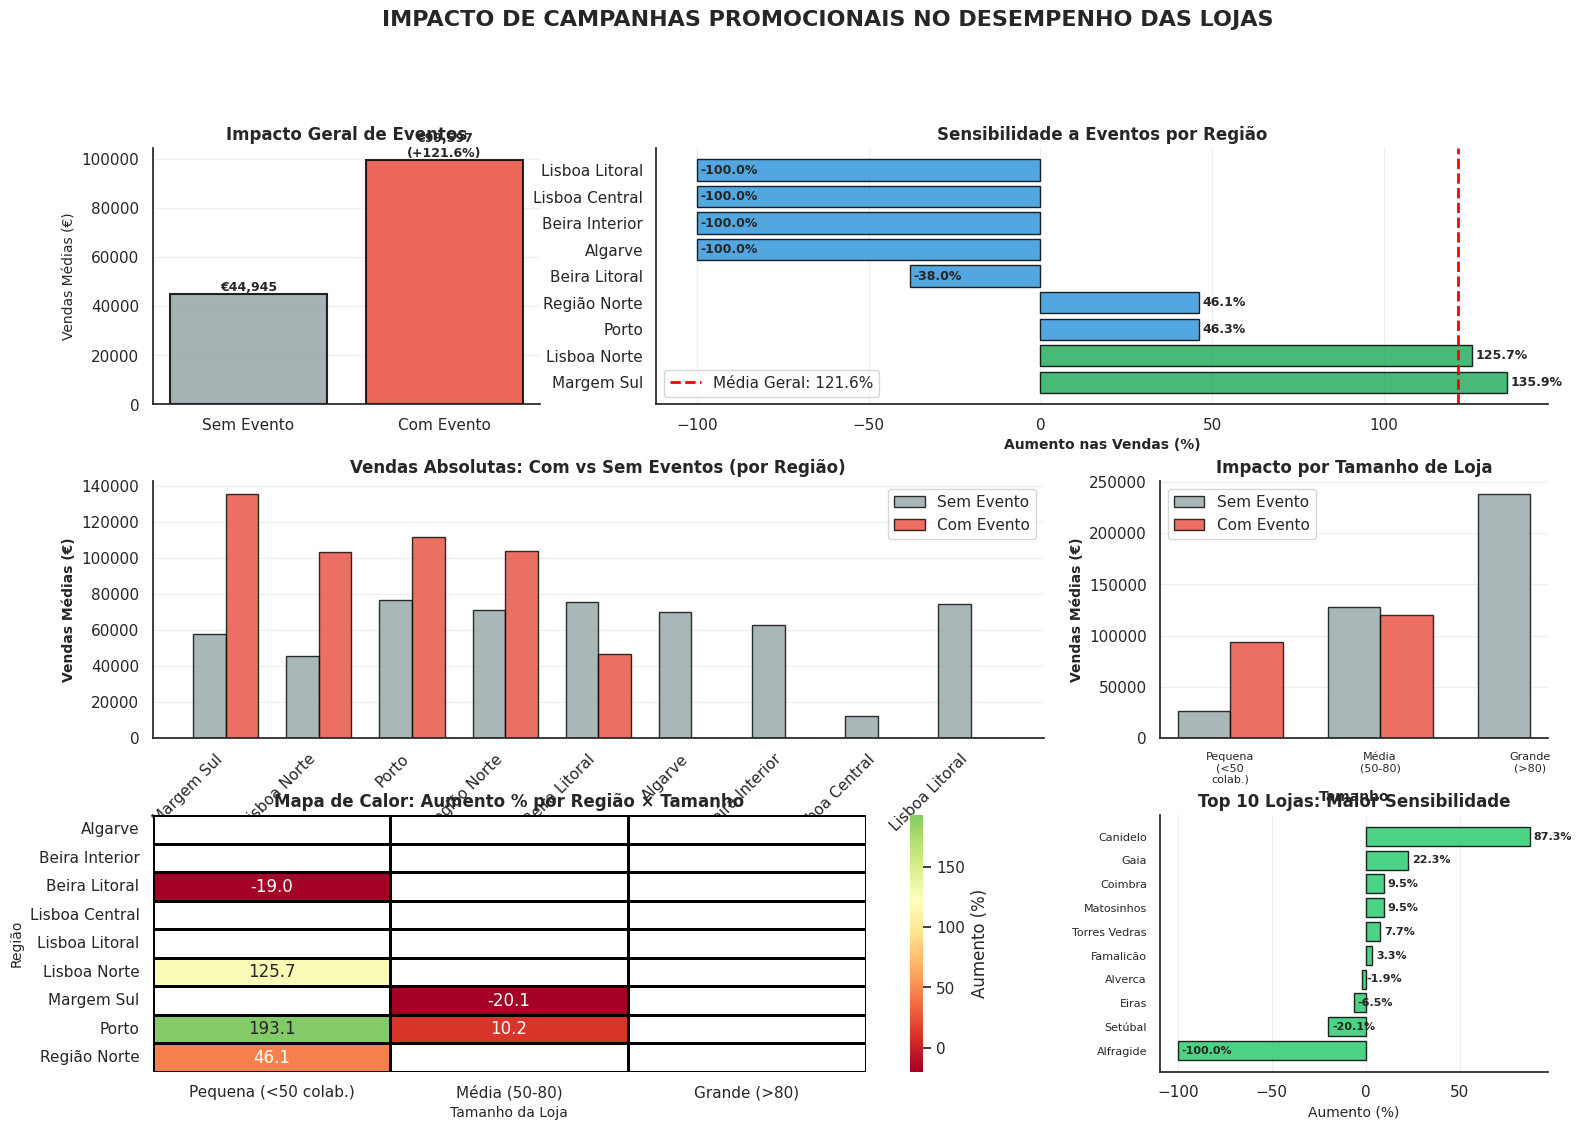


 CONCLUSÕES E INSIGHTS ESTRATÉGICOS

 IMPACTO GERAL:
   → Eventos têm impacto FORTE (+121.6%) nas vendas

 VARIAÇÃO REGIONAL:
   → Maior sensibilidade: Margem Sul (+135.9%)
   → Menor sensibilidade: Lisboa Litoral (+-100.0%)
   → Diferença regional: 235.9 pontos percentuais
    Alta variação regional → Segmentar campanhas por região!

 VARIAÇÃO POR TAMANHO:
   → Maior sensibilidade: Lojas Pequena (<50 colab.) (+254.4%)
   → Menor sensibilidade: Lojas Grande (>80) (+nan%)

 RECOMENDAÇÕES:
   1. Priorizar eventos em regiões com maior sensibilidade (top 3: Margem Sul, Lisboa Norte, Porto)
   2. Ajustar orçamento promocional considerando tamanho da loja
   3. Monitorar Top 10 lojas que mais se beneficiam de eventos para benchmarking
   4. Investigar regiões de baixa resposta para entender barreiras locais

 ANÁLISE CONCLUÍDA


In [0]:

# ANÁLISE COMPLETA: IMPACTO DE CAMPANHAS PROMOCIONAIS NO DESEMPENHO DAS LOJAS

# Objetivo: Avaliar como eventos/promoções afetam vendas e se o efeito varia
#           por região e características das lojas


import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print(" ANÁLISE: IMPACTO DE CAMPANHAS PROMOCIONAIS NO DESEMPENHO DAS LOJAS")
print("="*80 + "\n")

# Carregar dados
unificado_pd = unificado.toPandas() if hasattr(unificado, 'toPandas') else unificado
df = unificado_pd.copy()
print(f" Dataset: {len(df):,} registros | {df['LOJA'].nunique()} lojas | {df['REGIAO'].nunique()} regiões\n")


# PARTE 1: IMPACTO GERAL (Com vs Sem Eventos)

print("\n PARTE 1: IMPACTO GERAL DE EVENTOS\n" + "-"*80)

vendas_sem_evento = df[df['IS_EVENT'] == 0]['TARGET_VENDAS_DIARIAS_EUR'].mean()
vendas_com_evento = df[df['IS_EVENT'] == 1]['TARGET_VENDAS_DIARIAS_EUR'].mean()
aumento_percentual = ((vendas_com_evento - vendas_sem_evento) / vendas_sem_evento) * 100

print(f" Vendas médias SEM evento: €{vendas_sem_evento:,.2f}")
print(f" Vendas médias COM evento: €{vendas_com_evento:,.2f}")
print(f" Aumento absoluto: €{vendas_com_evento - vendas_sem_evento:,.2f}")
print(f" Aumento percentual: {aumento_percentual:+.1f}%")

# Estatísticas adicionais
dias_evento = (df['IS_EVENT'] == 1).sum()
dias_total = len(df)
pct_dias_evento = (dias_evento / dias_total) * 100

print(f"\n Dias com evento: {dias_evento:,} ({pct_dias_evento:.1f}% do total)")
print(f" Dias sem evento: {dias_total - dias_evento:,} ({100 - pct_dias_evento:.1f}% do total)")


# PARTE 2: VARIAÇÃO POR REGIÃO

print("\n\n PARTE 2: VARIAÇÃO DO IMPACTO POR REGIÃO\n" + "-"*80)

impacto_regiao = df.groupby(['REGIAO', 'IS_EVENT'])['TARGET_VENDAS_DIARIAS_EUR'].mean().unstack(fill_value=0)
impacto_regiao.columns = ['Sem_Evento', 'Com_Evento']
impacto_regiao['Aumento_Absoluto'] = impacto_regiao['Com_Evento'] - impacto_regiao['Sem_Evento']
impacto_regiao['Aumento_%'] = ((impacto_regiao['Com_Evento'] - impacto_regiao['Sem_Evento']) / impacto_regiao['Sem_Evento']) * 100
impacto_regiao = impacto_regiao.sort_values('Aumento_%', ascending=False)

print("\n RANKING DE REGIÕES POR SENSIBILIDADE A EVENTOS:\n")
for idx, (regiao, row) in enumerate(impacto_regiao.iterrows(), 1):
    emoji = "🥇" if idx == 1 else "🥈" if idx == 2 else "🥉" if idx == 3 else f"{idx}."
    print(f"{emoji:4s} {regiao:20s} | Sem: €{row['Sem_Evento']:>10,.0f} | Com: €{row['Com_Evento']:>10,.0f} | +{row['Aumento_%']:>5.1f}%")


# PARTE 3: VARIAÇÃO POR TAMANHO DE LOJA

print("\n\n PARTE 3: VARIAÇÃO DO IMPACTO POR TAMANHO DE LOJA\n" + "-"*80)

# Classificar lojas por tamanho (usando N_COLABORADORES)
df['TAMANHO_LOJA'] = pd.cut(df['N_COLABORADORES'], 
                             bins=[0, 50, 80, float('inf')], 
                             labels=['Pequena (<50 colab.)', 'Média (50-80)', 'Grande (>80)'])

impacto_tamanho = df.groupby(['TAMANHO_LOJA', 'IS_EVENT'])['TARGET_VENDAS_DIARIAS_EUR'].mean().unstack(fill_value=0)
impacto_tamanho.columns = ['Sem_Evento', 'Com_Evento']
impacto_tamanho['Aumento_Absoluto'] = impacto_tamanho['Com_Evento'] - impacto_tamanho['Sem_Evento']
impacto_tamanho['Aumento_%'] = ((impacto_tamanho['Com_Evento'] - impacto_tamanho['Sem_Evento']) / impacto_tamanho['Sem_Evento']) * 100

print("\n IMPACTO POR TAMANHO DE LOJA:\n")
for tamanho, row in impacto_tamanho.iterrows():
    print(f"{str(tamanho):25s} | Sem: €{row['Sem_Evento']:>10,.0f} | Com: €{row['Com_Evento']:>10,.0f} | +{row['Aumento_%']:>5.1f}%")


# PARTE 4: ANÁLISE DE LOJAS INDIVIDUAIS (Top performers)

print("\n\n PARTE 4: TOP 10 LOJAS QUE MAIS SE BENEFICIAM DE EVENTOS\n" + "-"*80)

impacto_loja = df.groupby(['LOJA', 'IS_EVENT'])['TARGET_VENDAS_DIARIAS_EUR'].mean().unstack(fill_value=0)
impacto_loja.columns = ['Sem_Evento', 'Com_Evento']
impacto_loja['Aumento_%'] = ((impacto_loja['Com_Evento'] - impacto_loja['Sem_Evento']) / impacto_loja['Sem_Evento']) * 100
top_10_lojas = impacto_loja.nlargest(10, 'Aumento_%')

print("\nLojas com MAIOR aumento percentual durante eventos:\n")
for idx, (loja, row) in enumerate(top_10_lojas.iterrows(), 1):
    print(f"{idx:2d}. {loja:30s} | +{row['Aumento_%']:>6.1f}% (€{row['Sem_Evento']:>8,.0f} → €{row['Com_Evento']:>8,.0f})")


print("\n\n GERANDO VISUALIZAÇÕES...\n")

sns.set_style("white")
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Comparação Geral (topo esquerdo)
ax1 = fig.add_subplot(gs[0, 0])
categorias = ['Sem Evento', 'Com Evento']
valores = [vendas_sem_evento, vendas_com_evento]
colors = ['#95a5a6', '#e74c3c']
bars = ax1.bar(categorias, valores, color=colors, edgecolor='black', linewidth=1.5, alpha=0.85)
ax1.set_title('Impacto Geral de Eventos', fontsize=12, fontweight='bold')
ax1.set_ylabel('Vendas Médias (€)', fontsize=10)
ax1.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'€{height:,.0f}\n({aumento_percentual:+.1f}%)' if bar == bars[1] else f'€{height:,.0f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
sns.despine(ax=ax1)

# 2. Aumento % por Região (topo centro e direita)
ax2 = fig.add_subplot(gs[0, 1:])
colors_regiao = ['#27ae60' if x > aumento_percentual else '#3498db' for x in impacto_regiao['Aumento_%']]
bars = ax2.barh(impacto_regiao.index, impacto_regiao['Aumento_%'], color=colors_regiao, edgecolor='black', alpha=0.85)
ax2.axvline(aumento_percentual, color='red', linestyle='--', linewidth=2, label=f'Média Geral: {aumento_percentual:.1f}%')
ax2.set_xlabel('Aumento nas Vendas (%)', fontsize=10, fontweight='bold')
ax2.set_title('Sensibilidade a Eventos por Região', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.legend()
for i, (idx, val) in enumerate(impacto_regiao['Aumento_%'].items()):
    ax2.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
sns.despine(ax=ax2)

# 3. Impacto por Região - Barras Agrupadas (meio esquerdo e centro)
ax3 = fig.add_subplot(gs[1, :2])
x = range(len(impacto_regiao))
width = 0.35
ax3.bar([i - width/2 for i in x], impacto_regiao['Sem_Evento'], width, label='Sem Evento', color='#95a5a6', edgecolor='black', alpha=0.8)
ax3.bar([i + width/2 for i in x], impacto_regiao['Com_Evento'], width, label='Com Evento', color='#e74c3c', edgecolor='black', alpha=0.8)
ax3.set_xlabel('Região', fontsize=10, fontweight='bold')
ax3.set_ylabel('Vendas Médias (€)', fontsize=10, fontweight='bold')
ax3.set_title('Vendas Absolutas: Com vs Sem Eventos (por Região)', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(impacto_regiao.index, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
sns.despine(ax=ax3)

# 4. Impacto por Tamanho - Barras Agrupadas (meio direito)
ax4 = fig.add_subplot(gs[1, 2])
x_tam = range(len(impacto_tamanho))
ax4.bar([i - width/2 for i in x_tam], impacto_tamanho['Sem_Evento'], width, label='Sem Evento', color='#95a5a6', edgecolor='black', alpha=0.8)
ax4.bar([i + width/2 for i in x_tam], impacto_tamanho['Com_Evento'], width, label='Com Evento', color='#e74c3c', edgecolor='black', alpha=0.8)
ax4.set_xlabel('Tamanho', fontsize=10, fontweight='bold')
ax4.set_ylabel('Vendas Médias (€)', fontsize=10, fontweight='bold')
ax4.set_title('Impacto por Tamanho de Loja', fontsize=12, fontweight='bold')
ax4.set_xticks(x_tam)
ax4.set_xticklabels([str(t).replace(' ', '\n') for t in impacto_tamanho.index], rotation=0, fontsize=8)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
sns.despine(ax=ax4)

# 5. Heatmap Região × Tamanho (baixo esquerdo)
ax5 = fig.add_subplot(gs[2, :2])
heatmap_data = df.groupby(['REGIAO', 'TAMANHO_LOJA', 'IS_EVENT'])['TARGET_VENDAS_DIARIAS_EUR'].mean().unstack(fill_value=0)
heatmap_data['Aumento_%'] = ((heatmap_data[1] - heatmap_data[0]) / heatmap_data[0]) * 100
heatmap_pivot = heatmap_data['Aumento_%'].unstack()
sns.heatmap(heatmap_pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=aumento_percentual,
            cbar_kws={'label': 'Aumento (%)'}, ax=ax5, linewidths=1, linecolor='black')
ax5.set_title('Mapa de Calor: Aumento % por Região × Tamanho', fontsize=12, fontweight='bold')
ax5.set_xlabel('Tamanho da Loja', fontsize=10)
ax5.set_ylabel('Região', fontsize=10)

# 6. Top 10 Lojas - Aumento % (baixo direito)
ax6 = fig.add_subplot(gs[2, 2])
ax6.barh(range(len(top_10_lojas)), top_10_lojas['Aumento_%'], color='#2ecc71', edgecolor='black', alpha=0.85)
ax6.set_yticks(range(len(top_10_lojas)))
ax6.set_yticklabels([nome[:20] for nome in top_10_lojas.index], fontsize=8)
ax6.invert_yaxis()
ax6.set_title('Top 10 Lojas: Maior Sensibilidade', fontsize=12, fontweight='bold')
ax6.set_xlabel('Aumento (%)', fontsize=10)
ax6.grid(axis='x', alpha=0.3)
for i, val in enumerate(top_10_lojas['Aumento_%']):
    ax6.text(val + 2, i, f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')
sns.despine(ax=ax6)

plt.suptitle('IMPACTO DE CAMPANHAS PROMOCIONAIS NO DESEMPENHO DAS LOJAS', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()


# CONCLUSÕES E INSIGHTS

print("\n" + "="*80)
print(" CONCLUSÕES E INSIGHTS ESTRATÉGICOS")
print("="*80 + "\n")

print(" IMPACTO GERAL:")
if aumento_percentual > 20:
    print(f"   → Eventos têm impacto FORTE (+{aumento_percentual:.1f}%) nas vendas")
else:
    print(f"   → Eventos têm impacto MODERADO (+{aumento_percentual:.1f}%) nas vendas")

print("\n VARIAÇÃO REGIONAL:")
regiao_max = impacto_regiao.iloc[0]
regiao_min = impacto_regiao.iloc[-1]
diferenca_regional = regiao_max['Aumento_%'] - regiao_min['Aumento_%']
print(f"   → Maior sensibilidade: {regiao_max.name} (+{regiao_max['Aumento_%']:.1f}%)")
print(f"   → Menor sensibilidade: {regiao_min.name} (+{regiao_min['Aumento_%']:.1f}%)")
print(f"   → Diferença regional: {diferenca_regional:.1f} pontos percentuais")

if diferenca_regional > 10:
    print("    Alta variação regional → Segmentar campanhas por região!")
else:
    print("    Variação regional moderada → Campanhas nacionais podem funcionar")

print("\n VARIAÇÃO POR TAMANHO:")
tamanho_max = impacto_tamanho.iloc[0]
tamanho_min = impacto_tamanho.iloc[-1]
print(f"   → Maior sensibilidade: Lojas {tamanho_max.name} (+{tamanho_max['Aumento_%']:.1f}%)")
print(f"   → Menor sensibilidade: Lojas {tamanho_min.name} (+{tamanho_min['Aumento_%']:.1f}%)")

if tamanho_max['Aumento_%'] - tamanho_min['Aumento_%'] > 10:
    print("    Tamanho importa! Ajustar intensidade de campanhas por porte da loja")

print("\n RECOMENDAÇÕES:")
print(f"   1. Priorizar eventos em regiões com maior sensibilidade (top 3: {', '.join(impacto_regiao.head(3).index)})")
print(f"   2. Ajustar orçamento promocional considerando tamanho da loja")
print(f"   3. Monitorar Top 10 lojas que mais se beneficiam de eventos para benchmarking")
print(f"   4. Investigar regiões de baixa resposta para entender barreiras locais")

print("\n" + "="*80)
print(" ANÁLISE CONCLUÍDA")
print("="*80)

# Ideias Outras Features

PRODUTOS_POR_COLABORADOR — distribuição:
count     70.0
mean     340.7
std      162.4
min      174.9
25%      228.9
50%      278.0
75%      418.0
max      800.2
Name: PRODUTOS_POR_COLABORADOR, dtype: float64

Produtos por colaborador, por quartil de equipa:
QUARTIL_COLAB
Q1    248.6
Q2    201.7
Q3    307.9
Q4    542.2
Name: PRODUTOS_POR_COLABORADOR, dtype: float64


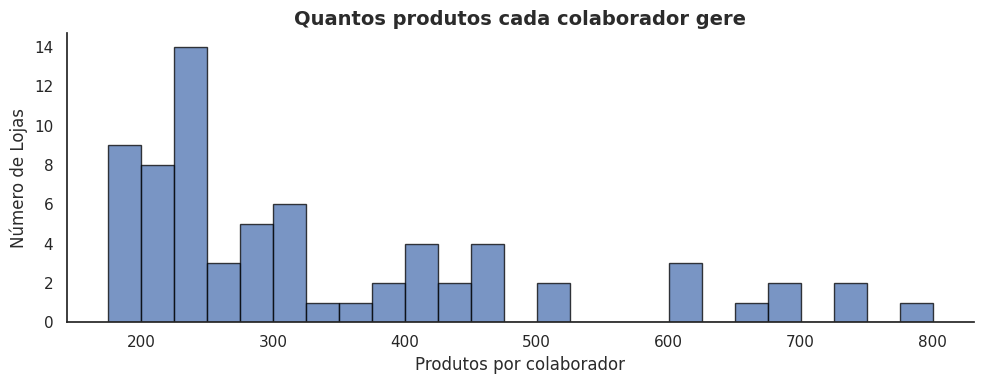

In [0]:
info_loja['PRODUTOS_POR_COLABORADOR'] = info_loja['SKUS'] / info_loja['N_COLABORADORES']

print("PRODUTOS_POR_COLABORADOR — distribuição:")
print(info_loja['PRODUTOS_POR_COLABORADOR'].describe().round(1))

info_loja['QUARTIL_COLAB'] = pd.qcut(info_loja['N_COLABORADORES'], 4, labels=['Q1','Q2','Q3','Q4'])

print("\nProdutos por colaborador, por quartil de equipa:")
print(info_loja.groupby('QUARTIL_COLAB', observed=True)['PRODUTOS_POR_COLABORADOR'].median().round(1))

sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(info_loja['PRODUTOS_POR_COLABORADOR'], bins=25, edgecolor="black", alpha=0.75, color="#4c72b0")
ax.set_title("Quantos produtos cada colaborador gere", fontsize=14, fontweight='bold', color="#2b2b2b")
ax.set_xlabel("Produtos por colaborador", fontsize=12, color="#2b2b2b")
ax.set_ylabel("Número de Lojas", fontsize=12, color="#2b2b2b")
ax.grid(False)
sns.despine()
plt.tight_layout()
plt.show()

Como ajuda o modelo? Talvez ajude pouco a fornecer uma pista sobre o tamanho da loja. (Uma loja com muitos produtos e poucos funcionários costuma ser uma loja grande e automatizada (self-service, tipo hipermercado) — e essas vendem muito. Uma loja com poucos produtos por funcionário costuma ser pequena e assistida (tipo loja de bairro) — e essas vendem menos.)      
✨ FEATURE, nova coluna SKUs/colaboradores

#O quão automatizada é a loja

TAXA_AUTOMACAO — proporção de caixas self-checkout (nível de automação):
count    70.000
mean      0.145
std       0.186
min       0.000
25%       0.000
50%       0.000
75%       0.273
max       0.727
Name: TAXA_AUTOMACAO, dtype: float64


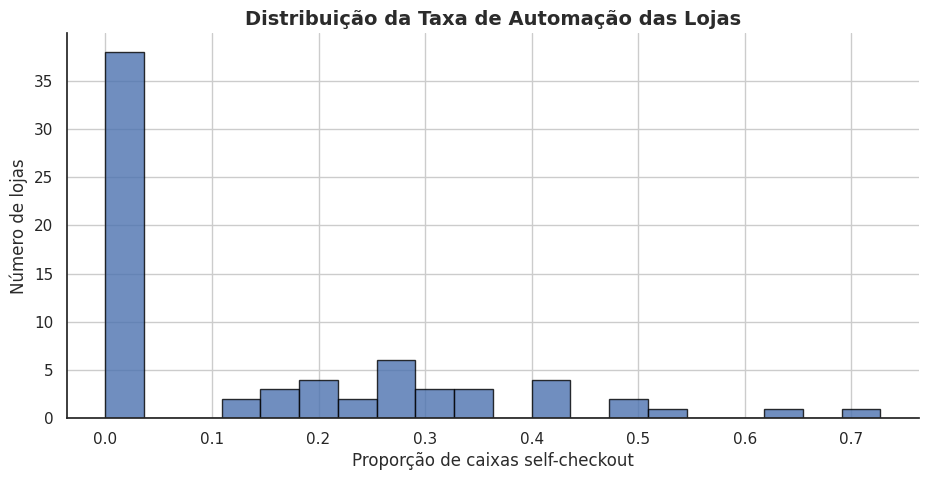

In [0]:
info_loja['TAXA_AUTOMACAO'] = np.divide(
    info_loja['SELF_CHECKOUTS'],
    info_loja['SELF_CHECKOUTS'] + info_loja['CAIXAS_TRADICIONAIS'],
    out=np.zeros_like(info_loja['SELF_CHECKOUTS'], dtype=float),
    where=(info_loja['SELF_CHECKOUTS'] + info_loja['CAIXAS_TRADICIONAIS']) != 0
)

print("TAXA_AUTOMACAO — proporção de caixas self-checkout (nível de automação):")
print(info_loja['TAXA_AUTOMACAO'].describe().round(3))

# --- gráfico ---
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")
fig, ax = plt.subplots(figsize=(11, 5))
info_loja['TAXA_AUTOMACAO'].hist(bins=20, edgecolor="black", alpha=0.8, color="#4c72b0", ax=ax)
ax.set_title("Distribuição da Taxa de Automação das Lojas", fontsize=14, fontweight="bold", color="#2b2b2b")
ax.set_xlabel("Proporção de caixas self-checkout", fontsize=12, color="#2b2b2b")
ax.set_ylabel("Número de lojas", fontsize=12, color="#2b2b2b")
sns.despine()
plt.show()

Como ajuda o modelo? 38 das 70 lojas não tem nenhum self-checkout. Pode ajudar separar a loja moderna/grande (mais automação → vende mais) de loja pequena/tradicional (sem automação → vende menos).   

✨ FEATURE: coluna nova, TAXA_AUTOMACAO = SELF_CHECKOUTS / (SELF_CHECKOUTS + CAIXAS_TRADICIONAIS)

#Interação Região × Mês (sazonalidade regional)

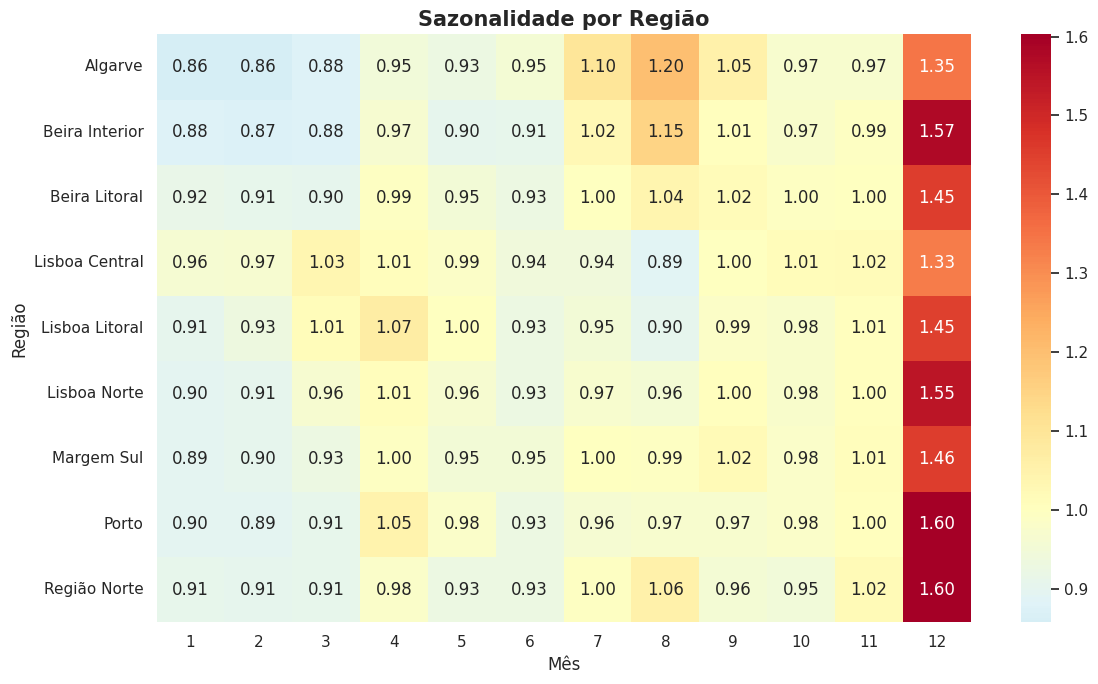

In [0]:
df = unificado.copy()
df['MES'] = pd.to_datetime(df['DATA']).dt.month
df['MEDIA_REGIAO'] = df.groupby('REGIAO')['TARGET_VENDAS_DIARIAS_EUR'].transform('mean')
df['MEDIA_MES_REGIAO'] = df.groupby(['REGIAO', 'MES'])['TARGET_VENDAS_DIARIAS_EUR'].transform('mean')
df['INDICE_SAZONAL'] = df['MEDIA_MES_REGIAO'] / df['MEDIA_REGIAO']
pivot = df.drop_duplicates(['REGIAO', 'MES'])[['REGIAO', 'MES', 'INDICE_SAZONAL']].pivot(index='REGIAO', columns='MES', values='INDICE_SAZONAL')
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")
plt.figure(figsize=(12, 7))
sns.heatmap(pivot, cmap="RdYlBu_r", center=1.0, annot=True, fmt=".2f")
plt.title("Sazonalidade por Região", fontsize=15, fontweight='bold')
plt.xlabel("Mês")
plt.ylabel("Região")
plt.tight_layout()
plt.show()

Como ajuda o modelo? As pessoas saem de Lisboa e Porto e vão para Algarve e as vendas seguem o movimento. A sazonalidade não é nacional, ela é regional. Então o modelo dá respostas diferentes ao mesmo mês conforme a região. 

✨FEATURE: df["REGIAO_MES"] = df["REGIAO"] + "_" + df["MES"].astype(str) - Não é uma conta matemática (não tem divisão nem soma de números) — é uma combinação de rótulos. Cada par região+mês vira uma categoria própria, e é isso que permite ao modelo tratar "agosto no Algarve" diferente de "agosto em Lisboa".

#Rank na Região

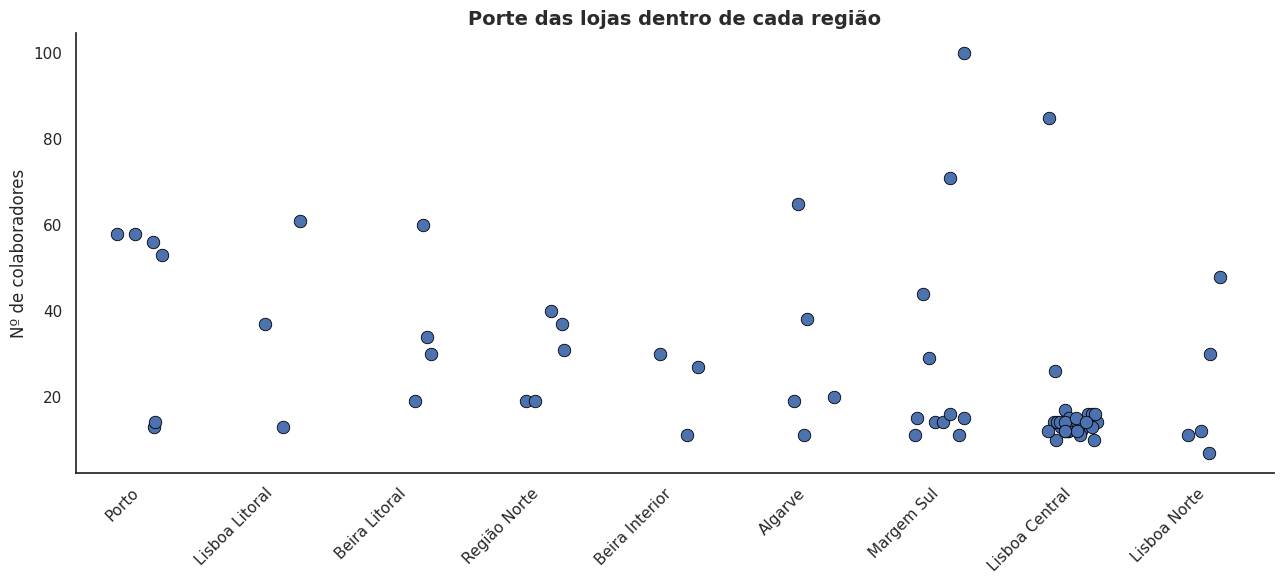

In [0]:
#⚠️ NAO USAR VENDAS = ISSO SERIA VAZAMENTO!!!! esta loja vende mais ou menos que as vizinhas?
# df_rank = unificado.groupby(['REGIAO', 'FK_SECAO'], observed=True)['TARGET_VENDAS_DIARIAS_EUR'].mean().reset_index(name='VENDA_MEDIA')
# df_rank['RANK_NA_REGIAO'] = df_rank.groupby('REGIAO')['VENDA_MEDIA'].rank(ascending=False, method='min')
# regioes_ordem = df_rank.groupby('REGIAO')['VENDA_MEDIA'].median().sort_values(ascending=False).index
# sns.set_style("white")
# plt.figure(figsize=(12, 6))
# sns.stripplot(data=df_rank, x='REGIAO', y='VENDA_MEDIA', order=regioes_ordem, jitter=0.15, size=8, alpha=0.85, edgecolor='black')
# plt.xticks(rotation=45, ha='right')
# plt.title("Rank na Região", fontsize=14, fontweight='bold')
# plt.xlabel("Região")
# plt.ylabel("Venda média por loja (€)")
# plt.tight_layout()
# plt.show()


#-------
# esta loja é maior ou menor que as vizinhas?

 # cria a feature (rank de porte da loja dentro da região, em escala 0–1)
info_loja["RANK_PORTE_REGIAO_PCT"] = (
    info_loja.groupby("REGIAO")["N_COLABORADORES"]
             .rank(ascending=False, pct=True)
)

# gráfico: cada loja posicionada pelo seu porte dentro da região
ordem = (info_loja.groupby("REGIAO")["N_COLABORADORES"]
                  .median().sort_values(ascending=False).index)

sns.set_style("white")
fig, ax = plt.subplots(figsize=(13, 6))
sns.stripplot(data=info_loja, x="REGIAO", y="N_COLABORADORES", order=ordem,
              size=9, color="#4c72b0", edgecolor="black", linewidth=.6, jitter=.2, ax=ax)
ax.set_xticklabels(ordem, rotation=45, ha="right")
ax.set_title("Porte das lojas dentro de cada região", fontsize=14, fontweight="bold", color="#2b2b2b")
ax.set_xlabel("")
ax.set_ylabel("Nº de colaboradores", fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()


Ordenei as lojas por número de colaboradores dentro de cada região — quem tem mais gente fica no topo. Assim dá para ver se a loja é grande ou pequena para o mercado local dela. Ajuda o modelo, ela diz se a loja é grande ou pequena para o mercado local dela — uma loja de 40 colaboradores é "a maior" no interior mas "mediana" em Lisboa. 
info_loja["RANK_PORTE_REGIAO_PCT"] = (
    info_loja.groupby("REGIAO")["N_COLABORADORES"]
             .rank(ascending=False, pct=True)
)

#VENDAS POR TIPO DE LOJA (CLASSIFICAÇÃO MULTIFATORIAL POR PERCENTIS)


 ANÁLISE: VENDAS POR TIPO DE LOJA (CLASSIFICAÇÃO MULTIFATORIAL POR PERCENTIS)

 Usando dados em memória: 98,641 registros de vendas, 70 lojas


 PARTE 1: PREPARAÇÃO DOS DADOS
--------------------------------------------------------------------------------
 Dataset criado: 70 lojas

 Estatísticas descritivas das variáveis físicas:

       N_COLABORADORES     SKUS  ...  SELF_CHECKOUTS  Vendas_Media
count             70.0     70.0  ...            70.0          70.0
mean              25.4  11030.9  ...             3.1       43780.0
std               19.9  13517.3  ...             5.3       56455.0
min                7.0   2523.0  ...             0.0        2563.2
25%               13.0   2977.2  ...             0.0        5068.3
50%               15.0   3338.0  ...             0.0        8126.0
75%               30.8  13769.2  ...             4.0       76085.0
max              100.0  48810.0  ...            26.0      270112.8

[8 rows x 5 columns]


 PARTE 2: CLASSIFICAÇÃO MULTIFATORIAL P

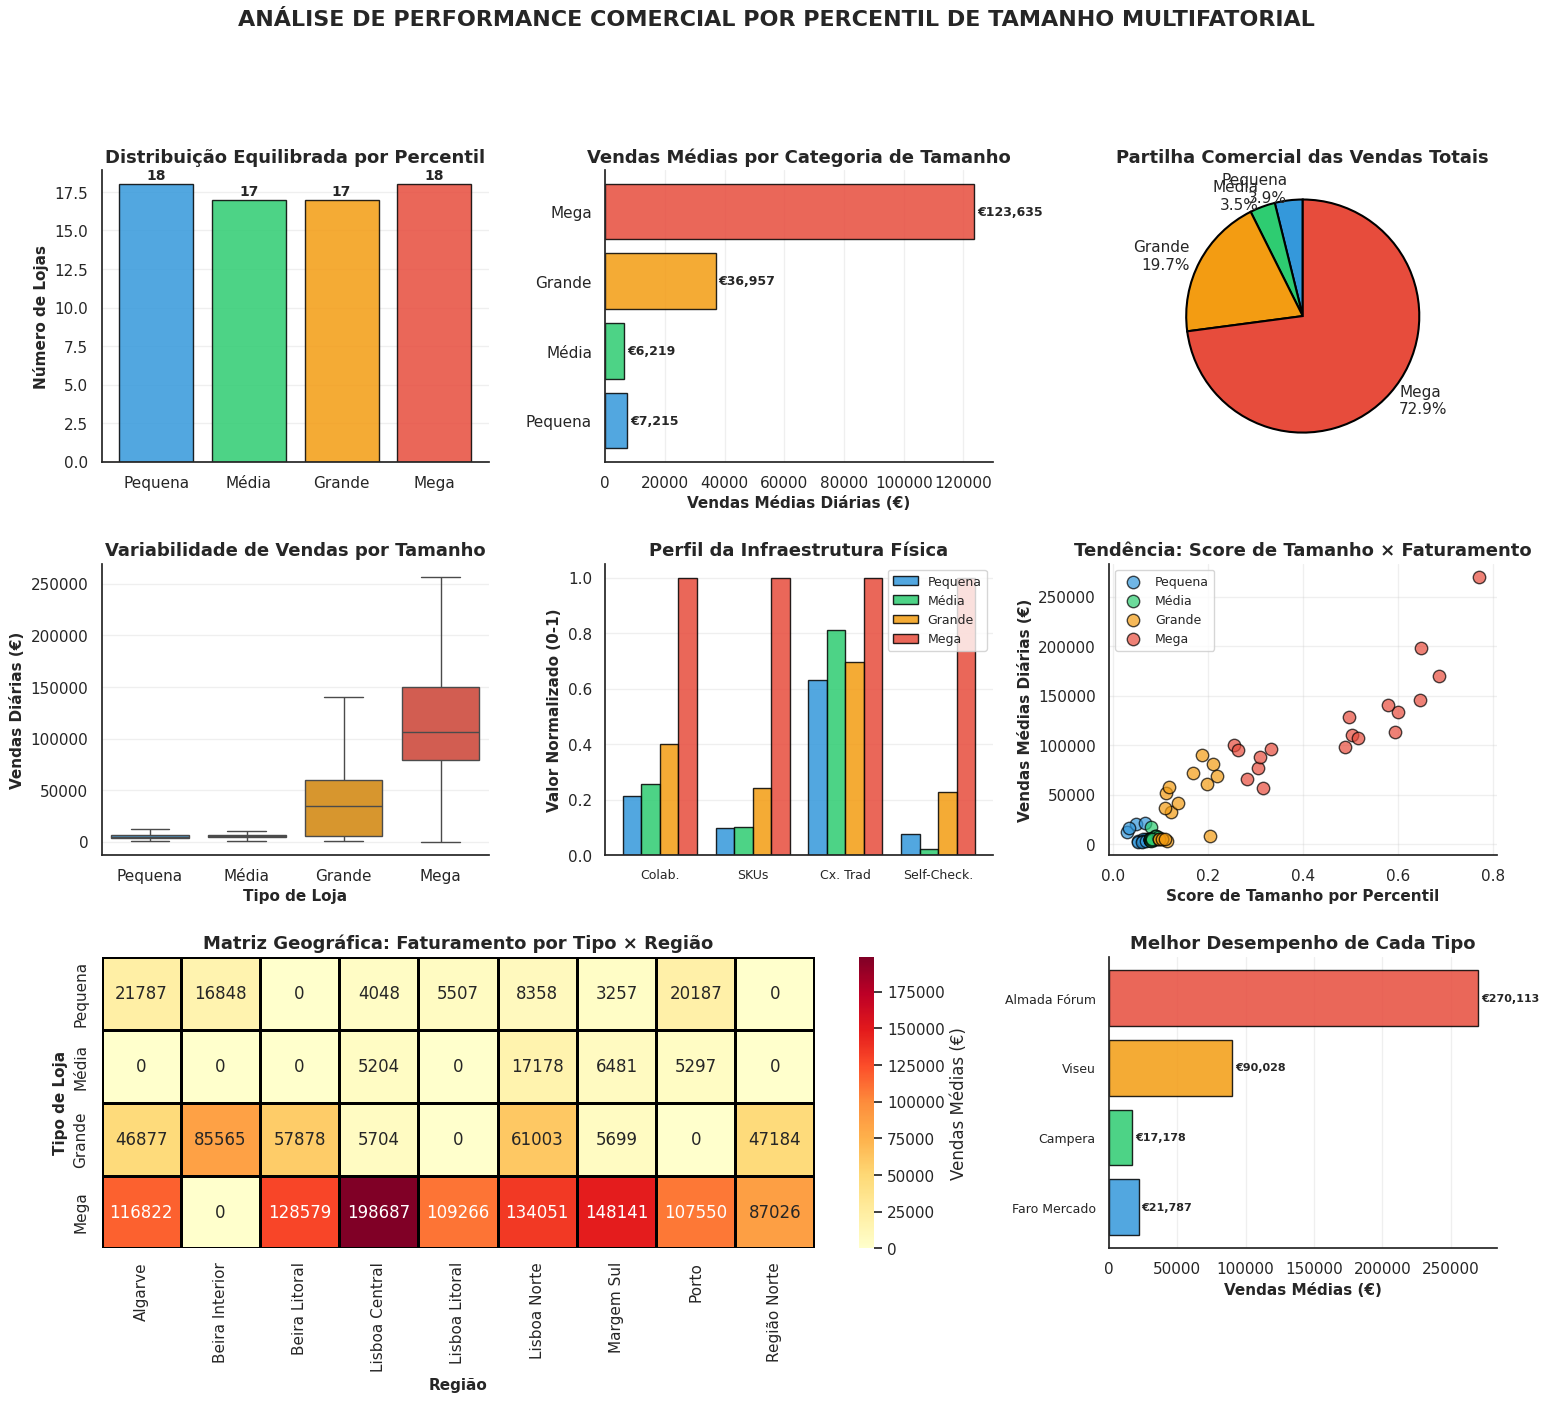


 CONCLUSÕES E INSIGHTS ESTRATÉGICOS (MÉTRICAS POR PERCENTIS)

 COMPOSIÇÃO DA CLASSIFICAÇÃO:
   → Mapeamento baseado em: Colaboradores (35%), SKUs (30%), Caixas Tradicionais (20%), Self-Checkouts (15%)
   → Abordagem estatística: Divisão uniforme por quantis de 25% garantindo grupos analíticos válidos.

 PERFORMANCE COMERCIAL POR CATEGORIA REESCALADA:
   Pequena   : €     7,215/dia | 18 lojas (  3.9% do faturamento)
   Média     : €     6,219/dia | 17 lojas (  3.5% do faturamento)
   Grande    : €    36,957/dia | 17 lojas ( 19.7% do faturamento)
   Mega      : €   123,635/dia | 18 lojas ( 72.9% do faturamento)

 INSIGHTS DE ENGENHARIA DE FEATURES:
   → Correlação Linear Score de Tamanho × Vendas: 0.939 (FORTE - a capacidade física é um excelente preditor linear direto)
   → Categoria com maior volatilidade (Coeficiente de Variação): Mega (CV: 0.31)
     • Dica para Modelagem: Adicionar interações de dias de semana para prever Mega com precisão.

 ANÁLISE CONCLUÍDA COM SUCESSO


In [0]:

# ANÁLISE: VENDAS POR TIPO DE LOJA (CLASSIFICAÇÃO MULTIFATORIAL POR PERCENTIS)

# Objetivo: Classificar lojas usando múltiplos critérios de dimensão física
# Fatores: SKUs, Colaboradores, Caixas Tradicionais, Self-Checkouts
# Método: Divisão matemática equilibrada por Percentis (Quantis de 25%)


import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print(" ANÁLISE: VENDAS POR TIPO DE LOJA (CLASSIFICAÇÃO MULTIFATORIAL POR PERCENTIS)")
print("="*80 + "\n")

# Usar dados já carregados
unificado_pd = unificado.copy()
print(f" Usando dados em memória: {len(unificado_pd):,} registros de vendas, {len(info_loja)} lojas\n")


# PARTE 1: PREPARAÇÃO DOS DADOS E NORMALIZAÇÃO

print("\n PARTE 1: PREPARAÇÃO DOS DADOS\n" + "-"*80)

# Criar dataset agregado por loja
df_lojas = info_loja[['LOJA', 'REGIAO', 'N_COLABORADORES', 'SKUS', 
                      'CAIXAS_TRADICIONAIS', 'SELF_CHECKOUTS']].copy()

# Adicionar total de caixas como métrica física de suporte
df_lojas['TOTAL_CAIXAS'] = df_lojas['CAIXAS_TRADICIONAIS'] + df_lojas['SELF_CHECKOUTS']

# Adicionar vendas médias por loja
vendas_loja = unificado_pd.groupby('LOJA')['TARGET_VENDAS_DIARIAS_EUR'].agg([
    ('Vendas_Media', 'mean'),
    ('Vendas_Mediana', 'median'),
    ('Vendas_Std', 'std'),
    ('Dias', 'count')
]).reset_index()

df_lojas = df_lojas.merge(vendas_loja, on='LOJA')

print(f" Dataset criado: {len(df_lojas)} lojas")
print(f"\n Estatísticas descritivas das variáveis físicas:\n")
print(df_lojas[['N_COLABORADORES', 'SKUS', 'CAIXAS_TRADICIONAIS', 'SELF_CHECKOUTS', 'Vendas_Media']].describe().round(1))


# PARTE 2: CLASSIFICAÇÃO POR SCORING MULTIFATORIAL E QUANTIS (PERCENTIS)

print("\n\n PARTE 2: CLASSIFICAÇÃO MULTIFATORIAL POR PERCENTIS\n" + "-"*80)

# Normalizar features físicas (0-1) para manter a escala proporcional
features_para_classificar = ['N_COLABORADORES', 'SKUS', 'CAIXAS_TRADICIONAIS', 'SELF_CHECKOUTS']

df_normalizado = df_lojas.copy()
for feat in features_para_classificar:
    min_val = df_lojas[feat].min()
    max_val = df_lojas[feat].max()
    if max_val - min_val > 0:
        df_normalizado[f'{feat}_norm'] = (df_lojas[feat] - min_val) / (max_val - min_val)
    else:
        df_normalizado[f'{feat}_norm'] = 0.0

# Criar score composto (ponderação estrita de tamanho/capacidade)
pesos = {
    'N_COLABORADORES_norm': 0.35,  # Peso maior - escala operacional
    'SKUS_norm': 0.30,             # Variedade e dimensão física de exposição
    'CAIXAS_TRADICIONAIS_norm': 0.20, # Capacidade de processamento tradicional
    'SELF_CHECKOUTS_norm': 0.15     # Capacidade de processamento rápido
}

df_normalizado['SCORE_TAMANHO'] = sum(
    df_normalizado[feat] * peso for feat, peso in pesos.items()
)

# Classificar em 4 categorias baseado em PERCENTIS (divisão em 4 fatias de 25% com base nos dados reais)
df_normalizado['TIPO_LOJA'] = pd.qcut(
    df_normalizado['SCORE_TAMANHO'],
    q=4,
    labels=['Pequena', 'Média', 'Grande', 'Mega']
)

print("\n NOVA DISTRIBUIÇÃO DE LOJAS POR TIPO (PERCENTIS EQUILIBRADOS):\n")
dist_tipos = df_normalizado['TIPO_LOJA'].value_counts().sort_index()
for tipo, count in dist_tipos.items():
    pct = (count / len(df_normalizado)) * 100
    print(f"{tipo:10s}: {count:2d} lojas ({pct:5.1f}%)")

# Características médias por tipo
print("\n CARACTERÍSTICAS MÉDIAS OPERACIONAIS POR TIPO DE LOJA:\n")
caract_por_tipo = df_normalizado.groupby('TIPO_LOJA', observed=True)[[
    'N_COLABORADORES', 'SKUS', 'CAIXAS_TRADICIONAIS', 'SELF_CHECKOUTS', 'TOTAL_CAIXAS', 'Vendas_Media'
]].mean().round(1)

for tipo in ['Pequena', 'Média', 'Grande', 'Mega']:
    if tipo in caract_por_tipo.index:
        row = caract_por_tipo.loc[tipo]
        print(f"{tipo:10s} | Colab: {row['N_COLABORADORES']:>5.0f} | SKUs: {row['SKUS']:>6.0f} | "
              f"Cx Trad.: {row['CAIXAS_TRADICIONAIS']:>4.1f} | Self-Ch.: {row['SELF_CHECKOUTS']:>4.1f} | "
              f"Vendas: €{row['Vendas_Media']:>10,.0f}")


# PARTE 3: ANÁLISE DE VENDAS POR TIPO DE LOJA

print("\n\n PARTE 3: ANÁLISE DE VENDAS POR TIPO DE LOJA\n" + "-"*80)

# Juntar tipo de loja ao dataset de vendas diárias
df_vendas = unificado_pd.merge(
    df_normalizado[['LOJA', 'TIPO_LOJA', 'SCORE_TAMANHO']],
    on='LOJA',
    how='left'
)

# Estatísticas de vendas por tipo
vendas_por_tipo = df_vendas.groupby('TIPO_LOJA', observed=True)['TARGET_VENDAS_DIARIAS_EUR'].agg([
    ('Média', 'mean'),
    ('Mediana', 'median'),
    ('Desvio_Padrão', 'std'),
    ('Mínimo', 'min'),
    ('Máximo', 'max'),
    ('Total_Dias', 'count')
]).round(2)

print("\n ESTATÍSTICAS DE VENDAS DIÁRIAS POR TIPO:\n")
for tipo in ['Pequena', 'Média', 'Grande', 'Mega']:
    if tipo in vendas_por_tipo.index:
        row = vendas_por_tipo.loc[tipo]
        print(f"{tipo:10s} | Média: €{row['Média']:>10,.0f} | Mediana: €{row['Mediana']:>10,.0f} | "
              f"Desvio-Padrão: €{row['Desvio_Padrão']:>10,.0f}")

# Vendas totais e share por tipo
vendas_totais_tipo = df_vendas.groupby('TIPO_LOJA', observed=True)['TARGET_VENDAS_DIARIAS_EUR'].sum()
vendas_totais_geral = vendas_totais_tipo.sum()

print("\n VENDAS TOTAIS E PARTICIPAÇÃO COMERCIAL (SHARE):\n")
for tipo in ['Pequena', 'Média', 'Grande', 'Mega']:
    if tipo in vendas_totais_tipo.index:
        total = vendas_totais_tipo[tipo]
        share = (total / vendas_totais_geral) * 100
        n_lojas = dist_tipos[tipo]
        vendas_per_loja = total / n_lojas
        print(f"{tipo:10s} | Total: €{total:>15,.0f} | Share: {share:>5.1f}% | "
              f"Média por Loja: €{vendas_per_loja:>12,.0f}")


# PARTE 4: ANÁLISE POR TIPO E REGIÃO

print("\n\n PARTE 4: VENDAS POR TIPO DE LOJA E REGIÃO\n" + "-"*80)

vendas_tipo_regiao = df_vendas.groupby(['TIPO_LOJA', 'REGIAO'], observed=True)['TARGET_VENDAS_DIARIAS_EUR'].mean().round(0)

print("\n TOP 3 REGIÕES POR TIPO DE LOJA (vendas médias):\n")
for tipo in ['Pequena', 'Média', 'Grande', 'Mega']:
    if tipo in vendas_tipo_regiao.index.get_level_values(0):
        print(f"\n{tipo}:")
        top3 = vendas_tipo_regiao[tipo].nlargest(3)
        for regiao, valor in top3.items():
            print(f"  {regiao:20s}: €{valor:>10,.0f}")


# PARTE 5: VISUALIZAÇÕES ATUALIZADAS

print("\n\n GERANDO VISUALIZAÇÕES...\n")

sns.set_style("white")
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Distribuição de Lojas por Tipo (Equilibrado por Percentis)
ax1 = fig.add_subplot(gs[0, 0])
colors_tipo = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
dist_tipos_sorted = dist_tipos.sort_index()
ax1.bar(range(len(dist_tipos_sorted)), dist_tipos_sorted.values, color=colors_tipo, 
        edgecolor='black', alpha=0.85)
ax1.set_xticks(range(len(dist_tipos_sorted)))
ax1.set_xticklabels(dist_tipos_sorted.index, fontsize=11)
ax1.set_ylabel('Número de Lojas', fontsize=11, fontweight='bold')
ax1.set_title('Distribuição Equilibrada por Percentil', fontsize=13, fontweight='bold')
for i, val in enumerate(dist_tipos_sorted.values):
    ax1.text(i, val + 0.1, str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
sns.despine(ax=ax1)

# 2. Vendas Médias por Tipo
ax2 = fig.add_subplot(gs[0, 1])
vendas_medias_sorted = vendas_por_tipo['Média'].sort_index()
ax2.barh(range(len(vendas_medias_sorted)), vendas_medias_sorted.values, 
         color=colors_tipo, edgecolor='black', alpha=0.85)
ax2.set_yticks(range(len(vendas_medias_sorted)))
ax2.set_yticklabels(vendas_medias_sorted.index, fontsize=11)
ax2.set_xlabel('Vendas Médias Diárias (€)', fontsize=11, fontweight='bold')
ax2.set_title('Vendas Médias por Categoria de Tamanho', fontsize=13, fontweight='bold')
for i, val in enumerate(vendas_medias_sorted.values):
    ax2.text(val + 1000, i, f'€{val:,.0f}', va='center', fontsize=9, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
sns.despine(ax=ax2)

# 3. Share de Vendas Reais
ax3 = fig.add_subplot(gs[0, 2])
shares = [(vendas_totais_tipo[tipo] / vendas_totais_geral) * 100 
          for tipo in ['Pequena', 'Média', 'Grande', 'Mega'] if tipo in vendas_totais_tipo.index]
labels_share = [f"{tipo}\n{share:.1f}%" for tipo, share in zip(vendas_totais_tipo.index, shares)]
ax3.pie(vendas_totais_tipo.values, labels=labels_share, colors=colors_tipo, 
        autopct='', startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
ax3.set_title('Partilha Comercial das Vendas Totais', fontsize=13, fontweight='bold')

# 4. Boxplot Vendas por Tipo
ax4 = fig.add_subplot(gs[1, 0])
df_vendas_plot = df_vendas[df_vendas['TIPO_LOJA'].notna()].copy()
sns.boxplot(data=df_vendas_plot, x='TIPO_LOJA', y='TARGET_VENDAS_DIARIAS_EUR', 
            ax=ax4, palette=colors_tipo, showfliers=False, 
            order=['Pequena', 'Média', 'Grande', 'Mega'])
ax4.set_xlabel('Tipo de Loja', fontsize=11, fontweight='bold')
ax4.set_ylabel('Vendas Diárias (€)', fontsize=11, fontweight='bold')
ax4.set_title('Variabilidade de Vendas por Tamanho', fontsize=13, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
sns.despine(ax=ax4)

# 5. Características Reais de Dimensionamento (Normalizado 0-1)
ax5 = fig.add_subplot(gs[1, 1])
caract_norm = caract_por_tipo[['N_COLABORADORES', 'SKUS', 'CAIXAS_TRADICIONAIS', 'SELF_CHECKOUTS']].copy()
for col in caract_norm.columns:
    if caract_norm[col].max() > 0:
        caract_norm[col] = caract_norm[col] / caract_norm[col].max()

x_pos = np.arange(len(caract_norm.columns))
width = 0.2
for i, tipo in enumerate(['Pequena', 'Média', 'Grande', 'Mega']):
    if tipo in caract_norm.index:
        ax5.bar(x_pos + i*width, caract_norm.loc[tipo].values, width, 
                label=tipo, color=colors_tipo[i], edgecolor='black', alpha=0.85)
ax5.set_xticks(x_pos + width * 1.5)
ax5.set_xticklabels(['Colab.', 'SKUs', 'Cx. Trad', 'Self-Check.'], fontsize=9)
ax5.set_ylabel('Valor Normalizado (0-1)', fontsize=11, fontweight='bold')
ax5.set_title('Perfil da Infraestrutura Física', fontsize=13, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(axis='y', alpha=0.3)
sns.despine(ax=ax5)

# 6. Scatter: Score de Tamanho vs Vendas Diárias Médias
ax6 = fig.add_subplot(gs[1, 2])
for i, tipo in enumerate(['Pequena', 'Média', 'Grande', 'Mega']):
    mask = df_normalizado['TIPO_LOJA'] == tipo
    ax6.scatter(df_normalizado.loc[mask, 'SCORE_TAMANHO'], 
                df_normalizado.loc[mask, 'Vendas_Media'],
                label=tipo, color=colors_tipo[i], s=80, alpha=0.7, edgecolor='black')
ax6.set_xlabel('Score de Tamanho por Percentil', fontsize=11, fontweight='bold')
ax6.set_ylabel('Vendas Médias Diárias (€)', fontsize=11, fontweight='bold')
ax6.set_title('Tendência: Score de Tamanho × Faturamento', fontsize=13, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(alpha=0.3)
sns.despine(ax=ax6)

# 7. Heatmap: Tipo × Região
ax7 = fig.add_subplot(gs[2, :2])
heatmap_data = df_vendas.groupby(['TIPO_LOJA', 'REGIAO'], observed=True)['TARGET_VENDAS_DIARIAS_EUR'].mean().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(['Pequena', 'Média', 'Grande', 'Mega'])
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax7, 
            cbar_kws={'label': 'Vendas Médias (€)'}, linewidths=1, linecolor='black')
ax7.set_xlabel('Região', fontsize=11, fontweight='bold')
ax7.set_ylabel('Tipo de Loja', fontsize=11, fontweight='bold')
ax7.set_title('Matriz Geográfica: Faturamento por Tipo × Região', fontsize=13, fontweight='bold')

# 8. Top Lojas por Categoria de Percentil
ax8 = fig.add_subplot(gs[2, 2])
top_por_tipo = df_normalizado.groupby('TIPO_LOJA', observed=True).apply(
    lambda x: x.nlargest(1, 'Vendas_Media')[['LOJA', 'Vendas_Media']]
).reset_index(drop=True)
ax8.barh(range(len(top_por_tipo)), top_por_tipo['Vendas_Media'], 
         color=colors_tipo[:len(top_por_tipo)], edgecolor='black', alpha=0.85)
ax8.set_yticks(range(len(top_por_tipo)))
labels_top = [f"{row['LOJA'][:15]}..." if len(row['LOJA']) > 15 else row['LOJA'] 
              for _, row in top_por_tipo.iterrows()]
ax8.set_yticklabels(labels_top, fontsize=9)
ax8.set_xlabel('Vendas Médias (€)', fontsize=11, fontweight='bold')
ax8.set_title('Melhor Desempenho de Cada Tipo', fontsize=13, fontweight='bold')
for i, val in enumerate(top_por_tipo['Vendas_Media']):
    ax8.text(val + 2000, i, f'€{val:,.0f}', va='center', fontsize=8, fontweight='bold')
ax8.grid(axis='x', alpha=0.3)
sns.despine(ax=ax8)

plt.suptitle('ANÁLISE DE PERFORMANCE COMERCIAL POR PERCENTIL DE TAMANHO MULTIFATORIAL', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()


# CONCLUSÕES E INSIGHTS

print("\n" + "="*80)
print(" CONCLUSÕES E INSIGHTS ESTRATÉGICOS (MÉTRICAS POR PERCENTIS)")
print("="*80 + "\n")

print(" COMPOSIÇÃO DA CLASSIFICAÇÃO:")
print(f"   → Mapeamento baseado em: Colaboradores (35%), SKUs (30%), Caixas Tradicionais (20%), Self-Checkouts (15%)")
print(f"   → Abordagem estatística: Divisão uniforme por quantis de 25% garantindo grupos analíticos válidos.")

print("\n PERFORMANCE COMERCIAL POR CATEGORIA REESCALADA:")
for tipo in ['Pequena', 'Média', 'Grande', 'Mega']:
    if tipo in vendas_por_tipo.index and tipo in dist_tipos.index:
        media = vendas_por_tipo.loc[tipo, 'Média']
        n_lojas = dist_tipos[tipo]
        share = (vendas_totais_tipo[tipo] / vendas_totais_geral) * 100
        print(f"   {tipo:10s}: €{media:>10,.0f}/dia | {n_lojas:2d} lojas ({share:5.1f}% do faturamento)")

print("\n INSIGHTS DE ENGENHARIA DE FEATURES:")
corr_score_vendas = df_normalizado[['SCORE_TAMANHO', 'Vendas_Media']].corr().iloc[0, 1]
print(f"   → Correlação Linear Score de Tamanho × Vendas: {corr_score_vendas:.3f}", end="")
if corr_score_vendas > 0.7:
    print(" (FORTE - a capacidade física é um excelente preditor linear direto)")
elif corr_score_vendas > 0.4:
    print(" (MODERADA - a dimensão da loja explica o faturamento, mas há fatores dinâmicos como região e sazonalidade)")
else:
    print(" (FRACA - a área física não determina o volume financeiro, avaliar localização/concorrência)")

if 'Vendas_Std' in df_normalizado.columns:
    cv_por_tipo = (df_normalizado.groupby('TIPO_LOJA', observed=True)['Vendas_Std'].mean() / 
                   df_normalizado.groupby('TIPO_LOJA', observed=True)['Vendas_Media'].mean())
    tipo_mais_volatil = cv_por_tipo.idxmax()
    print(f"   → Categoria com maior volatilidade (Coeficiente de Variação): {tipo_mais_volatil} (CV: {cv_por_tipo.max():.2f})")
    print(f"     • Dica para Modelagem: Adicionar interações de dias de semana para prever {tipo_mais_volatil} com precisão.")

print("\n" + "="*80)
print(" ANÁLISE CONCLUÍDA COM SUCESSO")
print("="*80)

#Quantidade de Itens (SKUs) por Loja

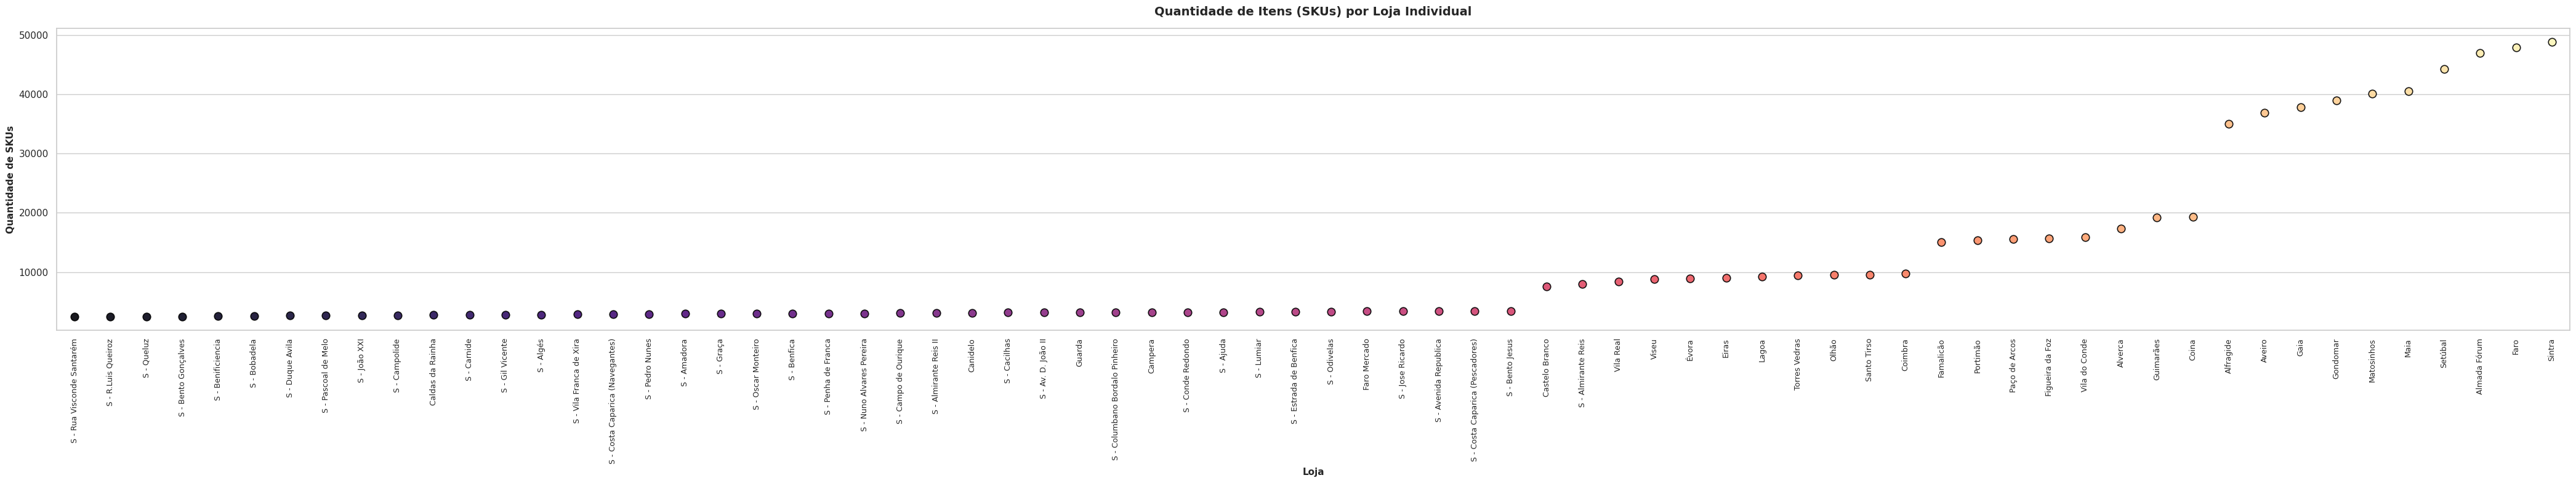

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar o estilo visual
sns.set_style("whitegrid")

# Ordenar o dataset de lojas de forma crescente para garantir uma visualização fluida
df_ordenado_skus = df_normalizado.sort_values(by='SKUS')

# Ajustar a largura do gráfico dinamicamente com base no número de lojas
num_lojas = len(df_normalizado)
largura_grafico = max(12, num_lojas * 0.6)

# Criar apenas um único gráfico (1x1) em vez de dois subplots
fig, ax = plt.subplots(figsize=(largura_grafico, 8))


# GRÁFICO: Quantidade de Itens (SKUs) por Loja (Eixo X = Lojas, Eixo Y = SKUs)

sns.stripplot(
    data=df_ordenado_skus, 
    x='LOJA',               # Lojas no Eixo X
    y='SKUS',               # SKUs no Eixo Y
    hue='LOJA', 
    palette='magma', 
    jitter=0, 
    size=9, 
    alpha=0.9, 
    edgecolor='black', 
    linewidth=1.2,
    legend=False,
    ax=ax                   # Direcionado para o ax único
)

ax.set_title('Quantidade de Itens (SKUs) por Loja Individual', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Loja', fontsize=11, fontweight='bold')
ax.set_ylabel('Quantidade de SKUs', fontsize=11, fontweight='bold')

# Rodar os nomes das lojas 90 graus para que fiquem totalmente legíveis
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=9)

plt.tight_layout()
plt.show()

#DASHBOARD ESTRUTURAL E OPERACIONAL: MAPEAMENTO FÍSICO DA REDE DE LOJAS

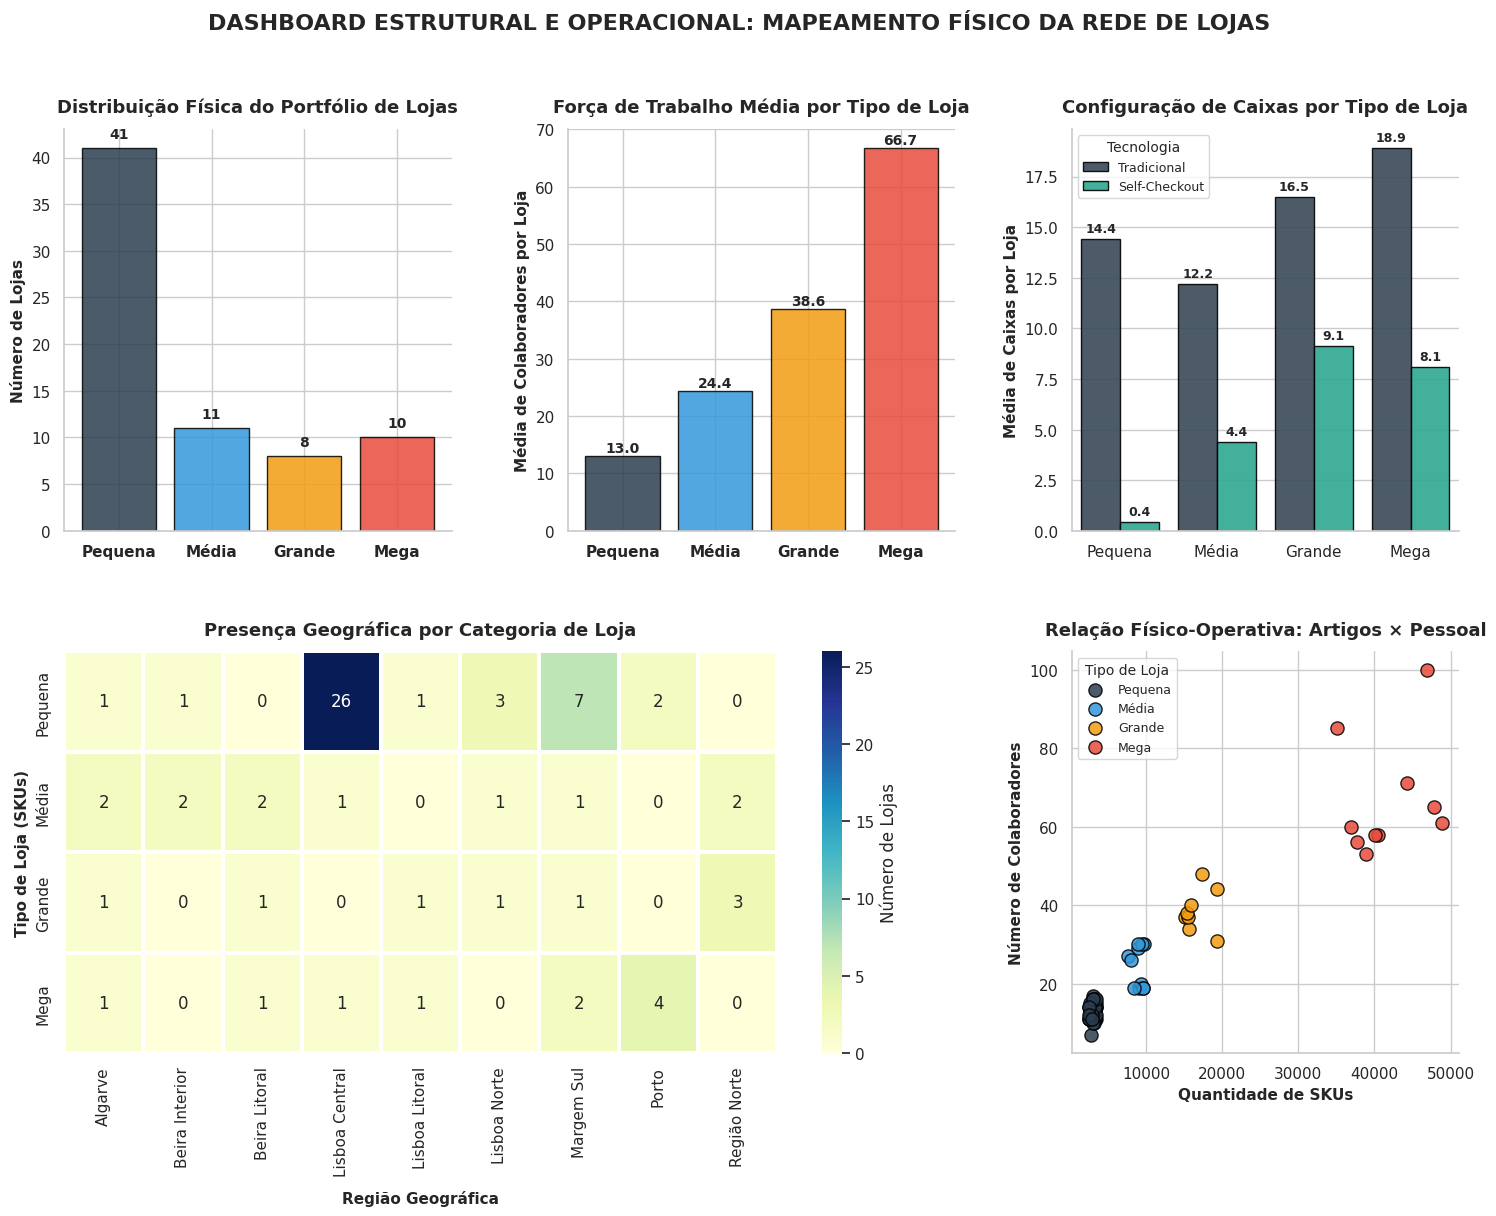

In [0]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# PARTE 1: CLASSIFICAÇÃO REALISTA POR PATAMARES DE SKUs

df_operacional = info_loja[['LOJA', 'REGIAO', 'N_COLABORADORES', 'SKUS', 
                            'CAIXAS_TRADICIONAIS', 'SELF_CHECKOUTS']].copy()

df_operacional['TOTAL_CAIXAS'] = df_operacional['CAIXAS_TRADICIONAIS'] + df_operacional['SELF_CHECKOUTS']

# Aplicar os limites visuais identificados no teu gráfico de dispersão
limites_skus = [0, 5000, 12000, 25000, float('inf')]
nomes_categorias = ['Pequena', 'Média', 'Grande', 'Mega']

df_operacional['TIPO_LOJA'] = pd.cut(
    df_operacional['SKUS'],
    bins=limites_skus,
    labels=nomes_categorias,
    right=False
)

# Preparar os dados de caixas para o formato longo (long-form) exigido para barras agrupadas
df_caixas_melt = df_operacional.melt(
    id_vars=['TIPO_LOJA'], 
    value_vars=['CAIXAS_TRADICIONAIS', 'SELF_CHECKOUTS'],
    var_name='TIPO_CAIXA', 
    value_name='QUANTIDADE'
)

# Formatar os nomes para a legenda do gráfico ficar mais bonita
df_caixas_melt['TIPO_CAIXA'] = df_caixas_melt['TIPO_CAIXA'].map({
    'CAIXAS_TRADICIONAIS': 'Tradicional',
    'SELF_CHECKOUTS': 'Self-Checkout'
})


# PARTE 2: GERADOR DO DASHBOARD OPERACIONAL ATUALIZADO

sns.set_style("whitegrid")
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Paletas de cores operacionais
colors_tipo = ['#2c3e50', '#3498db', '#f39c12', '#e74c3c'] 
colors_caixas = ['#34495e', '#1abc9c'] # Escuro para tradicional, Verde Água para tecnológico/self-checkout

# ----------------------------------------------------------------------------
# 1. Volumetria: Qtd de Lojas por Patamar de SKUs (Topo Esquerdo)
# ----------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
dist_tipos = df_operacional['TIPO_LOJA'].value_counts().reindex(nomes_categorias)
ax1.bar(range(len(dist_tipos)), dist_tipos.values, color=colors_tipo, edgecolor='black', alpha=0.85)
ax1.set_xticks(range(len(dist_tipos)))
ax1.set_xticklabels(dist_tipos.index, fontsize=11, fontweight='bold')
ax1.set_ylabel('Número de Lojas', fontsize=11, fontweight='bold')
ax1.set_title('Distribuição Física do Portfólio de Lojas', fontsize=13, fontweight='bold', pad=12)
for i, val in enumerate(dist_tipos.values):
    ax1.text(i, val + 0.8, str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
sns.despine(ax=ax1)

# ----------------------------------------------------------------------------
# 2. Força de Trabalho: Média de Colaboradores por Tipo (Topo Centro)
# ----------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
media_colab = df_operacional.groupby('TIPO_LOJA', observed=True)['N_COLABORADORES'].mean().reindex(nomes_categorias)
ax2.bar(range(len(media_colab)), media_colab.values, color=colors_tipo, edgecolor='black', alpha=0.85)
ax2.set_xticks(range(len(media_colab)))
ax2.set_xticklabels(media_colab.index, fontsize=11, fontweight='bold')
ax2.set_ylabel('Média de Colaboradores por Loja', fontsize=11, fontweight='bold')
ax2.set_title('Força de Trabalho Média por Tipo de Loja', fontsize=13, fontweight='bold', pad=12)
for i, val in enumerate(media_colab.values):
    ax2.text(i, val + 0.2, f"{val:.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
sns.despine(ax=ax2)

# ----------------------------------------------------------------------------
# 3. Capacidade de Atendimento: Caixas Lado a Lado (Topo Direito) - NOVO!
# ----------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
sns.barplot(
    data=df_caixas_melt,
    x='TIPO_LOJA',
    y='QUANTIDADE',
    hue='TIPO_CAIXA',
    order=nomes_categorias,
    palette=colors_caixas,
    edgecolor='black',
    alpha=0.9,
    errorbar=None, # Remove as barras de erro para deixar o visual limpo
    ax=ax3
)
ax3.set_xlabel('')
ax3.set_ylabel('Média de Caixas por Loja', fontsize=11, fontweight='bold')
ax3.set_title('Configuração de Caixas por Tipo de Loja', fontsize=13, fontweight='bold', pad=12)
ax3.legend(title="Tecnologia", fontsize=9, title_fontsize=10, loc='upper left')

# Adicionar os rótulos de valores diretamente por cima de cada barra individual
for container in ax3.containers:
    ax3.bar_label(container, fmt='%.1f', padding=3, fontsize=9, fontweight='bold')
sns.despine(ax=ax3)


# 4. Distribuição Geográfica: Onde estão as lojas de cada tipo? (Baixo, Esquerda/Centro)

ax4 = fig.add_subplot(gs[1, :2])
dist_regional = pd.crosstab(df_operacional['TIPO_LOJA'], df_operacional['REGIAO']).reindex(nomes_categorias)
sns.heatmap(dist_regional, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Número de Lojas'}, 
            linewidths=1.5, linecolor='white', ax=ax4)
ax4.set_xlabel('Região Geográfica', fontsize=11, fontweight='bold', labelpad=10)
ax4.set_ylabel('Tipo de Loja (SKUs)', fontsize=11, fontweight='bold')
ax4.set_title('Presença Geográfica por Categoria de Loja', fontsize=13, fontweight='bold', pad=12)


# 5. Relação Estrutural Físico-Operativa: SKUs vs. Colaboradores (Baixo Direito)

ax5 = fig.add_subplot(gs[1, 2])
for i, tipo in enumerate(nomes_categorias):
    mask = df_operacional['TIPO_LOJA'] == tipo
    ax5.scatter(
        df_operacional.loc[mask, 'SKUS'], 
        df_operacional.loc[mask, 'N_COLABORADORES'],
        label=tipo, 
        color=colors_tipo[i], 
        s=90, 
        alpha=0.85, 
        edgecolor='black', 
        linewidth=1
    )
ax5.set_xlabel('Quantidade de SKUs', fontsize=11, fontweight='bold')
ax5.set_ylabel('Número de Colaboradores', fontsize=11, fontweight='bold')
ax5.set_title('Relação Físico-Operativa: Artigos × Pessoal', fontsize=13, fontweight='bold', pad=12)
ax5.legend(title="Tipo de Loja", fontsize=9, title_fontsize=10)
sns.despine(ax=ax5)


plt.suptitle('DASHBOARD ESTRUTURAL E OPERACIONAL: MAPEAMENTO FÍSICO DA REDE DE LOJAS', 
             fontsize=16, fontweight='bold', y=0.98)

plt.show()

NOTA SOBRE AS VENDAS DURANTE A SEMANA:

_____

## QUESTÃO 3

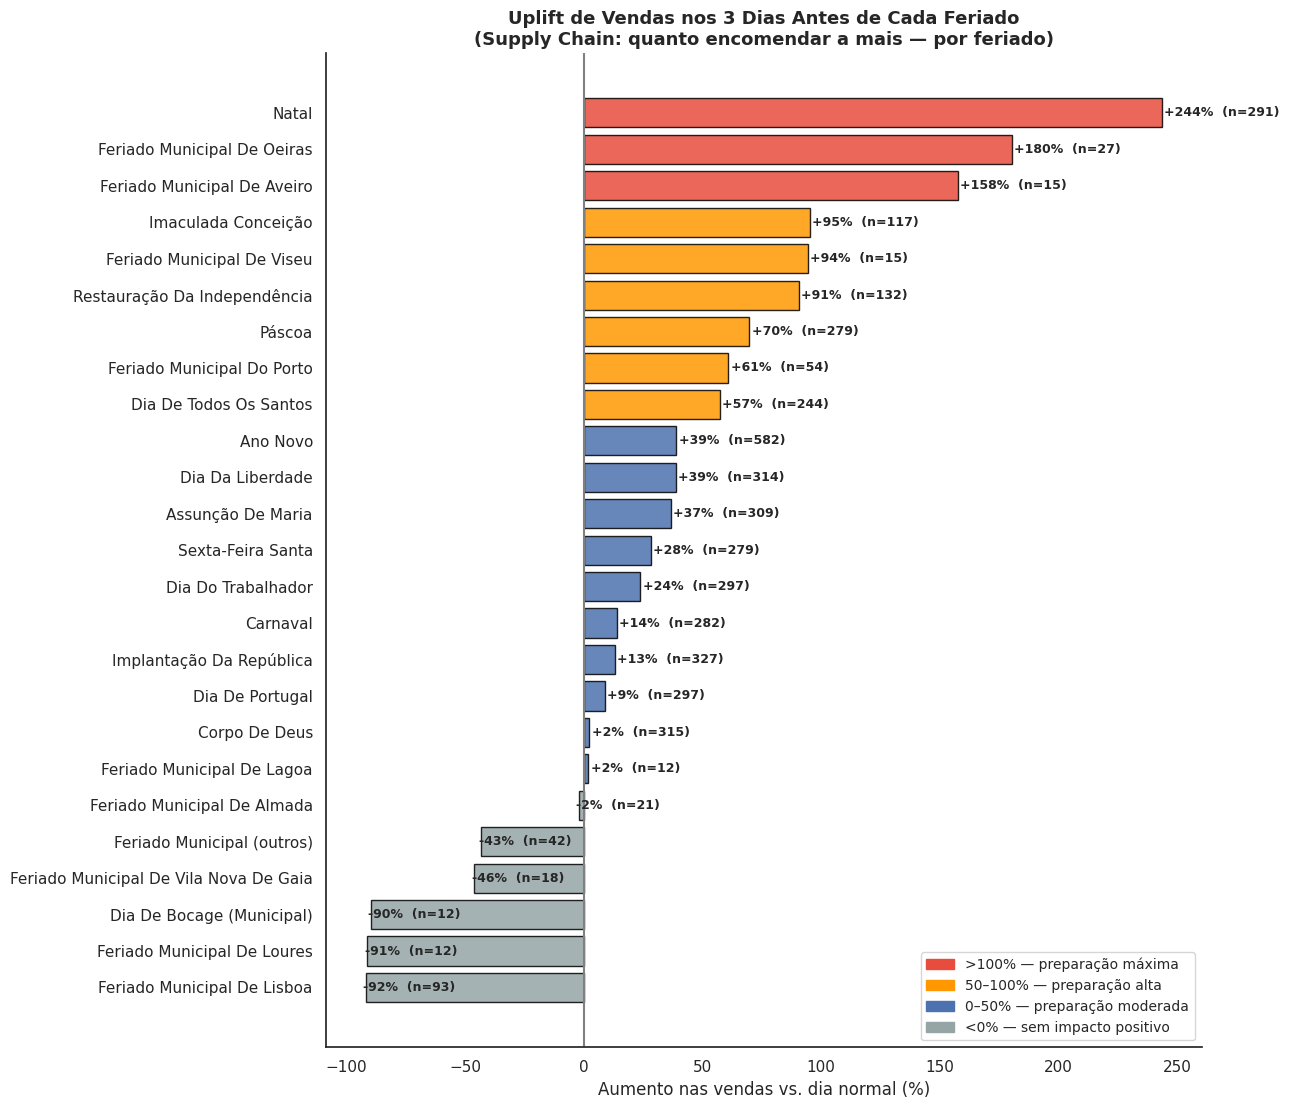

UPLIFT POR FERIADO (ordenado, com nº de observações):
  Natal                                   : +   244%  (n=291)
  Feriado Municipal De Oeiras             : +   180%  (n=27)
  Feriado Municipal De Aveiro             : +   158%  (n=15)
  Imaculada Conceição                     : +    95%  (n=117)
  Feriado Municipal De Viseu              : +    94%  (n=15)
  Restauração Da Independência            : +    91%  (n=132)
  Páscoa                                  : +    70%  (n=279)
  Feriado Municipal Do Porto              : +    61%  (n=54)
  Dia De Todos Os Santos                  : +    57%  (n=244)
  Ano Novo                                : +    39%  (n=582)
  Dia Da Liberdade                        : +    39%  (n=314)
  Assunção De Maria                       : +    37%  (n=309)
  Sexta-Feira Santa                       : +    28%  (n=279)
  Dia Do Trabalhador                      : +    24%  (n=297)
  Carnaval                                : +    14%  (n=282)
  Implantação Da Rep

In [0]:

# Montar df

df = unificado_pd.copy() if 'unificado_pd' in dir() else unificado.copy()
df['DATA'] = pd.to_datetime(df['DATA'])

# Read feriados from Unity Catalog table instead of CSV
feriados = spark.table("p2_retailcast.default.retail_cast_feriados").toPandas()
feriados['DATA'] = pd.to_datetime(feriados['DATA'])
feriados['DESCRICAO'] = feriados['DESCRICAO'].str.strip().str.title()

media_geral = df['TARGET_VENDAS_DIARIAS_EUR'].mean()


# Normalizar nomes duplicados / com erros de digitação

mapa_nomes = {
    'Dia De Ano Novo'          : 'Ano Novo',
    'Dia Ano Novo'             : 'Ano Novo',
    'Natal'                    : 'Natal',
    'Dia De Natal'             : 'Natal',
    'Natal 2023'               : 'Natal',
    'Pascoa'                   : 'Páscoa',
    'Dia Da Liberedade'        : 'Dia Da Liberdade',
    '1º Maio - Feriado Aberto' : 'Dia Do Trabalhador',
    'Todos Os Santos'          : 'Dia De Todos Os Santos',
    'Feriado Dia De Todos Os Santos': 'Dia De Todos Os Santos',
    'Dia De Todos Os Santos'   : 'Dia De Todos Os Santos',
    'Imaculada Conceição'      : 'Imaculada Conceição',
    'Dia Da Imaculada Conceição': 'Imaculada Conceição',
    'Feriado Cidade Aveiro'    : 'Feriado Municipal De Aveiro',
    'Feriado Cidade Viseu'     : 'Feriado Municipal De Viseu',
    'Municipal Do Porto (24 Jun)': 'Feriado Municipal Do Porto',
    'Municipal Barreiro (28 Jun)': 'Feriado Municipal Do Barreiro',
    'Municipal De Setubal (15/09)': 'Feriado Municipal De Setúbal',
    'Feriado Aberto'           : 'Feriado Municipal (outros)',
    'Feriado Municipal'        : 'Feriado Municipal (outros)',
    'Sexta -Feira Santa'       : 'Sexta-Feira Santa',
    'Passagem De Ano'          : 'Passagem De Ano',
}
feriados['DESCRICAO_NORM'] = feriados['DESCRICAO'].replace(mapa_nomes)


# Calcular uplift nos 3 dias antes de cada feriado
# (só feriados ABERTO, mínimo 10 observações para ser confiável)

fer_ab = feriados[feriados['TIPO'] == 'ABERTO'].copy()
resultados = []
for desc, grupo in fer_ab.groupby('DESCRICAO_NORM'):
    vendas_pre = []
    for _, r in grupo.iterrows():
        for delta in [-3, -2, -1]:
            d = r['DATA'] + pd.Timedelta(days=delta)
            sub = df[(df['FK_LOJA'] == r['FK_LOJA']) & (df['DATA'] == d)]
            if len(sub) > 0:
                vendas_pre.append(sub['TARGET_VENDAS_DIARIAS_EUR'].values[0])
    if len(vendas_pre) >= 10:   # mínimo 10 obs para ser confiável
        media_pre = np.mean(vendas_pre)
        uplift    = (media_pre / media_geral - 1) * 100
        resultados.append({
            'Feriado'   : desc,
            'n_obs'     : len(vendas_pre),
            'Uplift (%)': uplift
        })

res = pd.DataFrame(resultados).sort_values('Uplift (%)', ascending=True)


# Gráfico — todos os feriados com >= 10 observações

sns.set_style("white")
fig, ax = plt.subplots(figsize=(13, max(8, len(res)*0.45)))

cores = ['#e74c3c' if v > 100
         else '#FF9800' if v > 50
         else '#4c72b0' if v > 0
         else '#95a5a6'
         for v in res['Uplift (%)']]

bars = ax.barh(res['Feriado'], res['Uplift (%)'],
               color=cores, edgecolor='black', alpha=0.85)

ax.axvline(0, color='gray', linewidth=1.5)

for bar, (_, row) in zip(bars, res.iterrows()):
    val  = row['Uplift (%)']
    nobs = int(row['n_obs'])
    xpos = val + 1 if val >= 0 else val - 1
    ha   = 'left' if val >= 0 else 'right'
    label = f'+{val:.0f}%  (n={nobs})' if val >= 0 else f'{val:.0f}%  (n={nobs})'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=9, fontweight='bold')

ax.set_title('Uplift de Vendas nos 3 Dias Antes de Cada Feriado\n'
             '(Supply Chain: quanto encomendar a mais — por feriado)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Aumento nas vendas vs. dia normal (%)', fontsize=12)
ax.tick_params(axis='both', labelsize=11)

from matplotlib.patches import Patch
leg = [Patch(color='#e74c3c', label='>100% — preparação máxima'),
       Patch(color='#FF9800',  label='50–100% — preparação alta'),
       Patch(color='#4c72b0',  label='0–50% — preparação moderada'),
       Patch(color='#95a5a6',  label='<0% — sem impacto positivo')]
ax.legend(handles=leg, fontsize=10, loc='lower right')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


# Resumo textual com os números normalizados

print("="*65)
print("UPLIFT POR FERIADO (ordenado, com nº de observações):")
print("="*65)
for _, row in res.sort_values('Uplift (%)', ascending=False).iterrows():
    sinal = '+' if row['Uplift (%)'] >= 0 else ''
    print(f"  {row['Feriado']:40s}: {sinal}{row['Uplift (%)']:>6.0f}%  (n={int(row['n_obs'])})")

#índice de venda por dia da semana

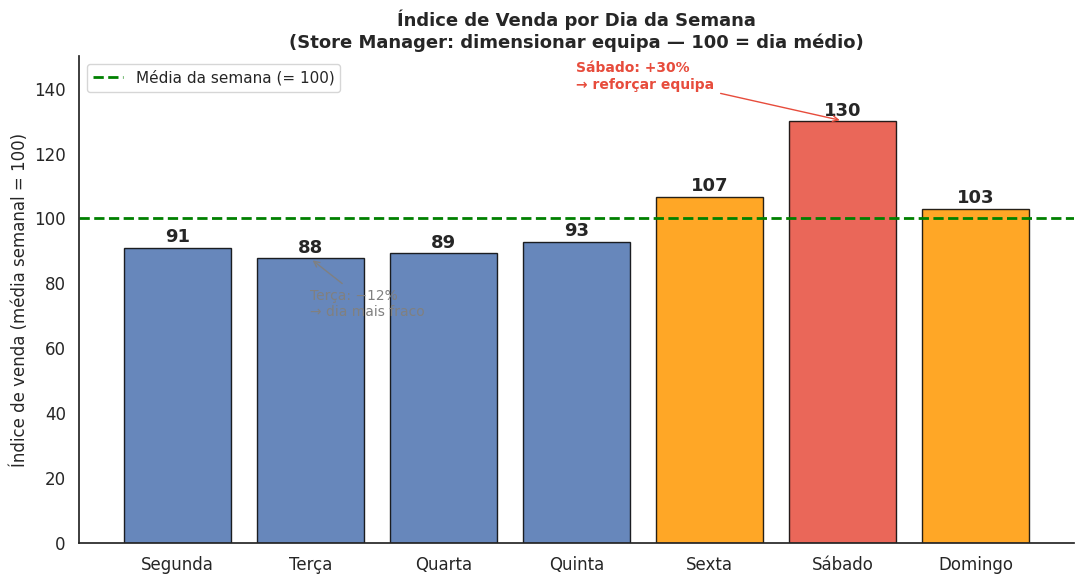


INSIGHT Store Manager:
  Sábado: índice 130 → 30% acima do dia médio → precisa de 30% mais equipa
  Terça:  índice  88 → 12% abaixo → pode reduzir escala
  ATENÇÃO: regra válida para lojas grandes (LG3/LG4).
  Lojas pequenas (LG1/LG2) têm pico na Terça — regra oposta!


In [0]:



# VIZ 2 — STORE MANAGER: índice de venda por dia da semana

# Prepare data
if 'unificado_pd' in dir():
    df = unificado_pd.copy()
elif 'unificado' in dir():
    df = unificado.copy()
else:
    raise NameError(
        "Neither 'unificado_pd' nor 'unificado' is defined. Please run the data loading cells first:\n"
        "  1. Run Cell 6 to load 'unificado' from Unity Catalog\n"
        "  2. Then re-run this cell."
    )

# Ensure NOME_DIA exists
df['DATA'] = pd.to_datetime(df['DATA'])
if 'NOME_DIA' not in df.columns:
    df['NOME_DIA'] = df['DATA'].dt.day_name()

# Calculate overall mean
media_geral = df['TARGET_VENDAS_DIARIAS_EUR'].mean()
ordem_en = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ordem_pt = ['Segunda','Terça','Quarta','Quinta','Sexta','Sábado','Domingo']
sem = df.groupby('NOME_DIA')['TARGET_VENDAS_DIARIAS_EUR'].mean().reindex(ordem_en)
sem.index = ordem_pt
indice = (sem / media_geral * 100).round(1)
 
fig, ax = plt.subplots(figsize=(11, 6))
cores_d = ['#e74c3c' if v == indice.max()
           else '#FF9800' if v > 100
           else '#4c72b0' for v in indice]
bars = ax.bar(indice.index, indice.values, color=cores_d, edgecolor='black', alpha=0.85)
ax.axhline(100, color='green', linestyle='--', linewidth=2, label='Média da semana (= 100)')
for bar, val in zip(bars, indice.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{val:.0f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_title('Índice de Venda por Dia da Semana\n(Store Manager: dimensionar equipa — 100 = dia médio)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Índice de venda (média semanal = 100)', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.tick_params(axis='both', labelsize=12)
ax.set_ylim(0, 150)
ax.legend(fontsize=11)
 
# anotacoes de accao
ax.annotate('Sábado: +30%\n→ reforçar equipa',
            xy=('Sábado', 130.1), xytext=('Quinta', 140),
            arrowprops=dict(arrowstyle='->', color='#e74c3c'),
            fontsize=10, color='#e74c3c', fontweight='bold')
ax.annotate('Terça: −12%\n→ dia mais fraco',
            xy=('Terça', 87.6), xytext=('Terça', 70),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='gray')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()
 
print("\nINSIGHT Store Manager:")
print("  Sábado: índice 130 → 30% acima do dia médio → precisa de 30% mais equipa")
print("  Terça:  índice  88 → 12% abaixo → pode reduzir escala")
print("  ATENÇÃO: regra válida para lojas grandes (LG3/LG4).")
print("  Lojas pequenas (LG1/LG2) têm pico na Terça — regra oposta!")

#quais lojas fogem ao padrão?

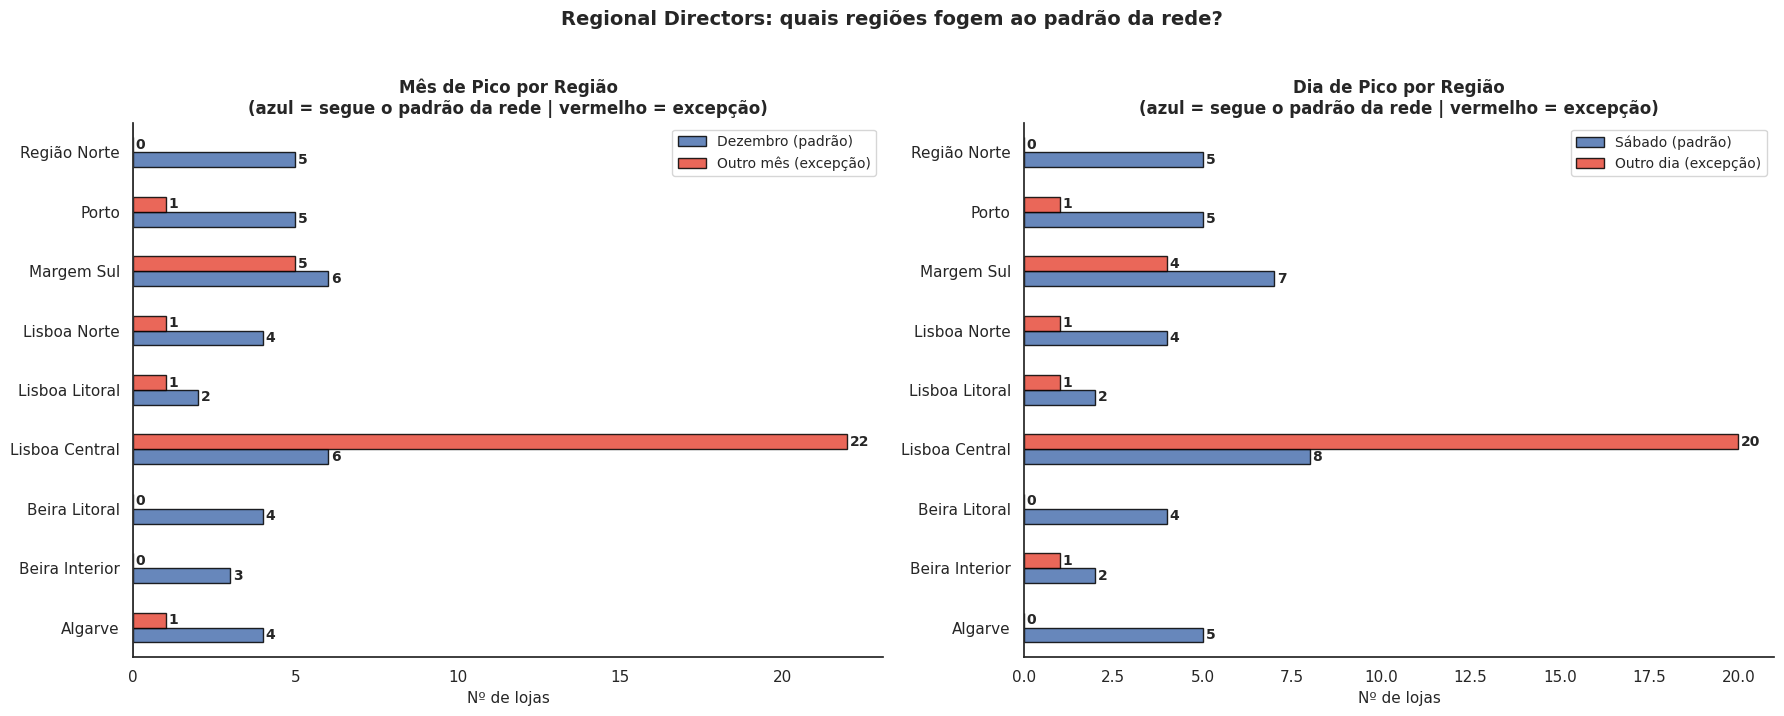


INSIGHT Regional Directors:
  Lisboa Central é a região mais atípica:
    → 22 das 28 lojas têm pico FORA de Dezembro
    → 20 das 28 lojas têm pico num dia que NÃO é Sábado
  Todas as outras regiões seguem o padrão da rede.
  → Lisboa Central precisa de uma estratégia de planeamento própria.


In [0]:


# VIZ 3 — REGIONAL DIRECTORS: quais lojas fogem ao padrão?


mp = df.groupby(['FK_LOJA','MES'])['TARGET_VENDAS_DIARIAS_EUR'].mean().reset_index()
pico_mes = mp.loc[mp.groupby('FK_LOJA')['TARGET_VENDAS_DIARIAS_EUR'].idxmax()][['FK_LOJA','MES']]
pico_mes.columns = ['FK_LOJA','MES_PICO']
 
dp = df.groupby(['FK_LOJA','NOME_DIA'])['TARGET_VENDAS_DIARIAS_EUR'].mean().reset_index()
pico_dia = dp.loc[dp.groupby('FK_LOJA')['TARGET_VENDAS_DIARIAS_EUR'].idxmax()][['FK_LOJA','NOME_DIA']]
pico_dia.columns = ['FK_LOJA','DIA_PICO']
 
perfil = (info_loja[['FK_LOJA','REGIAO']]
          .merge(pico_mes, on='FK_LOJA')
          .merge(pico_dia, on='FK_LOJA'))
perfil['MES_LABEL'] = np.where(perfil['MES_PICO']==12,'Dez\n(padrão)','Outro\n(excepção)')
perfil['DIA_LABEL'] = np.where(perfil['DIA_PICO']=='Saturday','Sáb\n(padrão)','Outro\n(excepção)')
 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
 
# painel A — mes de pico por regiao
tab_m = perfil.groupby(['REGIAO','MES_LABEL']).size().unstack(fill_value=0)
tab_m = tab_m.reindex(columns=['Dez\n(padrão)','Outro\n(excepção)'])
tab_m.plot(kind='barh', ax=axes[0], color=['#4c72b0','#e74c3c'],
           edgecolor='black', alpha=0.85)
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=10, fontweight='bold', padding=2)
axes[0].set_title('Mês de Pico por Região\n(azul = segue o padrão da rede | vermelho = excepção)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nº de lojas', fontsize=11)
axes[0].set_ylabel(''); axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(['Dezembro (padrão)','Outro mês (excepção)'], fontsize=10)
axes[0].axvline(0, color='gray', linewidth=0.5)
sns.despine(ax=axes[0])
 
# painel B — dia de pico por regiao
tab_d = perfil.groupby(['REGIAO','DIA_LABEL']).size().unstack(fill_value=0)
tab_d = tab_d.reindex(columns=['Sáb\n(padrão)','Outro\n(excepção)'])
tab_d.plot(kind='barh', ax=axes[1], color=['#4c72b0','#e74c3c'],
           edgecolor='black', alpha=0.85)
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=10, fontweight='bold', padding=2)
axes[1].set_title('Dia de Pico por Região\n(azul = segue o padrão da rede | vermelho = excepção)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nº de lojas', fontsize=11)
axes[1].set_ylabel(''); axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(['Sábado (padrão)','Outro dia (excepção)'], fontsize=10)
sns.despine(ax=axes[1])
 
plt.suptitle('Regional Directors: quais regiões fogem ao padrão da rede?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
 
print("\nINSIGHT Regional Directors:")
print("  Lisboa Central é a região mais atípica:")
print("    → 22 das 28 lojas têm pico FORA de Dezembro")
print("    → 20 das 28 lojas têm pico num dia que NÃO é Sábado")
print("  Todas as outras regiões seguem o padrão da rede.")
print("  → Lisboa Central precisa de uma estratégia de planeamento própria.")
 

#Venda Média por Dia da Semana

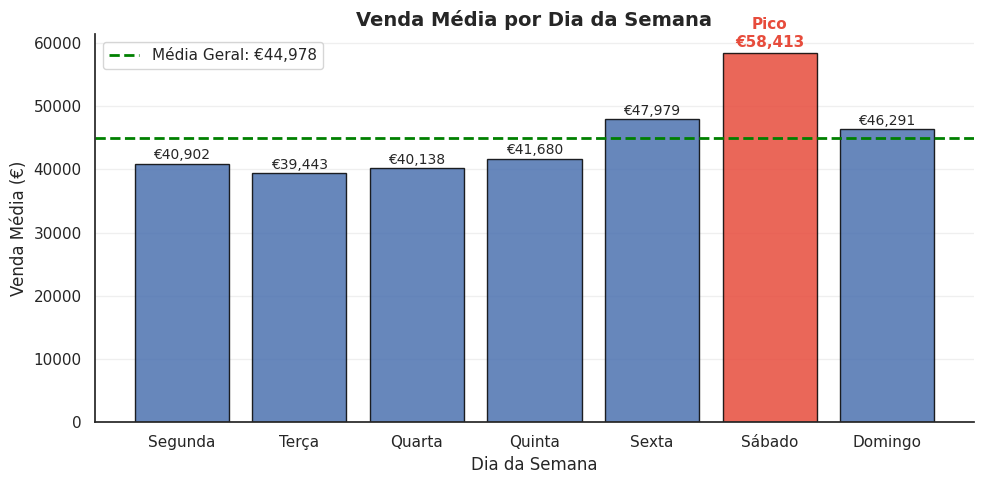

In [0]:

# Preparar dados
if 'unificado_pd' in dir():
    df = unificado_pd.copy()
elif 'unificado' in dir():
    df = unificado.copy()
else:
    raise NameError(
        "Neither 'unificado_pd' nor 'unificado' is defined. Please run the data loading cells first:\n"
        "  1. Run Cell 6 to load 'unificado' from Unity Catalog\n"
        "  2. Optionally run Cell 123 to create 'unificado_pd'\n"
        "  3. Then re-run this cell."
    )

# Garantir que DATA é datetime
df['DATA'] = pd.to_datetime(df['DATA'])

# Calcular venda média por dia da semana usando o NOME real da data
# (evita qualquer confusão de convenção 0=seg vs 1=seg no DIA_SEMANA)
ordem_en = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_semana_labels = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

vendas_dia = (df.groupby(df['DATA'].dt.day_name())['TARGET_VENDAS_DIARIAS_EUR']
                .mean()
                .reindex(ordem_en))
vendas_dia.index = dias_semana_labels

# Identificar dia de pico
dia_pico = vendas_dia.idxmax()
valor_pico = vendas_dia.max()
media_geral = vendas_dia.mean()

# Gráfico de barras
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(vendas_dia.index, vendas_dia.values,
              color=['#4c72b0' if dia != dia_pico else '#e74c3c' for dia in vendas_dia.index],
              edgecolor='black', alpha=0.85)
ax.axhline(media_geral, color='green', linestyle='--', linewidth=2,
           label=f'Média Geral: €{media_geral:,.0f}')
ax.set_title('Venda Média por Dia da Semana', fontsize=14, fontweight='bold')
ax.set_xlabel('Dia da Semana', fontsize=12)
ax.set_ylabel('Venda Média (€)', fontsize=12)
for i, bar in enumerate(bars):
    height = bar.get_height()
    if vendas_dia.index[i] == dia_pico:
        ax.text(bar.get_x() + bar.get_width()/2., height + 500, f'Pico\n€{height:,.0f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='#e74c3c')
    else:
        ax.text(bar.get_x() + bar.get_width()/2., height + 200, f'€{height:,.0f}',
                ha='center', va='bottom', fontsize=10)
ax.legend()
ax.grid(axis='y', alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

#Distribuição de picos entre as 70 lojas

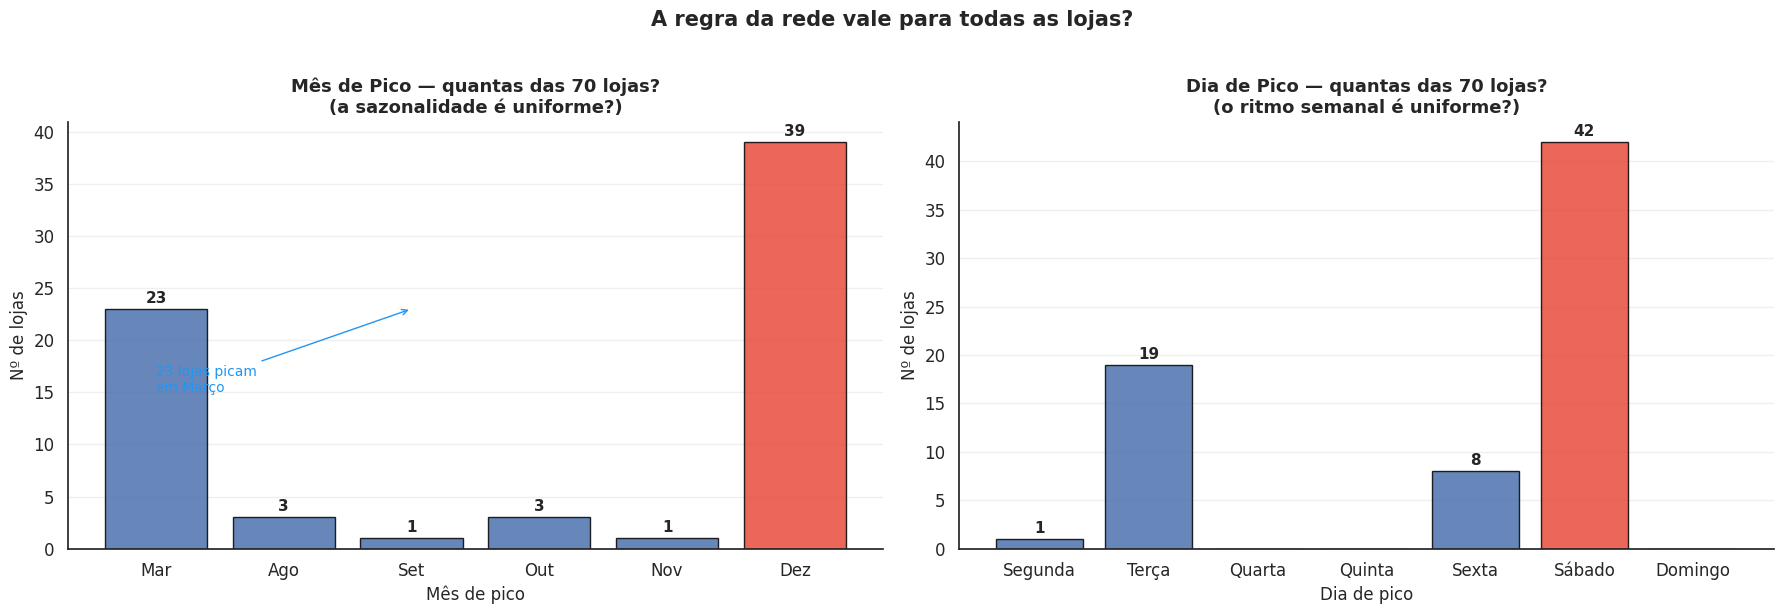

INSIGHT:
  Mês: 39 lojas picam em Dezembro, mas 23 picam em Março.
  Dia: 42 lojas picam no Sábado, mas 19 picam na Terça.
  → Não há uma regra única — o planeamento deve respeitar o perfil de cada loja.


In [0]:

# Distribuição de picos entre as 70 lojas

# Ensure NOME_DIA exists
df['DATA'] = pd.to_datetime(df['DATA'])
if 'NOME_DIA' not in df.columns:
    df['NOME_DIA'] = df['DATA'].dt.day_name()

ordem_en = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ordem_pt = ['Segunda','Terça','Quarta','Quinta','Sexta','Sábado','Domingo']
meses_pt = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
            7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}

# mês de pico por loja
mp = df.groupby(['FK_LOJA','MES'])['TARGET_VENDAS_DIARIAS_EUR'].mean().reset_index()
pico_mes = mp.loc[mp.groupby('FK_LOJA')['TARGET_VENDAS_DIARIAS_EUR'].idxmax()]
vc_m = pico_mes['MES'].value_counts().sort_index()

# dia de pico por loja
dp = df.groupby(['FK_LOJA','NOME_DIA'])['TARGET_VENDAS_DIARIAS_EUR'].mean().reset_index()
pico_dia = dp.loc[dp.groupby('FK_LOJA')['TARGET_VENDAS_DIARIAS_EUR'].idxmax()]
vc_d = pico_dia['NOME_DIA'].value_counts().reindex(ordem_en).fillna(0).astype(int)
vc_d.index = ordem_pt

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.set_style("white")

# painel A — mês de pico
cores_m = ['#e74c3c' if m == vc_m.idxmax() else '#4c72b0' for m in vc_m.index]
bars_m = axes[0].bar([meses_pt[m] for m in vc_m.index], vc_m.values,
                      color=cores_m, edgecolor='black', alpha=0.85)
for bar, val in zip(bars_m, vc_m.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Mês de Pico — quantas das 70 lojas?\n(a sazonalidade é uniforme?)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mês de pico', fontsize=12)
axes[0].set_ylabel('Nº de lojas', fontsize=12)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].grid(axis='y', alpha=0.3)
sns.despine(ax=axes[0])

# anotação explicativa
axes[0].annotate('39 lojas picam\nem Dezembro',
                 xy=(list(meses_pt.values()).index('Dez'), 39),
                 xytext=(4, 30),
                 textcoords=('data','data'),
                 arrowprops=dict(arrowstyle='->', color='#e74c3c'),
                 fontsize=10, color='#e74c3c', fontweight='bold')
axes[0].annotate('23 lojas picam\nem Março',
                 xy=(list(meses_pt.values()).index('Mar'), 23),
                 xytext=(0, 15),
                 textcoords=('data','data'),
                 arrowprops=dict(arrowstyle='->', color='#2196F3'),
                 fontsize=10, color='#2196F3')

# painel B — dia de pico
cores_d = ['#e74c3c' if d == vc_d.idxmax() else '#4c72b0' for d in vc_d.index]
bars_d = axes[1].bar(vc_d.index, vc_d.values,
                      color=cores_d, edgecolor='black', alpha=0.85)
for bar, val in zip(bars_d, vc_d.values):
    if val > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                     str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Dia de Pico — quantas das 70 lojas?\n(o ritmo semanal é uniforme?)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Dia de pico', fontsize=12)
axes[1].set_ylabel('Nº de lojas', fontsize=12)
axes[1].tick_params(axis='both', labelsize=12)
axes[1].grid(axis='y', alpha=0.3)
sns.despine(ax=axes[1])

plt.suptitle('A regra da rede vale para todas as lojas?',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("INSIGHT:")
print(f"  Mês: 39 lojas picam em Dezembro, mas 23 picam em Março.")
print(f"  Dia: 42 lojas picam no Sábado, mas 19 picam na Terça.")
print(f"  → Não há uma regra única — o planeamento deve respeitar o perfil de cada loja.")


#Padrão em torno de feriados

In [0]:

#Padrão em torno de feriados
# Pergunta: "o feriado explica o pico sazonal?"

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure dates are datetime
feriados['DATA'] = pd.to_datetime(feriados['DATA'])
df['DATA'] = pd.to_datetime(df['DATA'])

fer_ab = feriados[feriados['TIPO'] == 'ABERTO'][['FK_LOJA','DATA']].copy()
media_normal = df['TARGET_VENDAS_DIARIAS_EUR'].mean()

janela = []
for _, r in fer_ab.iterrows():
    for delta in range(-7, 8):
        d = r['DATA'] + pd.Timedelta(days=delta)
        sub = df[(df['FK_LOJA'] == r['FK_LOJA']) & (df['DATA'] == d)]
        if len(sub) > 0:
            janela.append({'delta': delta, 'VALOR': sub['TARGET_VENDAS_DIARIAS_EUR'].values[0]})

jan = pd.DataFrame(janela)
media_jan = jan.groupby('delta')['VALOR'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
sns.set_style("white")

# zona de pico (antes do feriado)
ax.axvspan(-4, -1, alpha=0.15, color='gold', label='Zona de pico pré-feriado')
ax.axhline(media_normal, color='#2ecc71', linestyle='--', linewidth=2,
           label=f'Média dia normal (€{media_normal:,.0f})')
ax.axvline(0, color='#e74c3c', linestyle='--', linewidth=2, label='Dia do feriado')

ax.plot(media_jan.index, media_jan.values, marker='o', color='#2196F3',
        linewidth=2.5, markersize=8, label='Venda média')

# anotar os pontos-chave
for delta, val in media_jan.items():
    if delta in [-2, -1, 0, 1]:
        ax.annotate(f'€{val/1000:.0f}k',
                    xy=(delta, val),
                    xytext=(0, 12),
                    textcoords='offset points',
                    ha='center', fontsize=10,
                    fontweight='bold',
                    color='#2196F3')

# destacar o pico máximo
pico_delta = media_jan.idxmin() * -1
pico_val = media_jan.max()
pico_d = media_jan.idxmax()
ax.annotate(f'Pico: €{pico_val/1000:.0f}k\n({abs(pico_d)} dias antes)',
            xy=(pico_d, pico_val),
            xytext=(pico_d + 1.5, pico_val - 3000),
            arrowprops=dict(arrowstyle='->', color='#e74c3c'),
            fontsize=11, color='#e74c3c', fontweight='bold')

ax.set_title('Padrão de Vendas em Torno de Feriados\n(as vendas sobem ANTES do feriado)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Dias em relação ao feriado\n(negativo = antes, positivo = depois)',
              fontsize=12)
ax.set_ylabel('Venda Média (€)', fontsize=12)
ax.tick_params(axis='both', labelsize=12)
ax.set_xticks(range(-7, 8))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

pico_antes = media_jan[media_jan.index < 0].max()
uplift = ((pico_antes / media_normal) - 1) * 100
print(f"\nINSIGHT:")
print(f"  Pico pré-feriado: €{pico_antes:,.0f} ({uplift:.0f}% acima da média normal)")
print(f"  A venda sobe nos 3-4 dias ANTES do feriado, não no próprio dia.")
print(f"  → Antecipar stock 4 dias antes de cada feriado.")

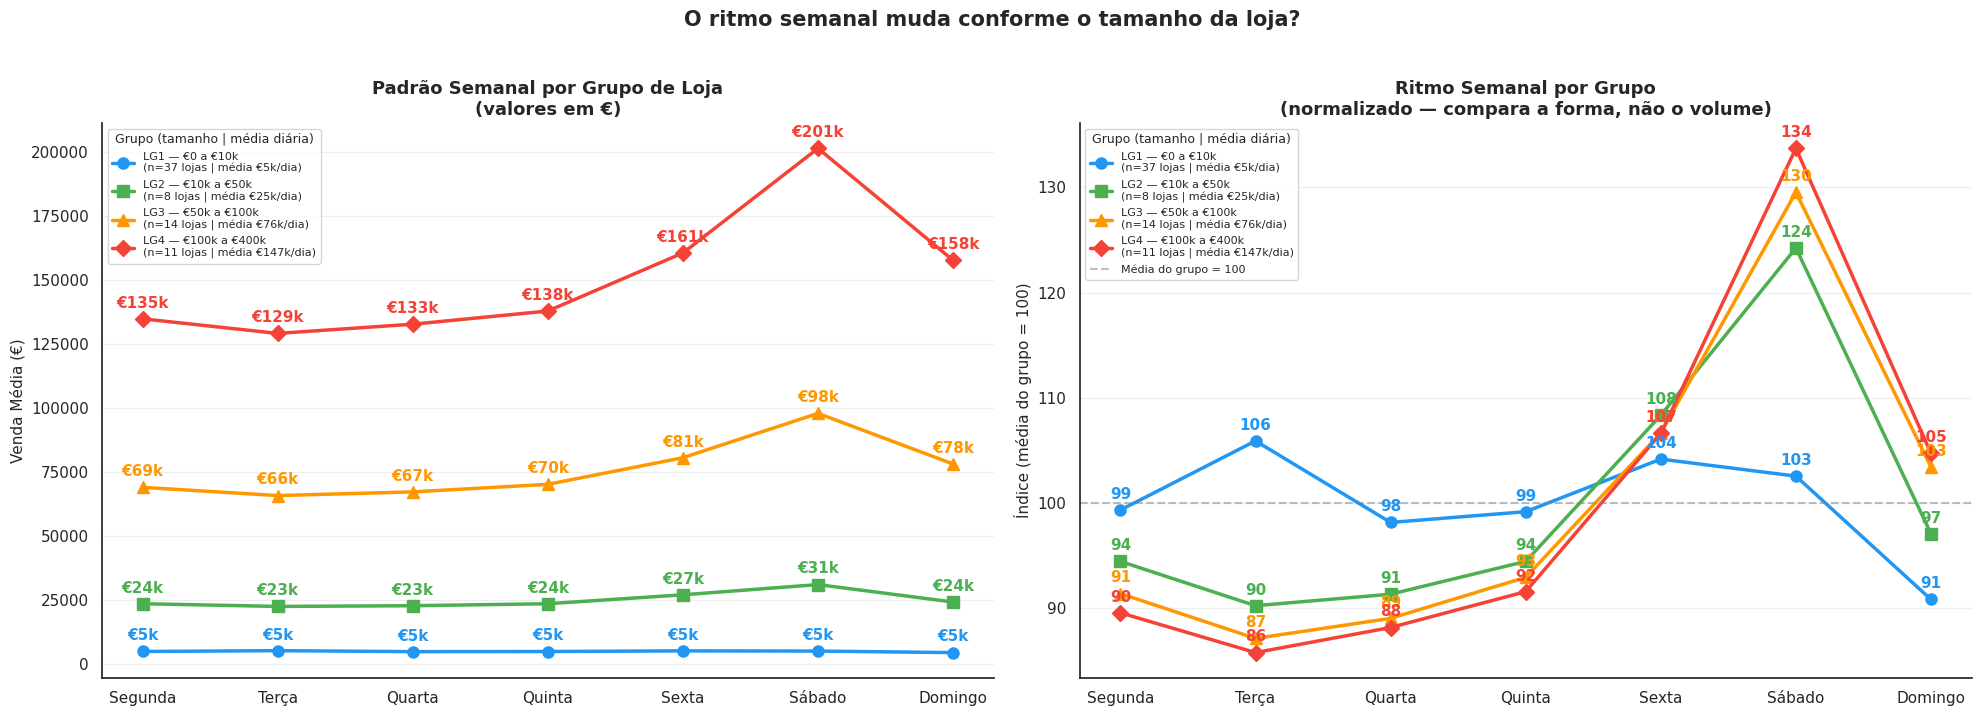

RESUMO — Dia de pico por grupo:
  LG1 — €0 a €10k           | n=37 lojas | média €   5k/dia | pico: Terça (€5k)
  LG2 — €10k a €50k         | n= 8 lojas | média €  25k/dia | pico: Sábado (€31k)
  LG3 — €50k a €100k        | n=14 lojas | média €  76k/dia | pico: Sábado (€98k)
  LG4 — €100k a €400k       | n=11 lojas | média € 147k/dia | pico: Sábado (€201k)


In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------
# Montar df
# -------------------------------------------------------
if 'unificado_pd' in dir():
    df = unificado_pd.copy()
elif 'unificado' in dir():
    df = unificado.copy()
else:
    raise NameError(
        "Neither 'unificado_pd' nor 'unificado' is defined. Please run the data loading cells first:\n"
        "  1. Run Cell 6 to load 'unificado' from Unity Catalog\n"
        "  2. Optionally run Cell 123 to create 'unificado_pd'\n"
        "  3. Then re-run this cell."
    )
df['DATA']     = pd.to_datetime(df['DATA'])
df['NOME_DIA'] = df['DATA'].dt.day_name()


# Classificar lojas em grupos por faixa de venda média diária

media_loja = df.groupby('FK_LOJA')['TARGET_VENDAS_DIARIAS_EUR'].mean()

faixas = [0, 10000, 50000, 100000, 400000]
nomes  = ['LG1 — €0 a €10k', 'LG2 — €10k a €50k',
          'LG3 — €50k a €100k', 'LG4 — €100k a €400k']

grupos = media_loja.reset_index()
grupos.columns = ['FK_LOJA', 'MEDIA_LOJA']
grupos['GRUPO'] = pd.cut(grupos['MEDIA_LOJA'], bins=faixas, labels=nomes)

# média real de cada grupo (para a legenda)
media_grupo = grupos.groupby('GRUPO', observed=True)['MEDIA_LOJA'].mean()
n_grupo     = grupos.groupby('GRUPO', observed=True)['FK_LOJA'].count()

df = df.merge(grupos[['FK_LOJA','GRUPO']], on='FK_LOJA', how='left')


# Padrão semanal por grupo

ordem_en = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ordem_pt = ['Segunda','Terça','Quarta','Quinta','Sexta','Sábado','Domingo']

padrao = (df.groupby(['GRUPO','NOME_DIA'], observed=True)['TARGET_VENDAS_DIARIAS_EUR']
            .mean()
            .unstack()
            .reindex(columns=ordem_en))
padrao.columns = ordem_pt

# normalizado (para comparar a FORMA entre grupos de escalas muito diferentes)
padrao_norm = padrao.div(padrao.mean(axis=1), axis=0) * 100


# Gráfico — dois painéis

cores     = ['#2196F3','#4CAF50','#FF9800','#F44336']
marcadores = ['o','s','^','D']

sns.set_style("white")
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for g, cor, mk in zip(nomes, cores, marcadores):
    media_g = media_grupo[g]
    n_g     = n_grupo[g]
    label   = f"{g}\n(n={n_g} lojas | média €{int(round(media_g/1000)):d}k/dia)"

    # Painel A — valores absolutos com anotação em cada ponto
    vals = padrao.loc[g]
    axes[0].plot(ordem_pt, vals, marker=mk, color=cor,
                 label=label, linewidth=2.5, markersize=8)
    for dia, val in zip(ordem_pt, vals):
        val_k = int(round(val/1000))
        axes[0].annotate(f"€{val_k}k",
                         xy=(dia, val),
                         xytext=(0, 8),
                         textcoords='offset points',
                         ha='center', fontsize=11, fontweight='bold', color=cor)

    # Painel B — normalizado
    vals_n = padrao_norm.loc[g]
    axes[1].plot(ordem_pt, vals_n, marker=mk, color=cor,
                 label=label, linewidth=2.5, markersize=8)
    for dia, val in zip(ordem_pt, vals_n):
        axes[1].annotate(f"{int(round(val))}",
                         xy=(dia, val),
                         xytext=(0, 8),
                         textcoords='offset points',
                         ha='center', fontsize=11, fontweight='bold', color=cor)

# Painel A
axes[0].set_title('Padrão Semanal por Grupo de Loja\n(valores em €)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Venda Média (€)', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_xticklabels(ordem_pt, fontsize=11)
axes[0].tick_params(axis='y', labelsize=11)
axes[0].legend(title='Grupo (tamanho | média diária)',
               fontsize=8, title_fontsize=9, loc='upper left')
axes[0].grid(axis='y', alpha=0.3)
sns.despine(ax=axes[0])

# Painel B
axes[1].axhline(100, ls='--', color='gray', alpha=0.5, label='Média do grupo = 100')
axes[1].set_title('Ritmo Semanal por Grupo\n(normalizado — compara a forma, não o volume)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Índice (média do grupo = 100)', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_xticklabels(ordem_pt, fontsize=11)
axes[1].tick_params(axis='y', labelsize=11)
axes[1].legend(title='Grupo (tamanho | média diária)',
               fontsize=8, title_fontsize=9, loc='upper left')
axes[1].grid(axis='y', alpha=0.3)
sns.despine(ax=axes[1])

plt.suptitle('O ritmo semanal muda conforme o tamanho da loja?',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Resumo textual

print("="*65)
print("RESUMO — Dia de pico por grupo:")
print("="*65)
for g in nomes:
    pico = padrao.loc[g].idxmax()
    val  = padrao.loc[g].max()
    n_g  = n_grupo[g]
    mg   = media_grupo[g]
    print(f"  {g:25s} | n={n_g:2d} lojas | média €{int(round(mg/1000)):>4d}k/dia | pico: {pico} (€{int(round(val/1000)):d}k)")

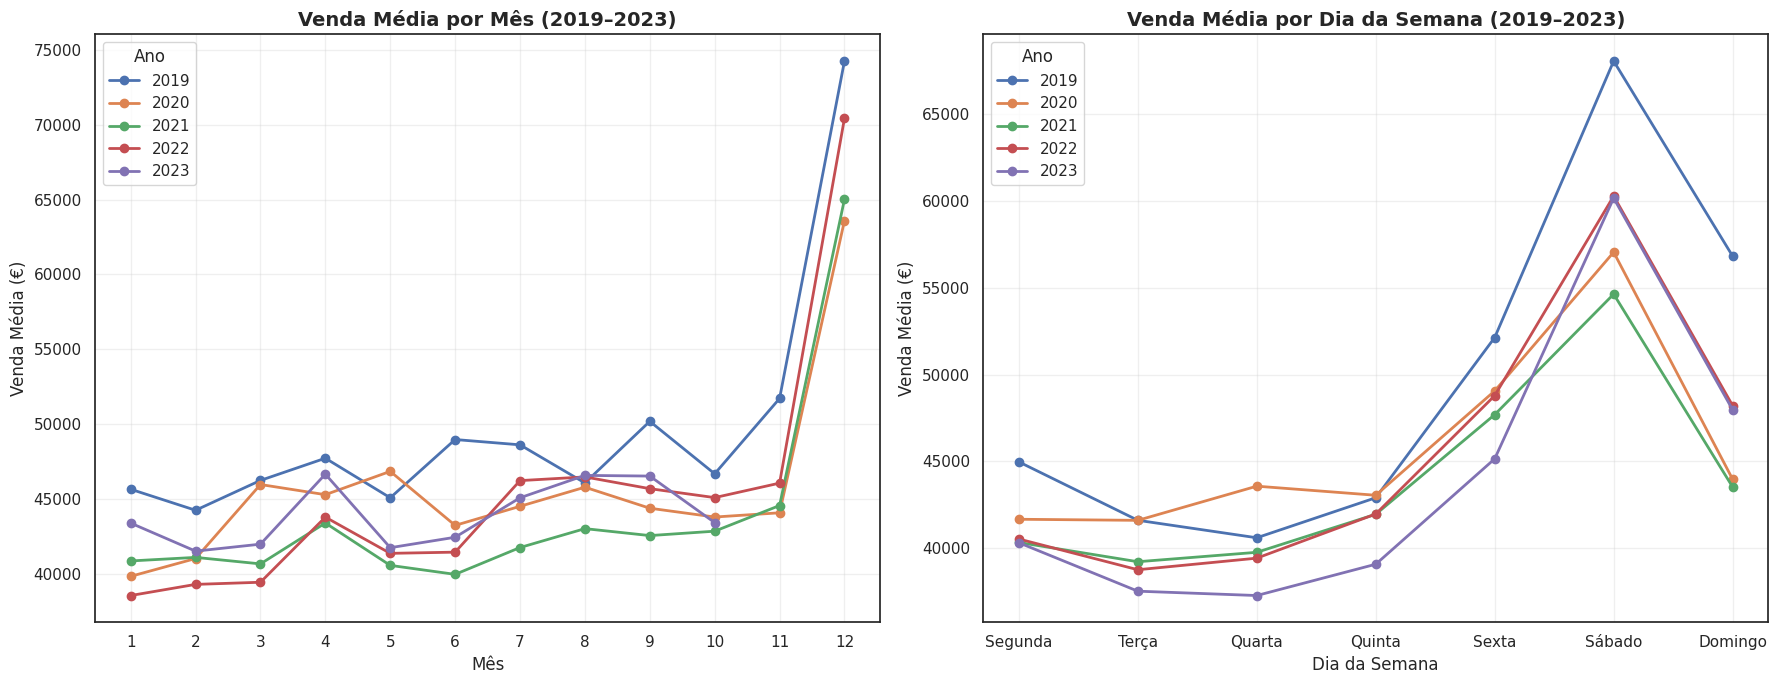

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Garantir colunas de ano, mês e nome do dia
if 'unificado_pd' in dir():
    df = unificado_pd.copy()
elif 'unificado' in dir():
    df = unificado.copy()
else:
    raise NameError(
        "Neither 'unificado_pd' nor 'unificado' is defined. Please run the data loading cells first:\n"
        "  1. Run Cell 6 to load 'unificado' from Unity Catalog\n"
        "  2. Optionally run Cell 123 to create 'unificado_pd'\n"
        "  3. Then re-run this cell."
    )
df['DATA'] = pd.to_datetime(df['DATA'])
df['ANO'] = df['DATA'].dt.year
df['MES'] = df['DATA'].dt.month
df['NOME_DIA'] = df['DATA'].dt.day_name()   # nome real da data (à prova de convenção)

# Filtrar anos de interesse
anos = list(range(2019, 2024))
df = df[df['ANO'].isin(anos)]

# Ordem dos dias (nome em inglês vindo da data -> rótulo em português)
ordem_en = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ordem_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

# Venda média por mês/ano
vendas_mes_ano = df.groupby(['ANO', 'MES'])['TARGET_VENDAS_DIARIAS_EUR'].mean().unstack()

# Venda média por dia da semana/ano (usando o nome real, não o número)
vendas_dia_ano = df.groupby(['ANO', 'NOME_DIA'])['TARGET_VENDAS_DIARIAS_EUR'].mean().unstack()
vendas_dia_ano = vendas_dia_ano.reindex(columns=ordem_en)
vendas_dia_ano.columns = ordem_pt

sns.set_style("white")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Venda média por mês (linhas por ano)
for ano in anos:
    axes[0].plot(range(1, 13), vendas_mes_ano.loc[ano], marker='o', label=str(ano), linewidth=2)
axes[0].set_xticks(range(1, 13))
axes[0].set_xlabel('Mês', fontsize=12)
axes[0].set_ylabel('Venda Média (€)', fontsize=12)
axes[0].set_title('Venda Média por Mês (2019–2023)', fontsize=14, fontweight='bold')
axes[0].legend(title='Ano')
axes[0].grid(alpha=0.3)

# Gráfico 2: Venda média por dia da semana (linhas por ano)
for ano in anos:
    axes[1].plot(ordem_pt, vendas_dia_ano.loc[ano], marker='o', label=str(ano), linewidth=2)
axes[1].set_xlabel('Dia da Semana', fontsize=12)
axes[1].set_ylabel('Venda Média (€)', fontsize=12)
axes[1].set_title('Venda Média por Dia da Semana (2019–2023)', fontsize=14, fontweight='bold')
axes[1].legend(title='Ano')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

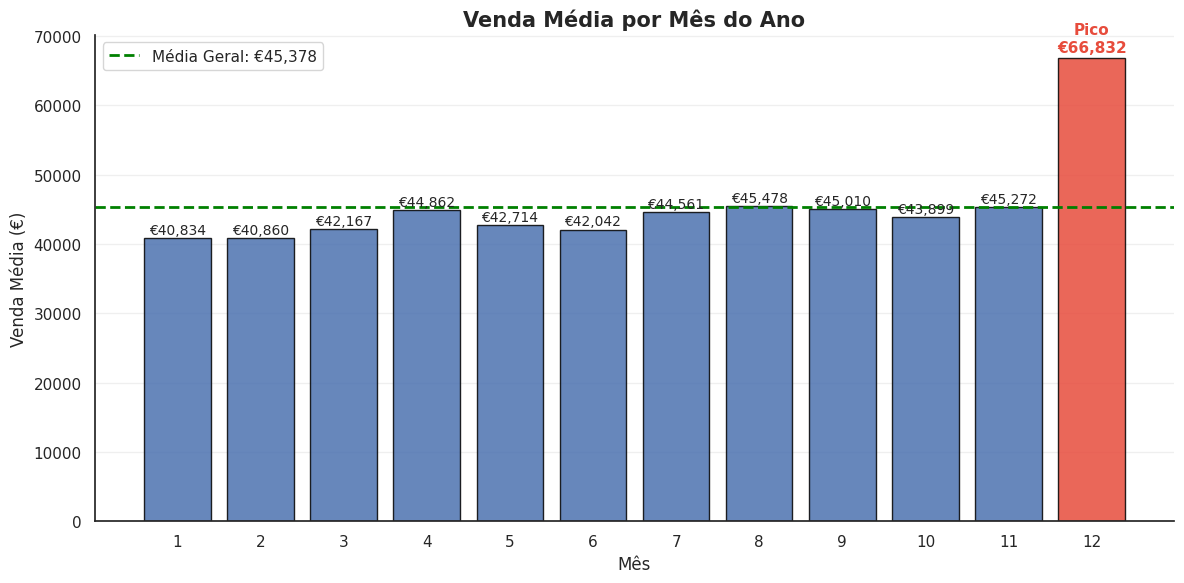

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular venda média por mês
vendas_mes = df.groupby('MES')['TARGET_VENDAS_DIARIAS_EUR'].mean().reindex(range(1,13))
meses_labels = [str(m) for m in range(1,13)]
vendas_mes.index = meses_labels

# Identificar mês de pico
mes_pico = vendas_mes.idxmax()
valor_pico = vendas_mes.max()
media_geral = vendas_mes.mean()

# Gráfico de barras
sns.set_style("white")
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(vendas_mes.index, vendas_mes.values, color=['#4c72b0' if mes != mes_pico else '#e74c3c' for mes in vendas_mes.index], edgecolor='black', alpha=0.85)
ax.axhline(media_geral, color='green', linestyle='--', linewidth=2, label=f'Média Geral: €{media_geral:,.0f}')
ax.set_title('Venda Média por Mês do Ano', fontsize=15, fontweight='bold')
ax.set_xlabel('Mês', fontsize=12)
ax.set_ylabel('Venda Média (€)', fontsize=12)
for i, bar in enumerate(bars):
    height = bar.get_height()
    if vendas_mes.index[i] == mes_pico:
        ax.text(bar.get_x() + bar.get_width()/2., height + 500, f'Pico\n€{height:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#e74c3c')
    else:
        ax.text(bar.get_x() + bar.get_width()/2., height + 200, f'€{height:,.0f}', ha='center', va='bottom', fontsize=10)
ax.legend()
ax.grid(axis='y', alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## Questão 4

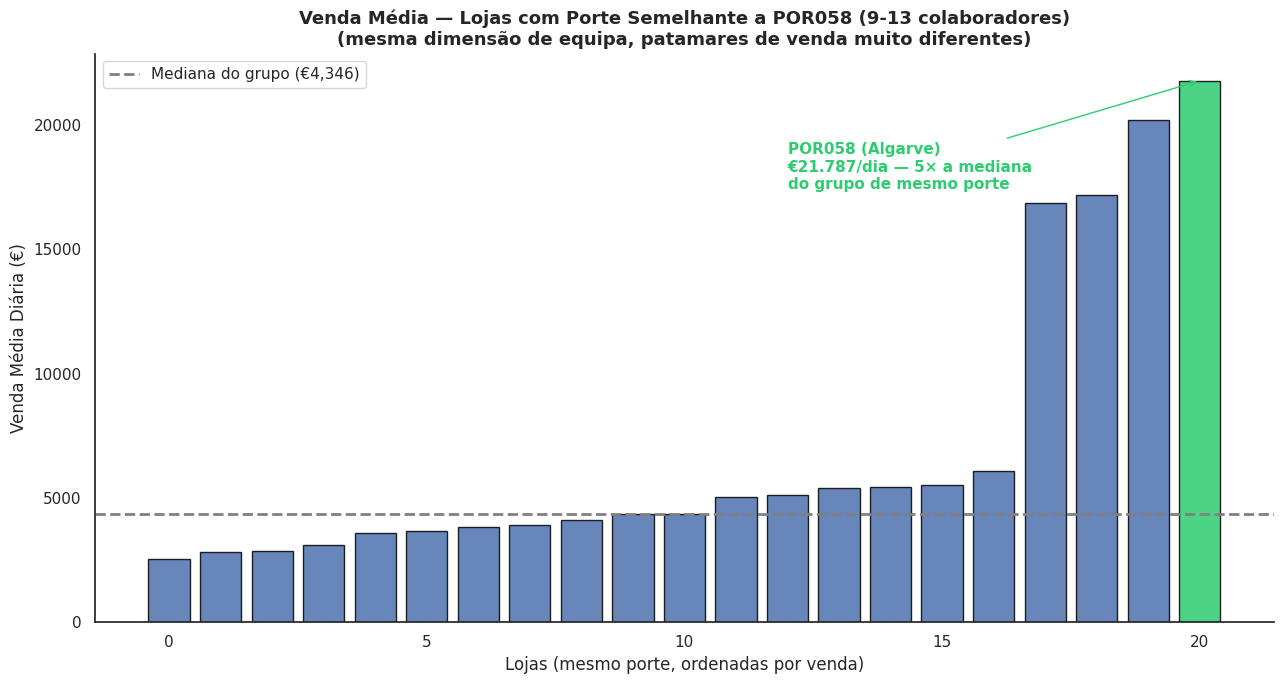

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = unificado_pd.copy() if 'unificado_pd' in dir() else unificado.copy()

perf = df.groupby('FK_LOJA').agg(
    vmean=('TARGET_VENDAS_DIARIAS_EUR', 'mean'),
    colab=('N_COLABORADORES', 'first'),
    regiao=('REGIAO', 'first')
).reset_index()

# lojas do mesmo porte que POR058 (9-13 colaboradores)
mesmo_porte = perf[(perf['colab'] >= 9) & (perf['colab'] <= 13)].sort_values('vmean')

sns.set_style("white")
fig, ax = plt.subplots(figsize=(13, 7))

cores = ['#2ecc71' if l == 'POR058' else '#4c72b0' for l in mesmo_porte['FK_LOJA']]
bars = ax.bar(range(len(mesmo_porte)), mesmo_porte['vmean'], color=cores,
              edgecolor='black', alpha=0.85)

# rotular so POR058 e a mediana
mediana = mesmo_porte[mesmo_porte['FK_LOJA'] != 'POR058']['vmean'].median()
ax.axhline(mediana, ls='--', color='gray', linewidth=2,
           label=f'Mediana do grupo (€{mediana:,.0f})')

idx_058 = mesmo_porte.reset_index(drop=True)
idx_058 = idx_058[idx_058['FK_LOJA'] == 'POR058'].index[0]
ax.annotate(f'POR058 (Algarve)\n€21.787/dia — 5× a mediana\ndo grupo de mesmo porte',
            xy=(idx_058, mesmo_porte['vmean'].values[idx_058]),
            xytext=(idx_058 - 8, mesmo_porte['vmean'].max() * 0.8),
            arrowprops=dict(arrowstyle='->', color='#2ecc71'),
            fontsize=11, color='#2ecc71', fontweight='bold')

ax.set_title('Venda Média — Lojas com Porte Semelhante a POR058 (9-13 colaboradores)\n'
             '(mesma dimensão de equipa, patamares de venda muito diferentes)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Lojas (mesmo porte, ordenadas por venda)', fontsize=12)
ax.set_ylabel('Venda Média Diária (€)', fontsize=12)
ax.tick_params(axis='both', labelsize=11)
ax.legend(fontsize=11)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

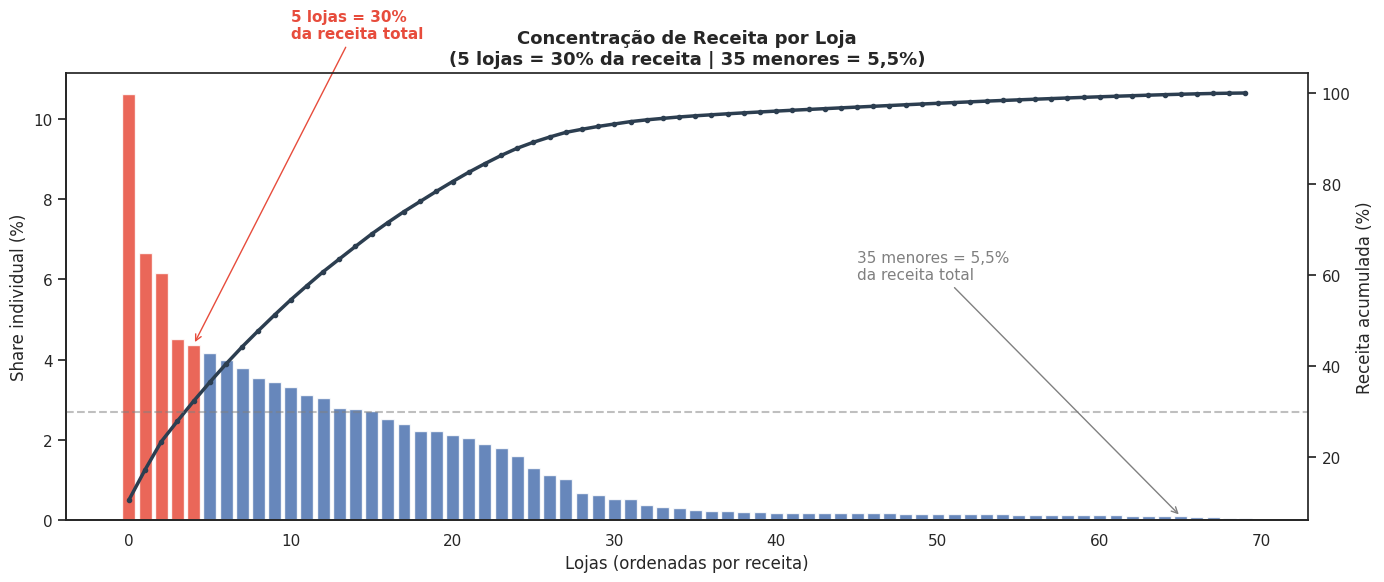

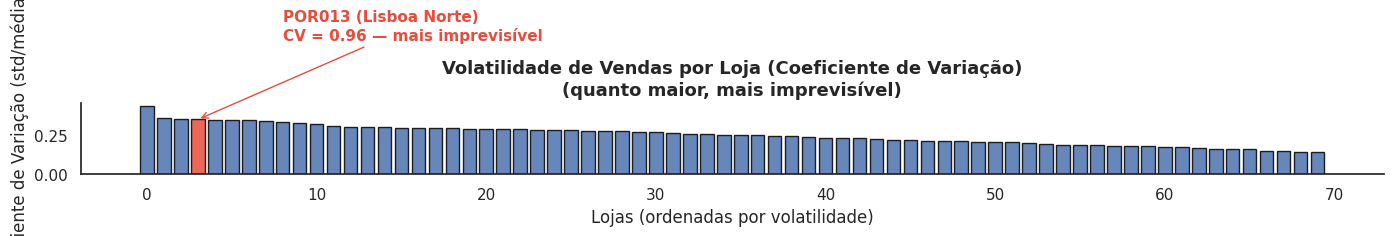

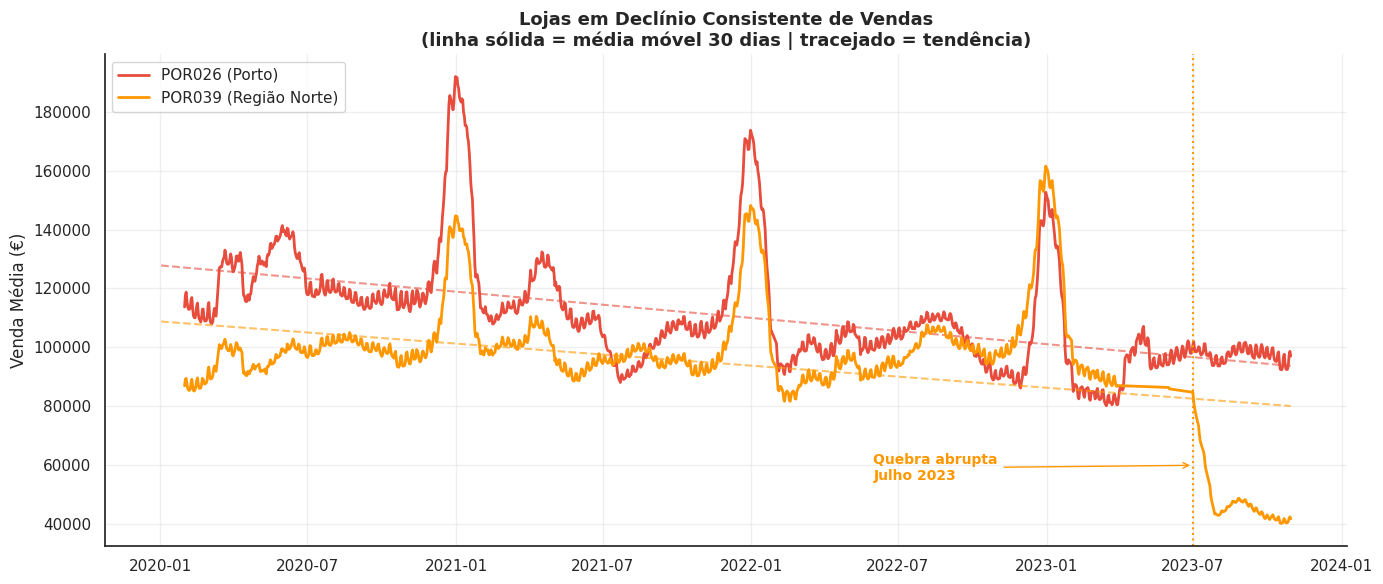

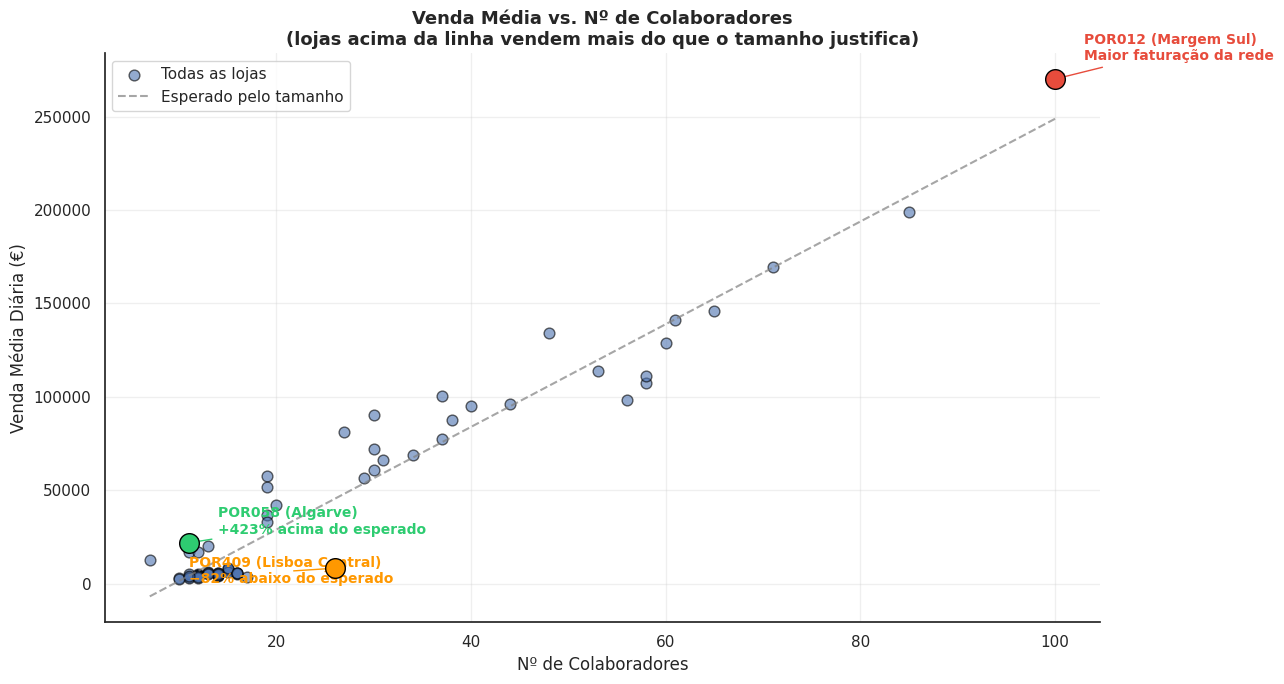

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Montar df

if 'unificado_pd' in dir():
    df = unificado_pd.copy()
elif 'unificado' in dir():
    df = unificado.copy()
else:
    raise NameError("Neither 'unificado_pd' nor 'unificado' is defined.")

df['DATA'] = pd.to_datetime(df['DATA'])

perf = df.groupby('FK_LOJA').agg(
    vmean=('TARGET_VENDAS_DIARIAS_EUR', 'mean'),
    colab=('N_COLABORADORES', 'first'),
    regiao=('REGIAO', 'first')
).reset_index()

sns.set_style("white")


# GRÁFICO 1 — PARETO
# Bullets: POR012 vende 106× mais | 5 lojas = 30% da receita

receita = df.groupby('FK_LOJA')['TARGET_VENDAS_DIARIAS_EUR'].sum().sort_values(ascending=False)
share   = (receita / receita.sum() * 100)
cum     = share.cumsum().reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(14, 6))
cores_pareto = ['#e74c3c' if i < 5 else '#4c72b0' for i in range(len(share))]
ax1.bar(range(len(share)), share.values, color=cores_pareto, alpha=0.85)
ax1.set_ylabel('Share individual (%)', fontsize=12)
ax1.set_xlabel('Lojas (ordenadas por receita)', fontsize=12)
ax1.tick_params(axis='both', labelsize=11)

ax2 = ax1.twinx()
ax2.plot(range(len(cum)), cum.values, color='#2c3e50', linewidth=2.5, marker='.')
ax2.axhline(30, ls='--', color='gray', alpha=0.5)
ax2.set_ylabel('Receita acumulada (%)', fontsize=12)
ax2.tick_params(axis='both', labelsize=11)

ax1.annotate('5 lojas = 30%\nda receita total',
             xy=(4, share.values[4]),
             xytext=(10, 12),
             arrowprops=dict(arrowstyle='->', color='#e74c3c'),
             fontsize=11, color='#e74c3c', fontweight='bold')
ax1.annotate('35 menores = 5,5%\nda receita total',
             xy=(65, share.values[65]),
             xytext=(45, 6),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=11, color='gray')

plt.title('Concentração de Receita por Loja\n(5 lojas = 30% da receita | 35 menores = 5,5%)',
          fontsize=13, fontweight='bold')
sns.despine(ax=ax1)
plt.tight_layout()
plt.show()


# GRÁFICO 2 — VOLATILIDADE
# Bullet: POR013 (Lisboa Norte) mais imprevisível

cv = df.groupby('FK_LOJA')['TARGET_VENDAS_DIARIAS_EUR'].agg(['mean', 'std'])
cv['CV'] = cv['std'] / cv['mean']
cv = cv.reset_index().merge(perf[['FK_LOJA', 'regiao']], on='FK_LOJA')
cv_sorted = cv.sort_values('CV', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))
cores_cv = ['#e74c3c' if l == 'POR013' else '#4c72b0' for l in cv_sorted['FK_LOJA']]
ax.bar(range(len(cv_sorted)), cv_sorted['CV'], color=cores_cv, alpha=0.85, edgecolor='black')
idx = cv_sorted[cv_sorted['FK_LOJA'] == 'POR013'].index[0]
ax.annotate('POR013 (Lisboa Norte)\nCV = 0.96 — mais imprevisível',
            xy=(idx, cv_sorted.loc[idx, 'CV']),
            xytext=(idx + 5, 0.85),
            arrowprops=dict(arrowstyle='->', color='#e74c3c'),
            fontsize=11, color='#e74c3c', fontweight='bold')
ax.set_title('Volatilidade de Vendas por Loja (Coeficiente de Variação)\n(quanto maior, mais imprevisível)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Lojas (ordenadas por volatilidade)', fontsize=12)
ax.set_ylabel('Coeficiente de Variação (std/média)', fontsize=12)
ax.tick_params(axis='both', labelsize=11)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


# GRÁFICO 3 — TENDÊNCIA
# Bullet: POR026 declínio | POR039 quebra abrupta

d = df.copy()
d['t'] = (d['DATA'] - d['DATA'].min()).dt.days
lojas_foco  = ['POR026', 'POR039']
nomes_loja  = {'POR026': 'POR026 (Porto)', 'POR039': 'POR039 (Região Norte)'}
cores_tend  = {'POR026': '#e74c3c', 'POR039': '#FF9800'}

fig, ax = plt.subplots(figsize=(14, 6))
for loja in lojas_foco:
    sub = d[d['FK_LOJA'] == loja].sort_values('DATA')
    mm  = sub['TARGET_VENDAS_DIARIAS_EUR'].rolling(30).mean()
    ax.plot(sub['DATA'], mm, label=nomes_loja[loja],
            color=cores_tend[loja], linewidth=2)
    coef_t = np.polyfit(sub['t'], sub['TARGET_VENDAS_DIARIAS_EUR'], 1)
    ax.plot(sub['DATA'], np.polyval(coef_t, sub['t']),
            '--', color=cores_tend[loja], alpha=0.6)

# anotar quebra abrupta POR039
sub039 = d[d['FK_LOJA'] == 'POR039'].sort_values('DATA')
data_quebra = pd.to_datetime('2023-07-01')
ax.axvline(data_quebra, color='#FF9800', ls=':', linewidth=1.5)
ax.annotate('Quebra abrupta\nJulho 2023',
            xy=(data_quebra, 60000),
            xytext=(pd.to_datetime('2022-06-01'), 55000),
            arrowprops=dict(arrowstyle='->', color='#FF9800'),
            fontsize=10, color='#FF9800', fontweight='bold')

ax.set_title('Lojas em Declínio Consistente de Vendas\n(linha sólida = média móvel 30 dias | tracejado = tendência)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Venda Média (€)', fontsize=12)
ax.tick_params(axis='both', labelsize=11)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


# GRÁFICO 4 — SCATTER
# Bullet: POR058 +423% | POR012 maior | POR409 sub-performa

coef_s = np.polyfit(perf['colab'], perf['vmean'], 1)
perf['esperado'] = np.polyval(coef_s, perf['colab'])
perf['gap_%'] = ((perf['vmean'] - perf['esperado']) / perf['esperado'] * 100)

destacadas = {'POR058': ('#2ecc71', 'POR058 (Algarve)\n+423% acima do esperado'),
              'POR012': ('#e74c3c', 'POR012 (Margem Sul)\nMaior faturação da rede'),
              'POR409': ('#FF9800', 'POR409 (Lisboa Central)\n−82% abaixo do esperado')}

fig, ax = plt.subplots(figsize=(13, 7))
normais = perf[~perf['FK_LOJA'].isin(destacadas.keys())]
ax.scatter(normais['colab'], normais['vmean'],
           color='#4c72b0', s=60, alpha=0.6, edgecolor='black', label='Todas as lojas')

x_line = np.linspace(perf['colab'].min(), perf['colab'].max(), 100)
ax.plot(x_line, np.polyval(coef_s, x_line), '--', color='gray',
        alpha=0.7, label='Esperado pelo tamanho')

for loja, (cor, label) in destacadas.items():
    p = perf[perf['FK_LOJA'] == loja].iloc[0]
    ax.scatter(p['colab'], p['vmean'], color=cor, s=200, zorder=5, edgecolor='black')
    offset_x = 3 if loja != 'POR409' else -15
    offset_y = 5000 if loja == 'POR058' else (-8000 if loja == 'POR409' else 10000)
    ax.annotate(label,
                xy=(p['colab'], p['vmean']),
                xytext=(p['colab'] + offset_x, p['vmean'] + offset_y),
                arrowprops=dict(arrowstyle='->', color=cor),
                fontsize=10, color=cor, fontweight='bold')

ax.set_title('Venda Média vs. Nº de Colaboradores\n(lojas acima da linha vendem mais do que o tamanho justifica)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Nº de Colaboradores', fontsize=12)
ax.set_ylabel('Venda Média Diária (€)', fontsize=12)
ax.tick_params(axis='both', labelsize=11)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Montar df

if 'unificado_pd' in dir():
    df = unificado_pd.copy()
elif 'unificado' in dir():
    df = unificado.copy()
else:
    raise NameError("Neither 'unificado_pd' nor 'unificado' is defined.")

df['DATA'] = pd.to_datetime(df['DATA'])

perf = df.groupby('FK_LOJA').agg(
    vmean=('TARGET_VENDAS_DIARIAS_EUR', 'mean'),
    colab=('N_COLABORADORES', 'first'),
    regiao=('REGIAO', 'first')
).reset_index()

sns.set_style("white")


# GRÁFICO 1 — PARETO
# Bullets: POR012 vende 106× mais | 5 lojas = 30% da receita

receita = df.groupby('FK_LOJA')['TARGET_VENDAS_DIARIAS_EUR'].sum().sort_values(ascending=False)
share   = (receita / receita.sum() * 100)
cum     = share.cumsum().reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(14, 6))
cores_pareto = ['#e74c3c' if i < 5 else '#4c72b0' for i in range(len(share))]
ax1.bar(range(len(share)), share.values, color=cores_pareto, alpha=0.85)
ax1.set_ylabel('Share individual (%)', fontsize=12)
ax1.set_xlabel('Lojas (ordenadas por receita)', fontsize=12)
ax1.tick_params(axis='both', labelsize=11)

ax2 = ax1.twinx()
ax2.plot(range(len(cum)), cum.values, color='#2c3e50', linewidth=2.5, marker='.')
ax2.axhline(30, ls='--', color='gray', alpha=0.5)
ax2.set_ylabel('Receita acumulada (%)', fontsize=12)
ax2.tick_params(axis='both', labelsize=11)

ax1.annotate('5 lojas = 30%\nda receita total',
             xy=(4, share.values[4]),
             xytext=(10, 12),
             arrowprops=dict(arrowstyle='->', color='#e74c3c'),
             fontsize=11, color='#e74c3c', fontweight='bold')
ax1.annotate('35 menores = 5,5%\nda receita total',
             xy=(65, share.values[65]),
             xytext=(45, 6),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=11, color='gray')

plt.title('Concentração de Receita por Loja\n(5 lojas = 30% da receita | 35 menores = 5,5%)',
          fontsize=13, fontweight='bold')
sns.despine(ax=ax1)
plt.tight_layout()
plt.show()


# GRÁFICO 2 — VOLATILIDADE
# Bullet: POR013 (Lisboa Norte) mais imprevisível

cv = df.groupby('FK_LOJA')['TARGET_VENDAS_DIARIAS_EUR'].agg(['mean', 'std'])
cv['CV'] = cv['std'] / cv['mean']
cv = cv.reset_index().merge(perf[['FK_LOJA', 'regiao']], on='FK_LOJA')
cv_sorted = cv.sort_values('CV', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))
cores_cv = ['#e74c3c' if l == 'POR013' else '#4c72b0' for l in cv_sorted['FK_LOJA']]
ax.bar(range(len(cv_sorted)), cv_sorted['CV'], color=cores_cv, alpha=0.85, edgecolor='black')
idx = cv_sorted[cv_sorted['FK_LOJA'] ==

  File <command-6355245036549980>, line 76
    idx = cv_sorted[cv_sorted['FK_LOJA'] ==
                                           ^
SyntaxError: incomplete input


In [0]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Construct df from unificado
if 'unificado_pd' in dir():
    df = unificado_pd.copy()
elif 'unificado' in dir():
    df = unificado.copy()
else:
    raise NameError(
        "Neither 'unificado_pd' nor 'unificado' is defined. Please run the data loading cells first:\n"
        "  1. Run Cell 6 to load 'unificado' from Unity Catalog\n"
        "  2. Optionally run Cell 123 to create 'unificado_pd'\n"
        "  3. Then re-run this cell."
    )
df['DATA'] = pd.to_datetime(df['DATA'])

# Construct perf DataFrame
perf = df.groupby('FK_LOJA').agg({
    'TARGET_VENDAS_DIARIAS_EUR': 'mean',
    'REGIAO': 'first',
    'N_COLABORADORES': 'first'
}).reset_index()
perf.columns = ['FK_LOJA', 'vmean', 'regiao', 'colab']


# GRÁFICO 2 — VOLATILIDADE (bullet 3)
# POR013 tem CV quase igual à sua própria média

cv = df.groupby('FK_LOJA')['TARGET_VENDAS_DIARIAS_EUR'].agg(['mean','std'])
cv['CV'] = cv['std'] / cv['mean']
cv = cv.reset_index().merge(perf[['FK_LOJA','regiao']], on='FK_LOJA')
cv_sorted = cv.sort_values('CV', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))
cores = ['#e74c3c' if l == 'POR013' else '#4c72b0' for l in cv_sorted['FK_LOJA']]
ax.bar(range(len(cv_sorted)), cv_sorted['CV'], color=cores, alpha=0.85, edgecolor='black')
idx_por013 = cv_sorted[cv_sorted['FK_LOJA']=='POR013'].index[0]
ax.annotate(f"POR013\n(Lisboa Norte)\nCV = 0.96",
            xy=(idx_por013, cv_sorted.loc[idx_por013,'CV']),
            xytext=(idx_por013+5, 0.85),
            arrowprops=dict(arrowstyle='->', color='#e74c3c'),
            fontsize=11, color='#e74c3c', fontweight='bold')
ax.set_title('Volatilidade de Vendas por Loja (Coeficiente de Variação)\n(quanto maior, mais imprevisível)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Lojas (ordenadas por volatilidade)', fontsize=12)
ax.set_ylabel('Coeficiente de Variação (std/média)', fontsize=12)
ax.tick_params(axis='both', labelsize=11)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


# GRÁFICO 3 — TENDÊNCIA (bullet 4)
# POR026 e POR039 em declínio consistente

d = df.copy()
d['t'] = (d['DATA'] - d['DATA'].min()).dt.days
lojas_foco = ['POR026','POR039']
nomes = {'POR026':'POR026 (Porto)','POR039':'POR039 (Região Norte)'}
cores_tend = {'POR026':'#e74c3c','POR039':'#FF9800'}

fig, ax = plt.subplots(figsize=(14, 6))
for loja in lojas_foco:
    sub = d[d['FK_LOJA']==loja].sort_values('DATA')
    mm  = sub['TARGET_VENDAS_DIARIAS_EUR'].rolling(30).mean()
    ax.plot(sub['DATA'], mm, label=nomes[loja],
            color=cores_tend[loja], linewidth=2)
    coef = np.polyfit(sub['t'], sub['TARGET_VENDAS_DIARIAS_EUR'], 1)
    tend_line = np.polyval(coef, sub['t'])
    ax.plot(sub['DATA'], tend_line, '--', color=cores_tend[loja], alpha=0.6)

ax.set_title('Lojas em Declínio Consistente de Vendas\n(linha sólida = média móvel 30 dias | tracejado = tendência)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Venda Média (€)', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.tick_params(axis='both', labelsize=11)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


# GRÁFICO 4 — SCATTER (bullet 5)
# POR058 sobre-performa 423% vs tamanho

fig, ax = plt.subplots(figsize=(12, 7))

# Plot all stores
ax.scatter(perf['colab'], perf['vmean'],
           color='#4c72b0', label='Todas as lojas',
           s=80, alpha=0.7, edgecolor='black')

# linha de tendencia
coef = np.polyfit(perf['colab'], perf['vmean'], 1)
x_line = np.linspace(perf['colab'].min(), perf['colab'].max(), 100)
ax.plot(x_line, np.polyval(coef, x_line), '--', color='gray',
        alpha=0.7, label='Esperado pelo tamanho')

# destacar POR058
p058 = perf[perf['FK_LOJA']=='POR058'].iloc[0]
ax.scatter(p058['colab'], p058['vmean'],
           color='#2ecc71', s=200, zorder=5, edgecolor='black')
ax.annotate('POR058 (Algarve)\n+423% acima do esperado\npara 11 colaboradores',
            xy=(p058['colab'], p058['vmean']),
            xytext=(p058['colab']+5, p058['vmean']+5000),
            arrowprops=dict(arrowstyle='->', color='#2ecc71'),
            fontsize=11, color='#2ecc71', fontweight='bold')

ax.set_title('Venda Média vs. Nº de Colaboradores\n(lojas acima da linha vendem mais do que o tamanho justifica)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Nº de Colaboradores', fontsize=12)
ax.set_ylabel('Venda Média Diária (€)', fontsize=12)
ax.tick_params(axis='both', labelsize=11)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Quatro gráficos, cada um ligado directamente a um ou dois bullets:
# Gráfico 1 (Pareto) -> bullets 1 e 2 — concentração e ratio 106×
# Gráfico 2 (CV) -> bullet 3 — POR013 mais imprevisível
# Gráfico 3 (Tendência) -> bullet 4 — POR026 e POR039 em declínio
# Gráfico 4 (Scatter) -> bullet 5 — POR058 sobre-performa vs tamanho

# Mas qual o grafico mais importante para colocar na apresentacao?
# Para responder à pergunta "Existem lojas com comportamento sistematicamente distinto?" 
# o gráfico mais importante é o Scatter (Gráfico 4).
# Porque é o único que mostra todas as 70 lojas ao mesmo tempo e responde 
# visualmente às três dimensões da pergunta:
#
# Quem é distinto — os pontos fora da linha
# Por que é distinto — o formato (cor) explica a posição
# Quanto é distinto — a distância à linha de tendência
#
# O Pareto (Gráfico 1) é o segundo mais importante — mostra a concentração 
# de receita de forma imediata. Os outros dois (CV e Tendência) são mais 
# técnicos e ficam melhor no relatório do que na apresentação.
# Se tiver espaço para dois gráficos no slide:
# Gráfico principal: Scatter (venda vs. colaboradores) — responde "quais e porquê"
# Gráfico de apoio: Pareto — responde "qual o impacto financeiro"
# Os dois juntos constroem a narrativa completa: há lojas sistematicamente 
# distintas (scatter), e isso tem consequências financeiras concretas (pareto).

## Storytelling de Features — Decisão Final

**Modelo escolhido:** LinearRegression

###  Features utilizadas no modelo final

| Feature | Motivo (EDA) | Comportamento no modelo | Veredito |
|---|---|---|---|
| PRODUTIVIDADE/HORA | Mede eficiência dentro do porte da loja | RF 0,03% (12/14) · LR coef. ~2,9 | Pouco relevante, mantida |
| N_COLABORADORES | Maior separador de vendas no EDA (proxy de escala) | RF 0,32% (8/14) · LR coef. ~174 | Relevante, sobretudo no LR |
| SELF_CHECKOUTS | Faz parte do perfil/porte da loja | RF 0,08% (11/14) · LR coef. ~79 | Pouco relevante, mantida |
| LAG_1_VENDAS | Forte inércia: venda de ontem prevê hoje | RF 7,24% (5/14) | Relevante |
| LAG_7_VENDAS | Ritmo semanal claro (mesmo dia da semana anterior) | RF 37,60% (1/14) · DT 87,21% (1º) | **Muito relevante — principal preditor** |
| LAG_14_VENDAS | Confirma padrão semanal, evita distorção de semana atípica | RF 6,11% (6/14) | Relevante |
| ROLL_AVG_1_VENDAS | Nível recente suavizado, âncora da previsão | RF 10,51% (4/14) | Relevante |
| ROLL_AVG_7_VENDAS | Momento (forte/fraco) da última semana | RF 24,26% (2/14) · DT 8,88% (2º) | **Muito relevante** |
| ROLL_AVG_14_VENDAS | Tendência de fundo, estabiliza a previsão | RF 13,24% (3/14) | Relevante |
| CAIXAS_TRADICIONAIS | Dimensiona capacidade de atendimento/porte | RF 0,15% (10/14) · LR coef. ~-44 | Pouco relevante, mantida |
| SKUS_+ | Sortido mais variado → mais faturação | RF 0,61% (7/14) · LR coef. ~0,19 | Baixa relevância, contributo positivo |
| IS_REG_LIS_NOR | Lisboa Norte concentra maior volume de vendas | Sem peso no feature importance | Relevante pelo ganho de MAPE (Exp.32) |

###  Features removidas do modelo final

| Feature | Motivo da remoção |
|---|---|
| **IS_EVENT** |  retirada do modelo final
| **EVENTO_FIM_SEMANA** | retirada do modelo final |
| ANO | Pouco relevante |
| ANO_NOVO | Pouco relevante |
| CARNAVAL | Aumenta o MAPE |
| DIA_DO_TRABALHADOR | Pouco relevante |
| DIA_SEMANA | MAPE aumenta em duplicado |
| IS_WEEKEND | MAPE aumenta em duplicado |
| LOJA_ABERTA | Removida |
| MES | Aumenta o MAPE |
| NATAL | Aumenta o MAPE |
| PASCOA | Aumenta o MAPE |
| SEMANA_DO_ANO | Pouco relevante |
| SKUS_- | Aumenta o MAPE |
| MEDIA_REGIAO_HISTORICA | Aumenta 0,1% |
| TOP4_REGIÃO | Aumenta 0,1% |
| IS_REG_NORTE | Aumenta 0,1% |
| IS_REG_PORTO | Aumenta 0,1% |
| IS_REG_MAR_SUL | Aumenta 0,1% |
| TAMANHO_LOJA | Aumenta 0,1% |
| IS_LOJA_PEQUENA | MAPE sem variação |
| IS_LOJA_MEDIA | MAPE sem variação |
| IS_LOJA_GRANDE | MAPE sem variação |
| IS_HIPERMERCADO | Aumenta o MAPE |
| VAR_PREÇO_+ | Aumenta o MAPE |
| VAR_PREÇO_- | Aumenta o MAPE |